# Download, extract, & prep mcool files

In [130]:
%%bash

clr_dir="$HOME/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K";
# clr_dir="$HOME/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K";
cd "$clr_dir";


celltypes="Oligo_NN L6_CT_CTX_Glut Astro-TE_NN L2_3_IT_CTX_Glut Endo_NN L4_5_IT_CTX_Glut L5_IT_CTX_Glut L6_IT_CTX_Glut";

# filenames=$(for each in $celltypes; do ls $each*; done);
# mkdir originals
# mv *.mcool originals/
# mkdir selected && cd selected
# for each in $filenames; do
# 	echo -e "\n======== $each"
# 	cooler cp ../originals/$each::/resolutions/100000 $each::/resolutions/100000 && cooler ls $each
# done

# cd "$clr_dir/selected";
# for each in $(ls *.mcool); do
#     echo -e "\n\n======== $each"
#     cooler coarsen -k 25 $each::/resolutions/100000 -o $each::/resolutions/2500000 -a && echo && cooler ls $each
#     cooler coarsen -k 5 $each::/resolutions/100000 -o $each::/resolutions/500000 -a && echo && cooler ls $each
# done

# cd "$clr_dir/selected";
# for each in $(ls *.mcool); do
#     echo -e "\n======== $each";
#     cooler balance $each::/resolutions/100000 --cis-only --convergence-policy 'discard' --ignore-diags 1 --force;
#     cooler balance $each::/resolutions/2500000 --cis-only --convergence-policy 'discard' --ignore-diags 1 --force;
#     cooler balance $each::/resolutions/500000 --cis-only --convergence-policy 'discard' --ignore-diags 1 --force;
# done

cd "$clr_dir/selected";
filenames=$(for each in $celltypes; do ls $each*; done)
for each in $filenames; do
	echo -e "\n$each"
	cooler ls $each
done



Oligo_NN.Q.100K.mcool
Oligo_NN.Q.100K.mcool::/resolutions/100000
Oligo_NN.Q.100K.mcool::/resolutions/2500000

L6_CT_CTX_Glut.Q.100K.mcool
L6_CT_CTX_Glut.Q.100K.mcool::/resolutions/100000
L6_CT_CTX_Glut.Q.100K.mcool::/resolutions/2500000

Astro-TE_NN.Q.100K.mcool
Astro-TE_NN.Q.100K.mcool::/resolutions/100000
Astro-TE_NN.Q.100K.mcool::/resolutions/500000
Astro-TE_NN.Q.100K.mcool::/resolutions/2500000

L2_3_IT_CTX_Glut.Q.100K.mcool
L2_3_IT_CTX_Glut.Q.100K.mcool::/resolutions/100000
L2_3_IT_CTX_Glut.Q.100K.mcool::/resolutions/2500000

Endo_NN.Q.100K.mcool
Endo_NN.Q.100K.mcool::/resolutions/100000
Endo_NN.Q.100K.mcool::/resolutions/2500000

L4_5_IT_CTX_Glut.Q.100K.mcool
L4_5_IT_CTX_Glut.Q.100K.mcool::/resolutions/100000
L4_5_IT_CTX_Glut.Q.100K.mcool::/resolutions/2500000

L5_IT_CTX_Glut.Q.100K.mcool
L5_IT_CTX_Glut.Q.100K.mcool::/resolutions/100000
L5_IT_CTX_Glut.Q.100K.mcool::/resolutions/2500000

L6_IT_CTX_Glut.Q.100K.mcool
L6_IT_CTX_Glut.Q.100K.mcool::/resolutions/100000
L6_IT_CTX_Glut.Q

# Distance decay - mcool files

In [ ]:
%load_ext autoreload
%autoreload 2 

In [ ]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [ ]:
# resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
resolution = int(1000 * 500) # 500 kb (5e5 bp)

In [ ]:
# get centromere data from ucsc gap file
mm10_gap = pd.read_csv(
    '/net/gs/vol1/home/gesine/noble_lab/resources/genomic/gaps/ucsc.mm10.gap.txt',
    sep='\t', header=None, names=(
        'bin', 'chrom', 'start', 'end', 'ix', 'n', 'size', 'type', 'bridge'))
mm10_cens = mm10_gap.loc[mm10_gap.type == 'centromere', ['chrom', 'start', 'end']].copy().reset_index()
mm10_cens['mid'] = ((mm10_cens.start + mm10_cens.end) / 2).astype(int)
# Use bioframe to fetch the genomic features from the UCSC.
mm10_chromsizes = bioframe.fetch_chromsizes('mm10')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
mm10_arms = bioframe.make_chromarms(mm10_chromsizes,  mm10_cens)
# remove chrX, chrY, chrM
mm10_arms = mm10_arms[~mm10_arms.chrom.isin(['chrX', 'chrY', 'chrM'])].reset_index(drop=True)
# remove arms that are less than the current binsize/resolution
mm10_arms = mm10_arms[(mm10_arms.end - mm10_arms.start) > resolution]

In [ ]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'

uri = f'{mcool_file}::/resolutions/{resolution:d}'

print(uri)
clr = cooler.Cooler(uri)

cis_cov, tot_cov = cooltools.coverage(clr, ignore_diags=1, nproc=2)
print(f"nreads: {cis_cov.sum():,}", flush=True)

In [ ]:
cvd_smooth_agg = cooltools.expected_cis(
    clr=clr,
    view_df= mm10_arms[mm10_arms.chrom.isin(clr.chromnames)].reset_index(drop=True),
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus,
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

# Compare matrices

## Load

In [1]:
%run fit_pseudocount_func.py load
%run plot_pseudocount_func.py

import pandas as pd
import glob
import os
import ast
import numpy as np
import re
from functools import partial

# from fit_pseudocount_func import load

import matplotlib.pyplot as plt
from matplotlib import colors
plt.style.use('seaborn-v0_8-paper')
%matplotlib inline
import seaborn as sns
sns.set_theme('paper', style='white')


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
mcool_file_q = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file_raw = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
# mcool_file = mcool_file_raw
mcool_file = mcool_file_q
resolution = 2.5 # 2.5 Mb (2.5e6 bp)
# resolution = 0.5
# resolution = int(1000 * 500) # 500 kb (5e5 bp)
lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'

# normalize = False
normalize = True

matrix_df, sc_dis, lengths_df = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, lengths_file=lengths_file, normalize_snm3c=normalize, resolution=resolution, verbose=True)


results_df = pd.DataFrame()
results = []
results_file = f"pseudocounts_vs_snm3c.{'raw' if '.raw.' in mcool_file.lower() else 'q'}{'_norm' if normalize else '_orig'}" + (f".{resolution * 1000:g}kb" if resolution != 2.5 else '') + ".tsv"
print(results_file)
if os.path.exists(results_file):
    results_df = pd.read_csv(results_file, sep='\t')
    results = results_df.to_dict(orient='records')
print(f"{len(results_df)} entries:")
display(results_df.head())

Loading and normalizing snm3c-seq data...
0 genomic loci are present in MERFISH but not snm3c
36 genomic loci are masked out from snm3c
pseudocounts_vs_snm3c.q_norm.tsv
0 entries:


""


### Test agg code

In [420]:
snm3c_s1_mean = matrix_df_ambig[matrix_df_ambig.genomic_dis_ambig == 1].groupby('chrom').snm3c.mean()
matrix_df_ambig['snm3c_tmp'] = matrix_df_ambig['snm3c'] / snm3c_s1_mean[matrix_df_ambig.chrom].values
assert np.allclose(matrix_df_ambig[matrix_df_ambig.genomic_dis_ambig == 1].groupby('chrom').snm3c_tmp.mean().values, 1)

snm3c_s1_mean

chrom
chr1     0.076102
chr10    0.077080
chr11    0.076850
chr12    0.083452
chr13    0.082761
chr14    0.075831
chr15    0.074134
chr16    0.077222
chr17    0.075459
chr18    0.072047
chr19    0.068517
chr2     0.077104
chr3     0.081515
chr4     0.077503
chr5     0.076242
chr6     0.077838
chr7     0.079350
chr8     0.076625
chr9     0.069975
Name: snm3c, dtype: float64

In [405]:
def setup_dist_decay_obj(genomic_dis, chrom, snm3c, agg_genomic_dis_opt):
    tmp = pd.DataFrame.from_dict(
        dict(genomic_dis=genomic_dis, chrom=chrom, snm3c=snm3c))
    cutoff = tmp.groupby('chrom').genomic_dis.max().min()

    tmp['weight'] = 1
    if agg_genomic_dis_opt == 0:
        cutoff = 1
    elif agg_genomic_dis_opt > 0:
        cutoff = cutoff * agg_genomic_dis_opt
    else:
        tmp['weight'] = tmp.genomic_dis.pow(float(agg_genomic_dis_opt))
    tmp['mask'] = tmp.genomic_dis <= cutoff
    tmp['n'] = 1
    tmp['sort_order'] = np.arange(len(tmp), dtype=int)
    tmp.set_index(['chrom', 'genomic_dis'], inplace=True)

    agg = tmp.groupby(level=[0, 1]).agg({
        'snm3c': 'mean', 'n': 'sum', 'sort_order': 'min', 'mask': lambda x: x.iloc[0],
        'weight': lambda x: x.iloc[0]}).sort_values('sort_order').drop('sort_order', axis=1)
    agg['category'] = -1
    agg.loc[agg['mask'], 'category'] = np.arange(agg['mask'].sum(), dtype=int)

    df = tmp[['sort_order']].join(agg).sort_values('sort_order')
    
    agg_snm3c = np.asarray(agg.loc[agg['mask'], 'snm3c'].values, order='C')
    agg_n = np.asarray(agg.loc[agg['mask'], 'n'].values, order='C')
    if agg_genomic_dis_opt < 0:
        agg_weight = np.asarray(agg.loc[agg['mask'], 'weight'].values, order='C')
    else:
        agg_weight = None
    agg_category = np.asarray(df.loc[df['mask'], 'category'].values, order='C')
    agg_mask = np.asarray(df['mask'].values, order='C')

    return agg_snm3c, agg_n, agg_weight, agg_category, agg_mask


# ==== Fake data
counts_col = 'snm3c'
# counts_col = 'pc_mean'
agg_genomic_dis_opt = -1
foo = pd.DataFrame()
foo['genomic_dis'] = matrix_df_ambig.genomic_dis_ambig.values
foo['chrom'] = matrix_df_ambig.chrom.values
foo['snm3c'] = matrix_df_ambig.snm3c.values
foo['counts'] = matrix_df_ambig[counts_col].values
foo = foo.sort_values(['chrom', 'genomic_dis']).reset_index(drop=True)
counts = foo.counts.values
genomic_dis = foo.genomic_dis.values
chrom = foo.chrom.values
snm3c = foo.snm3c.values
jnp = np

# ==== Test setup code
agg_snm3c, agg_n, agg_weight, agg_category, agg_mask = setup_dist_decay_obj(
    genomic_dis=genomic_dis, chrom=chrom, snm3c=snm3c, agg_genomic_dis_opt=agg_genomic_dis_opt)

# self.agg_snm3c, self.agg_n, self.agg_weight, self.agg_category, self.agg_mask
# data.agg_snm3c, data.agg_n, data.agg_weight, data.agg_category, data.agg_mask

# ==== Objective code
agg_counts = jnp.histogram(
    agg_category, weights=counts[agg_mask], bins=agg_n.size, density=False)[0] / agg_n
if agg_weight is None:
    agg_mse = jnp.mean(jnp.square(agg_counts - agg_snm3c))
else:
    agg_mse = jnp.average(jnp.square(agg_counts - agg_snm3c), weights=agg_weight)


# ==== Tests
split_idx = np.unique(agg_category, return_index=True)[1][1:]
split_col1 = np.split(counts[agg_mask], split_idx)
agg_counts_true = np.array([float(x.mean()) for x in split_col1])
assert np.allclose(agg_counts_true, agg_counts)

if counts_col == 'snm3c':
    assert np.allclose(agg_counts, agg_snm3c)
    assert np.isclose(agg_mse, 0)

In [381]:
assert np.array_equal(agg_category, np.sort(agg_category))
# print(agg_category.tolist())

In [401]:


# split_idx = np.unique(agg_category, return_index=True)[1][1:]
# split_col1 = np.split(agg_category, split_idx)
# counts_agg_true = np.array([float(x.mean()) for x in split_col1])
# assert np.array_equal(counts_agg_true, np.unique(agg_category))

In [333]:
# x = np.arange(6)
# condlist = [x < 3, x > 3]
# choicelist = [-x, x ** 2]
# np.select(condlist, choicelist, 42)

In [346]:
col_idx = np.array([1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4], dtype=float)
col_data = np.array([275, 441, 494, 593, 679, 533, 686, 559, 219, 455, 605, 468, 692, 613], dtype=float)

In [344]:
split_idx = np.unique(col_idx, return_index=True)[1][1:]
split_col1 = np.split(col_data, split_idx)
np.array([float(x.sum()) for x in split_col1])

array([1803., 1898., 1233., 2378.])

In [345]:
nbins = np.unique(col_idx).size
np.histogram(col_idx, weights=col_data, bins=nbins, density=False)[0]

array([1803., 1898., 1233., 2378.])

In [281]:
_setup_jax(traceback=False, debug_nan_inf=False)
import jax.numpy as jnp
from jax import grad

def test_obj(data, idx, nbins):
    return jnp.histogram(idx, weights=data, bins=nbins)[0].sum()


grad(test_obj)(col_data, idx=col_idx, nbins=nbins)

Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float64)

### Possibly normalize at 500kb?

In [202]:
%run fit_pseudocount_func.py load
%run plot_pseudocount_func.py


def make_clr_bins_df(df, resolution):
    df = df.copy()
    df['chrom'] = df.chrom.astype(str)
    df['idx_chrom'] = (df.start / int(resolution * 1e6)).round().astype(int)
    assert len(df) == (df.groupby('chrom', observed=True).idx_chrom.max() + 1).sum()
    df['idx'] = df.index.values
    return df


norm_resolution = 0.5

if resolution % norm_resolution != 0:
    raise ValueError(f"Can't normalize {resolution * 100:g}kb data at {norm_resolution * 100:g}kb")
norm_factor = int(resolution / norm_resolution)

snm3c, clr_bins, lengths_clr = load_snm3c(mcool_file, resolution=norm_resolution, normalize=True, mask_last_locus_in_chrom=True, verbose=True)

clr_chrominfo = clr_bins.groupby('chrom', observed=True).count().drop(
    ['end', 'mid', 'snm3c_isnan'], axis=1).rename({'start': 'n_total', 'weight': 'n_valid'}, axis=1)
assert (lengths_clr == clr_chrominfo.n_total).all()

clr_bins_df = make_clr_bins_df(clr_bins, resolution=norm_resolution)
clr_bins_df['rowsum'] = np.nansum(snm3c, axis=0)
clr_bins_df.loc[clr_bins_df.rowsum == 0, 'rowsum'] = np.nan

clr_matrix_df = make_matrix_df(clr_bins_df, ploidy=1)
clr_matrix_df = clr_matrix_df[clr_matrix_df['mask.sameM']].drop(['mask.sameM', 'j.chrom'], axis=1).rename(
    {'i.chrom': 'chrom'}, axis=1)
clr_matrix_df['snm3c'] = snm3c[clr_matrix_df['i.idx'], clr_matrix_df['j.idx']]
clr_matrix_df['weights'] = clr_bins_df.loc[clr_matrix_df['i.idx'], 'weight'].values * clr_bins_df.loc[clr_matrix_df['j.idx'], 'weight'].values

clr_matrix_df

Loading and normalizing snm3c-seq data...


,i.idx,j.idx,i.idx_chrom,j.idx_chrom,chrom,mask.diffM,genomic_dis,mask.nghbr,snm3c,weights
"(0, 1)",0,1,0,1,chr1,False,1,True,NaN,NaN
"(0, 2)",0,2,0,2,chr1,False,2,False,NaN,NaN
"(0, 3)",0,3,0,3,chr1,False,3,False,NaN,NaN
"(0, 4)",0,4,0,4,chr1,False,4,False,NaN,NaN
"(0, 5)",0,5,0,5,chr1,False,5,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
"(4931, 4933)",4931,4933,119,121,chr19,False,2,False,0.069372,0.391157
"(4931, 4934)",4931,4934,119,122,chr19,False,3,False,NaN,NaN
"(4932, 4933)",4932,4933,120,121,chr19,False,1,True,0.135823,0.340550
"(4932, 4934)",4932,4934,120,122,chr19,False,2,False,NaN,NaN


In [208]:
snm3c_lowres, clr_bins_lowres, lengths_clr_lowres = load_snm3c(mcool_file, resolution=resolution, normalize=True, mask_last_locus_in_chrom=True, verbose=True)

clr_bins_df_lowres = make_clr_bins_df(clr_bins_lowres, resolution=resolution)
clr_bins_df_lowres['rowsum'] = np.nansum(snm3c_lowres, axis=0)
clr_bins_df_lowres.loc[clr_bins_df_lowres.rowsum == 0, 'rowsum'] = np.nan


clr_bins_df_lowres.loc[~clr_bins_df_lowres.snm3c_isnan, 'rowsum'].describe()

count    940.000000
mean       1.310846
std        0.124260
min        0.983496
25%        1.222104
50%        1.294977
75%        1.371720
max        1.816248
Name: rowsum, dtype: float64

In [199]:
print(lengths_clr_lowres.sum())

clr_bins_df['idx_chrom.lowres'] = np.floor(clr_bins_df.idx_chrom / norm_factor).astype(int)
# display(clr_bins_df.head(10))
print(len(clr_bins_df.groupby(['chrom', 'idx_chrom.lowres']).size()))
assert (clr_bins_df.groupby(['chrom', 'idx_chrom.lowres']).size() <= 5).all()

clr_bins_df_reduced = clr_bins_df.groupby(['chrom', 'idx_chrom.lowres']).agg({
    'start': 'min', 'end': 'max', 'weight': 'mean', 'mid': 'mean', 'snm3c_isnan': 'sum',
    'idx': 'min', 'rowsum': 'mean'}).reset_index().sort_values('idx').drop(
    'idx', axis=1).reset_index(drop=True).reset_index().rename(
    {'index': 'idx', 'idx_chrom.lowres': 'idx_chrom'}, axis=1)
clr_bins_df_reduced['mid'] = clr_bins_df_reduced['mid'].round().astype(int)
clr_bins_df_reduced.loc[clr_bins_df_reduced.rowsum == 0, 'rowsum'] = np.nan
print(clr_bins_df_reduced.snm3c_isnan.value_counts())

clr_bins_df_reduced.loc[clr_bins_df_reduced.snm3c_isnan == 0, 'rowsum'].describe()

Loading and normalizing snm3c-seq data...
994
994
snm3c_isnan
0    867
1     74
5     24
2     24
4      3
3      2
Name: count, dtype: int64


count    865.000000
mean       1.234089
std        0.067011
min        0.956985
25%        1.187991
50%        1.221674
75%        1.268385
max        1.525589
Name: rowsum, dtype: float64

In [157]:
clr_matrix_df['n'] = clr_matrix_df.snm3c.notnull().astype(int)
clr_matrix_df['i.idx_chrom.lowres'] = np.floor(clr_matrix_df['i.idx_chrom'] / norm_factor).astype(int)
clr_matrix_df['j.idx_chrom.lowres'] = np.floor(clr_matrix_df['j.idx_chrom'] / norm_factor).astype(int)

clr_matrix_df_reduced = clr_matrix_df.groupby(['chrom', 'i.idx_chrom.lowres', 'j.idx_chrom.lowres']).agg({
    'i.idx': 'min', 'j.idx': 'min', 'snm3c': 'mean', 'weights': 'mean',
    'n': 'sum'}).reset_index().sort_values(['i.idx', 'j.idx']).drop(
    ['i.idx', 'j.idx'], axis=1).reset_index(drop=True).reset_index().rename(
    {'index': 'idx', 'i.idx_chrom.lowres': 'i.idx_chrom', 'j.idx_chrom.lowres': 'j.idx_chrom'}, axis=1)
clr_matrix_df_reduced

chrom  i.idx_chrom.lowres  j.idx_chrom.lowres
chr1   0                   1                      5
                           2                      5
                           3                      5
                           4                      5
                           5                      5
                                                 ..
chr9   48                  49                    25
                           50                    20
       49                  49                    10
                           50                    20
       50                  50                     6
Length: 28724, dtype: int64

In [210]:
clr_matrix_df

,i.idx,j.idx,i.idx_chrom,j.idx_chrom,chrom,mask.diffM,genomic_dis,mask.nghbr,snm3c,weights,n
"(0, 1)",0,1,0,1,chr1,False,1,True,NaN,NaN,0
"(0, 2)",0,2,0,2,chr1,False,2,False,NaN,NaN,0
"(0, 3)",0,3,0,3,chr1,False,3,False,NaN,NaN,0
"(0, 4)",0,4,0,4,chr1,False,4,False,NaN,NaN,0
"(0, 5)",0,5,0,5,chr1,False,5,False,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
"(4931, 4933)",4931,4933,119,121,chr19,False,2,False,0.069372,0.391157,1
"(4931, 4934)",4931,4934,119,122,chr19,False,3,False,NaN,NaN,0
"(4932, 4933)",4932,4933,120,121,chr19,False,1,True,0.135823,0.340550,1
"(4932, 4934)",4932,4934,120,122,chr19,False,2,False,NaN,NaN,0


##### Load & compare: Raw vs Q (imputed)

In [3]:
assert mcool_file == mcool_file_raw  # Make sure we previously loaded the 'raw' data

matrix_df_q, _, _ = load(dir_matrix2d, mcool_file=mcool_file_q, resolution=resolution, verbose=True)
matrix_df_q.rename({'snm3c': 'snm3c_q'}, axis=1, inplace=True)
matrix_df = matrix_df.join(matrix_df_q.snm3c_q.to_frame(), how='left')
matrix_df_q = None
assert matrix_df.loc[matrix_df.snm3c.notnull(), 'snm3c_q'].isnull().sum() == 0
assert (matrix_df.loc[(matrix_df.snm3c.notnull()) & (matrix_df.snm3c != 0), 'snm3c_q'] == 0).sum() == 0

11 genomic bins are present in MERFISH but not snm3c


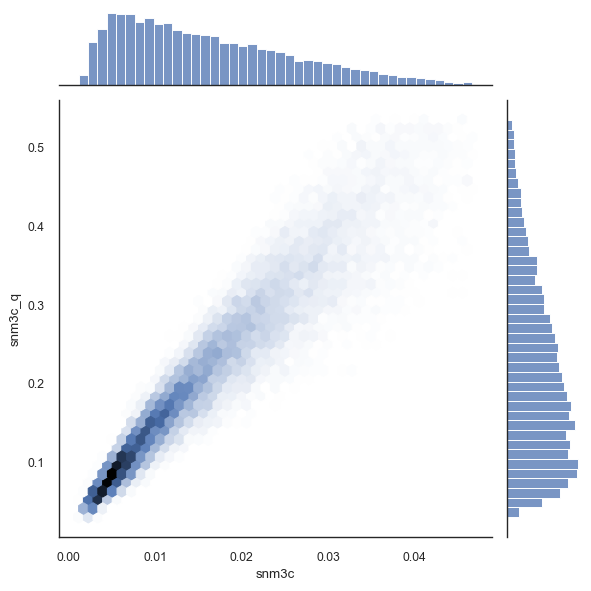

In [13]:
qlim = 0.9

mask_h1 = (~matrix_df['mask.diffM']) & (matrix_df['i.hmlg'] == 1) & (matrix_df['j.hmlg'] == 1) & (matrix_df.snm3c.notnull())
# mask_h1 = (~matrix_df['mask.diffM'])
# mask_h1 = matrix_df.index
mask = mask_h1 & (matrix_df.snm3c <= matrix_df.loc[mask_h1].snm3c.quantile(qlim)) & (matrix_df.snm3c_q <= matrix_df.loc[mask_h1].snm3c_q.quantile(qlim))
sns.jointplot(matrix_df[mask], x='snm3c', y='snm3c_q', kind='hex')
plt.show()

## Compare

### Logistic

#### Examining specific genomic distance bins - new

In [64]:
%run fit_pseudocount_func.py load
%run plot_pseudocount_func.py

# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED) - NORM BIN1/RESCALING FIXED
# k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=0  (FACTR)
# k=-19.2999;  d0=0.443964;  nu=1                              # obj=0.01246724052 → rmse.buffer10, seed=0  (PGTOL)
# k=-5.17941;  d0=2.70054;  nu=1.18687e-05                     # obj=-0.8710339124 → pearson.infer_nu.buffer10, seed=3  (FACTR)
k=-8.57474;  d0=1.79574;  nu=1.08414e-05                     # obj=0.01244820574 → rmse.infer_nu.buffer8, seed=3  (FACTR)


matrix_df_ambig, pc_df = get_pseudocounts(
    matrix_df, sc_dis=sc_dis, transfer_func=transfer_func,
    transfer_func_kwargs=transfer_func_kwargs, snm3c_are_normalized=snm3c_are_normalized,
    agg_func='mean')

# notnorm_df, _, _ = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, normalize_snm3c=False, resolution=resolution, verbose=True)
# mask = (notnorm_df['i.hmlg'] == 1) & (notnorm_df['j.hmlg'] == 1) & notnorm_df.snm3c.notnull()
# notnorm_df_ambig = notnorm_df[mask]

<Figure size 640x440 with 0 Axes>

In [135]:
tmp = notnorm_df_ambig[['genomic_dis', 'chrom', 'snm3c']].copy()

mask = (tmp.genomic_dis <= 10).values
tmp = tmp.reset_index().rename({'index': 'sort_order'}, axis=1).set_index(['chrom', 'genomic_dis'])
mask = tmp.index.get_level_values(1) <= 10
tmp['snm3c_mean'] = -1.
tmp.loc[mask, 'snm3c_mean'] = tmp[mask].groupby(level=[0, 1]).snm3c.mean()
tmp.sort_values('sort_order', inplace=True)
tmp.snm3c_mean.values

sort_order     snm3c  snm3c_mean
chrom genomic_dis                                  
chr1  1                (0, 1)  2.166355    1.734858
      2                (0, 2)  0.650051    0.598337
      3                (0, 3)  0.364925    0.420790
      4                (0, 4)  0.367587    0.356955
      5                (0, 5)  0.469842    0.329623
...                       ...       ...         ...
chr19 2            (958, 960)  0.348538    0.825092
      3            (958, 961)  0.730444    0.582159
      1            (959, 960)  2.963297    2.271735
      2            (959, 961)  0.873926    0.825092
      1            (960, 961)  1.859709    2.271735

[21855 rows x 3 columns]

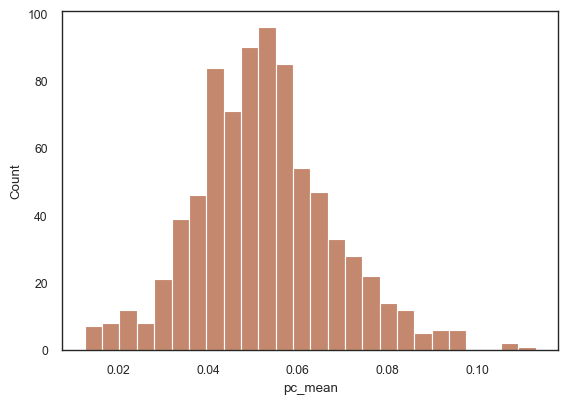

In [82]:
sns.histplot(matrix_df_ambig[matrix_df_ambig.genomic_dis_ambig == 1], x='pc_mean')

,count,mean,std,min,25%,50%,75%,max
mask.diffM,,,,,,,,
False,1594.0,0.101138,0.032366,0.012058,8.011286e-02,0.098482,0.120991,0.237275
True,1594.0,0.003639,0.004940,0.000000,5.596621e-07,0.001331,0.005959,0.034747


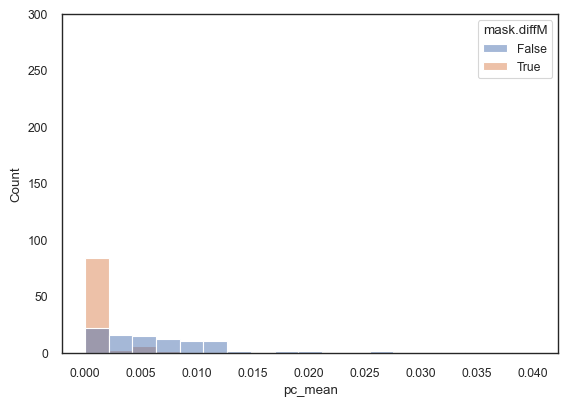

In [91]:
display(pc_df[pc_df.genomic_dis_ambig == 1].groupby('mask.diffM').pc_mean.describe())

sns.histplot(pc_df[pc_df.genomic_dis_ambig == 55], x='pc_mean', hue='mask.diffM')
plt.ylim(0, 300)
plt.show()

In [75]:
def compare_s_across_chrom(df, genomic_dis=1, display_per_chrom=False, display_across_chrom=True, col='snm3c'):
    if 'genomic_dis' in df.columns:
        mask = df.genomic_dis == genomic_dis
    else:
        mask = df.genomic_dis_ambig == genomic_dis

    df.loc[mask, 'divmean'] = df.loc[mask, col] / df[mask].groupby(
        'chrom')[col].mean().loc[df.loc[mask, 'chrom']].values
    
    per_chrom = df[mask].groupby('chrom')[col].describe()
    per_chrom['count'] = per_chrom['count'].astype(int)
    per_chrom['scaled_std'] = df[mask].groupby('chrom').divmean.std()

    if display_per_chrom:
        display(per_chrom.map(lambda x: float(f"{x:.2g}") if isinstance(x, float) else x))
    
    chrom_agg = pd.concat([
        per_chrom.mean().to_frame().rename({0: 'mean'}, axis=1),
        (per_chrom / per_chrom.mean()).std().to_frame().rename(
            {0: 'scaled_std'}, axis=1)], axis=1).drop('count')
    chrom_agg.columns.name = 'across_chrom'
    chrom_agg.index.name = 'within_chrom'
    if display_across_chrom:
        display(chrom_agg.map(lambda x: float(f"{x:.2g}") if isinstance(x, float) else x))

    return per_chrom, chrom_agg


# _ = compare_s_across_chrom(notnorm_df_ambig, display_per_chrom=False)
_ = compare_s_across_chrom(matrix_df_ambig, display_per_chrom=False)

_ = compare_s_across_chrom(matrix_df_ambig, display_per_chrom=False, col='pc_mean')
per_chrom, chrom_agg = compare_s_across_chrom(pc_df, display_per_chrom=False)
# display(per_chrom.map(lambda x: float(f"{x:.2g}") if isinstance(x, float) else x))

across_chrom,mean,scaled_std
within_chrom,,
mean,0.077,0.049
std,0.023,0.210
min,0.035,0.310
25%,0.061,0.063
50%,0.074,0.073
75%,0.090,0.074
max,0.140,0.170
scaled_std,0.300,0.180


across_chrom,mean,scaled_std
within_chrom,,
mean,0.052,0.040
std,0.015,0.160
min,0.020,0.320
25%,0.043,0.050
50%,0.051,0.044
75%,0.060,0.056
max,0.091,0.120
scaled_std,0.290,0.140


across_chrom,mean,scaled_std
within_chrom,,
mean,0.130,0.14
std,0.037,0.17
min,0.059,0.41
25%,0.100,0.16
50%,0.120,0.15
75%,0.150,0.14
max,0.220,0.12
scaled_std,0.290,0.19


<Figure size 640x440 with 0 Axes>

snm3c_are_normalized=True

Scaling factors: (mean=1.68, var=0.0785)
chr1    1.31
chr2    1.47
chr3     1.4
chr4    1.51
chr5    1.49
chr6    1.43
chr7    1.42
chr8    1.63
chr9    1.74
chr10   1.49
chr11   1.78
chr12   1.69
chr13   1.61
chr14   1.78
chr15   1.98
chr16   2.05
chr17   1.83
chr18   1.79
chr19   2.48
Pearson R:  mean=0.867
GENOMIC DIS: 0≤s≤inf     R=0.867


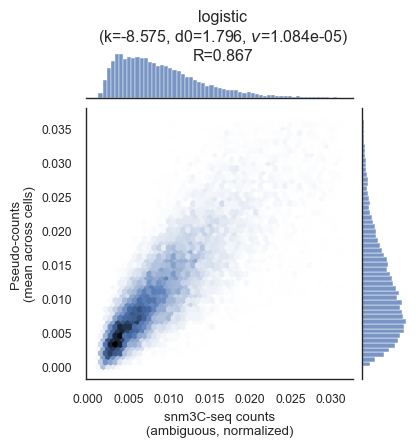

Pearson R:  mean=0.606
GENOMIC DIS: s=1         R=0.606


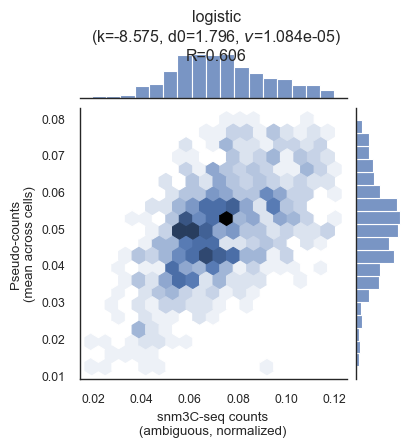

Pearson R:  mean=0.643
GENOMIC DIS: s=2         R=0.643


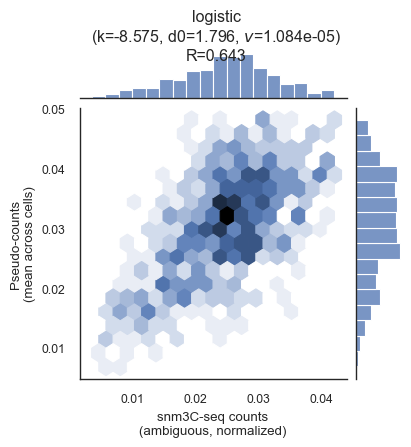

Pearson R:  mean=0.631
GENOMIC DIS: s=3         R=0.631


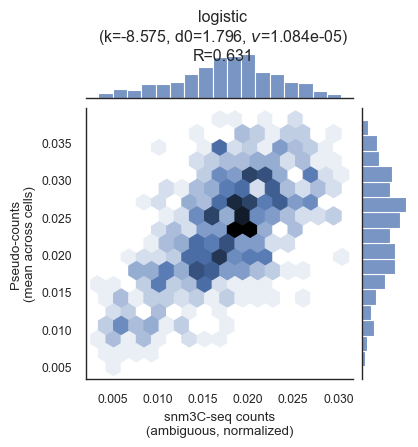

Pearson R:  mean=0.668
GENOMIC DIS: s=4         R=0.668


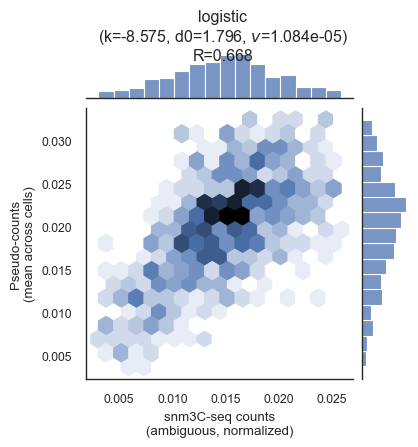

,func,func_kwargs,mean,genomic_dis_min,genomic_dis_max
8,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.668009,4,4.0
12,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.642795,2,2.0
14,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.631444,3,3.0
19,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.605611,1,1.0


,func,func_kwargs,mean,genomic_dis_min,genomic_dis_max
2,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.867012,0,inf


In [9]:
%run fit_pseudocount_func.py load
%run plot_pseudocount_func.py

k = d0 = nu = q = None

# RMSE, WEIGHT = 1/s
# [-30.394863085563795, 0.385748734297981]  # obj=0.055002832, seed=0, pgtol=1e-10

# RMSE, WITHOUT WEIGHTS
# k, d0
# [-25.52136772017525, 0.39707902525364497]  # obj=0.023229902, seed=0, pgtol=1e-10
# [-24.414438595193076, 0.39433848292756574] # obj=0.023230165, seed=1, pgtol=1e-5
# k, d0, nu
# [-11.78939201507849,  0.8051549003099034,  0.01]              # obj=0.023211055, seed=0, pgtol=1e-10
# [-24.413958929184393, 0.425210222962091, 0.6826513696104046]  # obj=0.023226203, seed=1, pgtol=1e-5


# k, d0 = np.array([-14.71402465, 0.45154928]); nu = q = 1 # best from INITIAL inference: pearson.weight0, seed=0
# k=-13; nu=1; d0=0.4; q=0.6  # best from MANUAL assessment
# k=-7.08407;  d0=0.807475;  nu=0.0358141;   q=1
# k, d0 = [-25.52136772017525, 0.39707902525364497]; nu = q = 1  # obj=-0.82056164 ... pearson.weight-1, seed=0
# k, d0 = [-30.394863085563795, 0.385748734297981]; nu = q = 1  # obj=0.055002832 ... rmse.weight-1, seed=0

# k=-53.3559;  d0=0.279179;  nu=15.7212    # obj=-0.75257981 ... pearson.weight-2.infer_nu, seed=1

# =============== INFERRED WITH Q (IMPUTED, NOT normalized, NOT MASKING LAST SNM3C-seq BIN!) - consider redoing with proper masking
# k=-12.1386;  d0=0.480525;  scaling=4.2463;  nu=1;            # obj=-0.88616295 → pearson, seed=0 (FACTR)
# k=-20.0702;  d0=0.437226;  nu=1;  scaling=5.78779            # obj=0.190089 → rmse, seed=0 (PGTOL)
# k=-5.15964;  d0=2.68554;  nu=1.22861e-05;  scaling=5.36133   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# k=-9.11523;  d0=1.72088;  nu=1e-05;  scaling=6.65738         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)

# k=-5.14364;  d0=1.69303;  nu=0.00208403;  scaling=5.38264    # obj=-0.88644619 → pearson.infer_nu, seed=1 (FACTR) -- *TEMP*
# k=-9.11602;  d0=1.46818;  nu=0.0001;  scaling=6.65724        # obj=0.18979349 → rmse.infer_nu.buffer1e-4, seed=0 (FACTR) -- *TEMP*


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED)
# k=-5.63538;  d0=2.45539;  nu=1.51704e-05;  scaling=0.460945  # obj=-0.8249887143 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# k=-9.65135;  d0=2.35724;  nu=1e-8;  scaling=0.573493         # obj=0.0202854218 → rmse.nu1e-8_buffer1e-4, seed=1  (PGTOL)
# k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED, 500kb !!!)
# # k=-3.78506;  d0=1.47742;  nu=0.0136047                       # obj=-0.8765355635 → pearson.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0     →→ exp=-0.555
# k=-4.25834;  d0=1.67136;  nu=0.00306059                      # obj=0.001800289408 → rmse.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0       →→ exp=-0.574


# =============== GOOD DIST DECAY (re Q, IMPUTED + norm)
# k=-50;  d0=0.01;  nu=1               #      →→ exp=-0.77 (expected it to be decent, based on logistic func graph)


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED) - NORM BIN1/RESCALING FIXED
# k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=0  (FACTR)
# k=-19.2999;  d0=0.443964;  nu=1                              # obj=0.01246724052 → rmse.buffer10, seed=0  (PGTOL)
# k=-5.17941;  d0=2.70054;  nu=1.18687e-05                     # obj=-0.8710339124 → pearson.infer_nu.buffer10, seed=3  (FACTR)
k=-8.57474;  d0=1.79574;  nu=1.08414e-05                     # obj=0.01244820574 → rmse.infer_nu.buffer8, seed=3  (FACTR)

# =============================================================================
snm3c_are_normalized = normalize
print(f"{snm3c_are_normalized=}\n")
plot = True


# bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()
# snm3c_per_genomic_dis = matrix_df[matrix_df.genomic_dis.notnull()].groupby('genomic_dis').snm3c.mean()
# genomic_dis_list = [1, 2, (0, np.inf)]
# genomic_dis_list = [1, 2, 3, 4]
# genomic_dis_list = np.arange(5, bins_per_genomic_dis[bins_per_genomic_dis >= 2000].index.max())
# genomic_dis_list = [(1, 3), (10, np.inf)]
# genomic_dis_list = [(0, np.inf),]
genomic_dis_list = [(0, np.inf), 1, 2, 3, 4]
# genomic_dis_list = [1, (2, 4), (10, 15), (30, 40), (50, 70), (0, np.inf)]
# genomic_dis_list = [(0, np.inf),]
# genomic_dis_list = [1, 2, 3, 4, (0, np.inf)]


transfer_func = logistic
transfer_func_kwargs = dict(k=k, d0=d0, nu=nu) if q is None else dict(k=k, d0=d0, nu=nu, q=q)
results_df = assess_via_genomic_dis(
    matrix_df, sc_dis=sc_dis, transfer_func=transfer_func, transfer_func_kwargs=transfer_func_kwargs,
    genomic_dis_list=genomic_dis_list, snm3c_are_normalized=snm3c_are_normalized, plot=plot, agg_func='mean',
    results_file=results_file, verbose=True)

In [10]:
display(results_df[(results_df.func == 'logistic') & (results_df.genomic_dis_min <= 4) & (
    results_df.genomic_dis_min == results_df.genomic_dis_max)].sort_values(
    ['genomic_dis_min', 'mean'], ascending=[True, False]).set_index('genomic_dis_min').drop(
    'genomic_dis_max', axis=1))

print()

display(results_df[(results_df.func == 'logistic') & (results_df.genomic_dis_min == 0) & np.isinf(
    results_df.genomic_dis_max)].sort_values(['genomic_dis_min', 'mean'], ascending=[True, False]).drop(
    ['genomic_dis_min', 'genomic_dis_max'], axis=1))

,func,func_kwargs,mean
genomic_dis_min,,,
1,logistic,"k=-5.179, d0=2.701, nu=1.187e-05",0.614886
1,logistic,"k=-12.04, d0=0.4948, nu=1",0.614692
1,logistic,"k=-19.3, d0=0.444, nu=1",0.606517
1,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.605611
2,logistic,"k=-5.179, d0=2.701, nu=1.187e-05",0.673286
2,logistic,"k=-12.04, d0=0.4948, nu=1",0.671681
2,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.642795
2,logistic,"k=-19.3, d0=0.444, nu=1",0.640985
3,logistic,"k=-5.179, d0=2.701, nu=1.187e-05",0.656561


,func,func_kwargs,mean
0,logistic,"k=-5.179, d0=2.701, nu=1.187e-05",0.870573
1,logistic,"k=-12.04, d0=0.4948, nu=1",0.870244
2,logistic,"k=-8.575, d0=1.796, nu=1.084e-05",0.867012
3,logistic,"k=-19.3, d0=0.444, nu=1",0.866672


In [ ]:
# results_df = assess_via_genomic_dis(
#     matrix_df[matrix_df.chrom == 'chr1'], sc_dis=sc_dis, transfer_func=transfer_func, transfer_func_kwargs=transfer_func_kwargs,
#     genomic_dis_list=genomic_dis_list, snm3c_are_normalized=snm3c_are_normalized, plot=plot, agg_func='mean',
#     results_file=None, verbose=True)

#### Examining specific genomic distance bins - old code

In [ ]:
%run fit_pseudocount_func.py load
%run plot_pseudocount_func.py

k = d0 = nu = None; q = 1

# RMSE, WEIGHT = 1/s
# [-30.394863085563795, 0.385748734297981]  # obj=0.055002832, seed=0, pgtol=1e-10

# RMSE, WITHOUT WEIGHTS
# k, d0
# [-25.52136772017525, 0.39707902525364497]  # obj=0.023229902, seed=0, pgtol=1e-10
# [-24.414438595193076, 0.39433848292756574] # obj=0.023230165, seed=1, pgtol=1e-5
# k, d0, nu
# [-11.78939201507849,  0.8051549003099034,  0.01]              # obj=0.023211055, seed=0, pgtol=1e-10
# [-24.413958929184393, 0.425210222962091, 0.6826513696104046]  # obj=0.023226203, seed=1, pgtol=1e-5


# k, d0 = np.array([-14.71402465, 0.45154928]); nu = q = 1 # best from INITIAL inference: pearson.weight0, seed=0
# k=-13; nu=1; d0=0.4; q=0.6  # best from MANUAL assessment
# k=-7.08407;  d0=0.807475;  nu=0.0358141;   q=1
# k, d0 = [-25.52136772017525, 0.39707902525364497]; nu = q = 1  # obj=-0.82056164 ... pearson.weight-1, seed=0
# k, d0 = [-30.394863085563795, 0.385748734297981]; nu = q = 1  # obj=0.055002832 ... rmse.weight-1, seed=0

# k=-53.3559;  d0=0.279179;  nu=15.7212    # obj=-0.75257981 ... pearson.weight-2.infer_nu, seed=1

# =============== INFERRED WITH Q (IMPUTED, NOT normalized, NOT MASKING LAST SNM3C-seq BIN!) - consider redoing with proper masking
# q=1
# k=-12.1386;  d0=0.480525;  scaling=4.2463;  nu=1;            # obj=-0.88616295 → pearson, seed=0 (FACTR)
# k=-20.0702;  d0=0.437226;  nu=1;  scaling=5.78779            # obj=0.190089 → rmse, seed=0 (PGTOL)
# k=-5.15964;  d0=2.68554;  nu=1.22861e-05;  scaling=5.36133   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# k=-9.11523;  d0=1.72088;  nu=1e-05;  scaling=6.65738         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)

# k=-5.14364;  d0=1.69303;  nu=0.00208403;  scaling=5.38264    # obj=-0.88644619 → pearson.infer_nu, seed=1 (FACTR) -- *TEMP*
# k=-9.11602;  d0=1.46818;  nu=0.0001;  scaling=6.65724        # obj=0.18979349 → rmse.infer_nu.buffer1e-4, seed=0 (FACTR) -- *TEMP*


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED)
# q=1
# k=-5.63538;  d0=2.45539;  nu=1.51704e-05;  scaling=0.460945  # obj=-0.8249887143 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# k=-9.65135;  d0=2.35724;  nu=1e-8;  scaling=0.573493         # obj=0.0202854218 → rmse.nu1e-8_buffer1e-4, seed=1  (PGTOL)
# k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED, 500kb !!!)
# q=1
# # k=-3.78506;  d0=1.47742;  nu=0.0136047                       # obj=-0.8765355635 → pearson.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0     →→ exp=-0.555
# k=-4.25834;  d0=1.67136;  nu=0.00306059                      # obj=0.001800289408 → rmse.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0       →→ exp=-0.574


# =============== GOOD DIST DECAY (re Q, IMPUTED + norm)
# q=1
# k=-50;  d0=0.01;  nu=1               #      →→ exp=-0.77 (expected it to be decent, based on logistic func graph)


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED) - NORM BIN1/RESCALING FIXED
q=1; snm3c_are_normalized = normalize
# k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=0  (FACTR)
# k=-19.2999;  d0=0.443964;  nu=1                              # obj=0.01246724052 → rmse.buffer10, seed=0  (PGTOL)
# k=-5.17941;  d0=2.70054;  nu=1.18687e-05                     # obj=-0.8710339124 → pearson.infer_nu.buffer10, seed=3  (FACTR)
# k=-8.57474;  d0=1.79574;  nu=1.08414e-05                     # obj=0.01244820574 → rmse.infer_nu.buffer8, seed=3  (FACTR)


# =============================================================================
print(f"{snm3c_are_normalized=}")
plot = True

# ====== BINS PER GENOMIC DIS
bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()
snm3c_per_genomic_dis = matrix_df[matrix_df.genomic_dis.notnull()].groupby('genomic_dis').snm3c.mean()

# ====== EVALUATE
# genomic_dis_list = [1, 2, (0, np.inf)]
# genomic_dis_list = [1, 2, 3, 4]
# genomic_dis_list = np.arange(5, bins_per_genomic_dis[bins_per_genomic_dis >= 2000].index.max())
# genomic_dis_list = [(1, 3), (10, np.inf)]
# genomic_dis_list = [(0, np.inf),]
# genomic_dis_list = [(0, np.inf), 1, 2, 3, 4]
# genomic_dis_list = [1, (2, 4), (10, 15), (30, 40), (50, 70), (0, np.inf)]
genomic_dis_list = [(0, np.inf),]
for genomic_dis in genomic_dis_list:
    if isinstance(genomic_dis, (int, float)):
        genomic_dis_min = genomic_dis_max = genomic_dis
        desc=f's={genomic_dis}'.ljust(10)
    else:
        genomic_dis_min, genomic_dis_max = genomic_dis
        desc=f'{genomic_dis_min}≤s≤{genomic_dis_max}'.ljust(10)
    if plot:
        print(f"\nGENOMIC DIS: {desc}")
    # mask=(matrix_df.genomic_dis_ambig >= genomic_dis_min) & (matrix_df.genomic_dis_ambig <= genomic_dis_max)
    res, (_, _) = assess_pseudocounts(
        matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, nu=nu, d0=d0, q=q),
        plot=plot, snm3c_are_normalized=snm3c_are_normalized)
    if not plot:
        print(f"GENOMIC DIS: {desc}  R={res['mean']:.3g}")
    res['genomic_dis_min'] = genomic_dis_min
    res['genomic_dis_max'] = genomic_dis_max
    results.append(res)
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv(results_file, sep='\t', index=False)

print()
results_df_func_single = results_df[(results_df.func == res['func']) & (results_df.func_kwargs == res['func_kwargs']) & (
    results_df.genomic_dis_min == results_df.genomic_dis_max)]
results_df_func_range = results_df[(results_df.func == res['func']) & (results_df.func_kwargs == res['func_kwargs']) & (
    results_df.genomic_dis_min != results_df.genomic_dis_max)]
if len(results_df_func_single):
    display(results_df_func_single.head())
if len(results_df_func_range):
    display(results_df_func_range.head())


# # ====== TRANSFER FUNC
# plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0, q=q))

In [58]:
# results_df = results_df[~results_df.func_kwargs.str.contains('k=-8.577, nu=0.0004056')]
# results_df.to_csv(results_file, sep='\t', index=False)
# results = results_df.to_dict(orient='records')

In [59]:
display(results_df[(results_df.func == 'logistic') & (results_df.genomic_dis_min <= 4) & (
    results_df.genomic_dis_min == results_df.genomic_dis_max)].sort_values(
    ['genomic_dis_min', 'mean'], ascending=[True, False]).set_index('genomic_dis_min').drop(
    'genomic_dis_max', axis=1))

print()

display(results_df[(results_df.func == 'logistic') & (results_df.genomic_dis_min == 0) & np.isinf(
    results_df.genomic_dis_max)].sort_values(['genomic_dis_min', 'mean'], ascending=[True, False]).drop(
    ['genomic_dis_min', 'genomic_dis_max'], axis=1))

,func,func_kwargs,mean,med
genomic_dis_min,,,,
1,logistic,"k=-5.16, nu=1.229e-05, d0=2.686, q=1",0.520609,0.315630
1,logistic,"k=-5.635, nu=1.517e-05, d0=2.455, q=1",0.520116,0.266202
1,logistic,"k=-9.115, nu=1e-05, d0=1.721, q=1",0.516406,0.020331
1,logistic,"k=-9.651, nu=1e-08, d0=2.357, q=1",0.515326,0.006802
1,logistic,"k=-14.79, nu=1e-05, d0=1.204, q=1",0.510182,-0.013335
1,logistic,"k=-50, nu=1, d0=0.01, q=1",0.097545,0.046752
2,logistic,"k=-5.16, nu=1.229e-05, d0=2.686, q=1",0.580405,0.174238
2,logistic,"k=-9.115, nu=1e-05, d0=1.721, q=1",0.552864,0.015721
2,logistic,"k=-50, nu=1, d0=0.01, q=1",0.102311,0.117660


,func,func_kwargs,mean,med
0,logistic,"k=-5.635, nu=1.517e-05, d0=2.455, q=1",0.824989,0.309039
1,logistic,"k=-9.651, nu=1e-08, d0=2.357, q=1",0.821307,0.042214
2,logistic,"k=-14.79, nu=1e-05, d0=1.204, q=1",0.815547,0.022588
24,logistic,"k=-50, nu=1, d0=0.01, q=1",0.242230,0.077604


##### Average 3D distance per genomic distance

In [182]:
def aggregate_3d_dis_per_s(df):
    res = {}
    for q in [0.1, 0.5, 0.9]:
        res[f"{q * 100:g}%"] = np.nanquantile(df.values, q)
    return pd.Series(res)

gb_idx = matrix_df.loc[sc_dis.index, 'genomic_dis'].astype(float).fillna(0).astype(int)
sc_dis_agg_by_s = sc_dis.groupby(gb_idx).apply(aggregate_3d_dis_per_s)
sc_dis_agg_by_s

,10%,50%,90%
genomic_dis,,,
0,2.056156,4.064038,6.454962
1,0.423736,0.925930,1.483939
2,0.518003,1.103284,1.891293
3,0.574071,1.217534,2.120598
4,0.612362,1.301689,2.280854
...,...,...,...
72,1.241744,2.444854,4.096053
73,1.253168,2.474395,4.180338
74,1.370950,2.561783,4.239522


##### Number of locus pairs per genomic distance

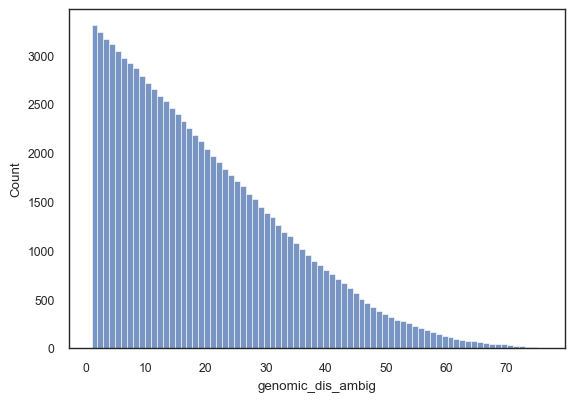

genomic_dis_ambig
1     3308
2     3244
3     3164
4     3112
5     3048
      ... 
72      20
73      16
74      12
75       8
76       4
Name: count, Length: 77, dtype: int64

In [49]:
bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()

sns.histplot(
    matrix_df[matrix_df.genomic_dis_ambig.notnull() & (matrix_df.genomic_dis_ambig != 0)],
    x='genomic_dis_ambig', bins=matrix_df.genomic_dis_ambig.max())
plt.show()

bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()
bins_per_genomic_dis

#### Comparing to best params from inference

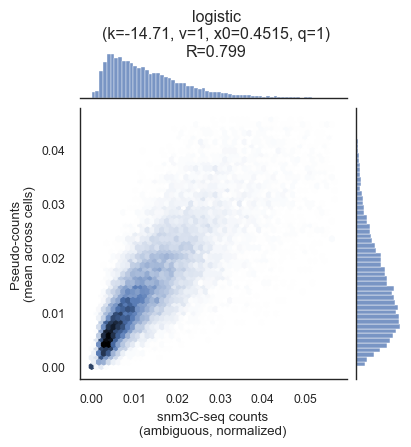

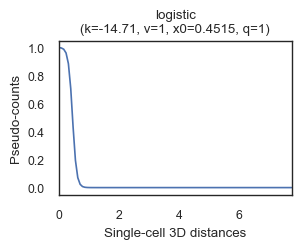

In [164]:
k, d0 = np.array([-14.71402465, 0.45154928])
nu = q = 1

assess_pseudocounts(matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, nu=nu, d0=d0, q=q), plot=True)[0]

plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0, q=q))

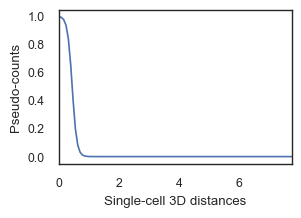

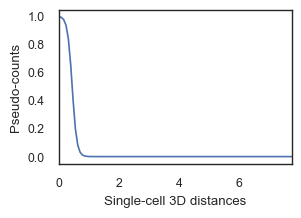

In [46]:
plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0, q=q))
plot_best_transfer_func(results_df, sc_dis)

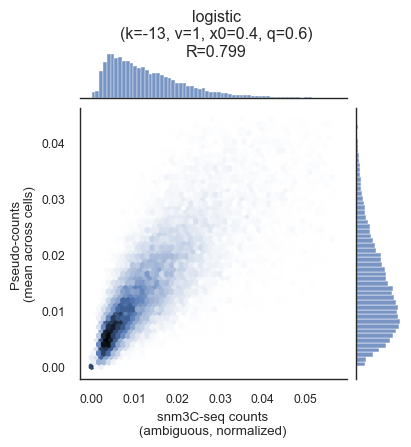

{'func': 'logistic',
 'func_kwargs': 'k=-13, v=1, x0=0.4, q=0.6',
 'mean': 0.7992016084888707,
 'med': 0.6570021242547587}

In [41]:
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df)[0]

#### Manual

In [ ]:
display(results_df.head(1).rename({0: f"BEST"}))
print()

for nu in [1]:
    for k in [round(-13 * nu, 2)]:
        for d0 in [0.4]:
            for q in [0.6]:
                results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, nu=nu, d0=d0, q=q))[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv(results_file, sep='\t', index=False)
    display(results_df[results_df.func_kwargs.str.contains(f'{k=},')].head(1))

results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
results_df.to_csv(results_file, sep='\t', index=False)
print('\nFINAL:')
display(results_df.head())


print('\n...')
display(results_df[results_df.func_kwargs.str.contains('q=') | (results_df.func_kwargs == 'k=-25, nu=2, d0=0.4')].head())


plot_best_transfer_func(results_df, sc_dis)
_ = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df)

,func,func_kwargs,mean,med
BEST,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.795715,0.655148


### Plot *transfer function*: comparing func / params

<Figure size 640x440 with 0 Axes>

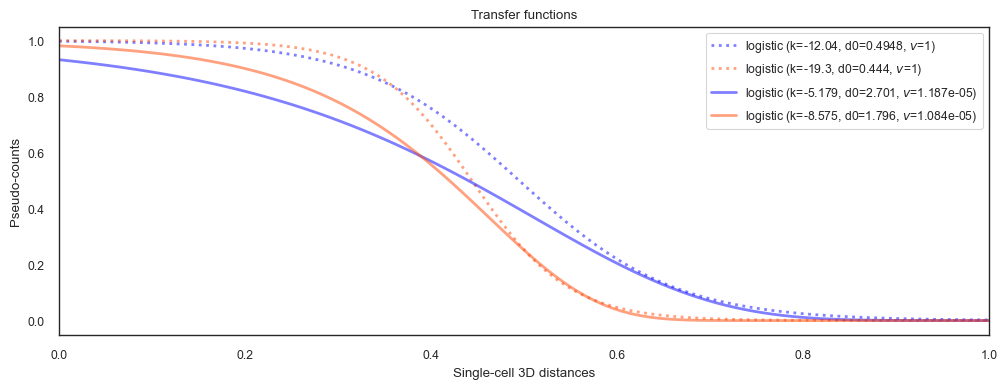

In [62]:
%run plot_pseudocount_func.py
kwargs_per_line = []

# k, d0 = np.array([-14.71402465, 0.45154928]); nu = 1 # best from INITIAL inference: pearson.weight0, seed=0
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0, q=q), color=None, linestyle=None))

# k=-53.3559;  d0=0.279179;  nu=15.7212    # obj=-0.75257981 ... pearson.weight-2.infer_nu, seed=1
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0, q=q), color=None, linestyle=None))

# k, d0 = [-30.394863085563795, 0.385748734297981]; nu = 1  # obj=0.055002832 ... rmse.weight-1, seed=0
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0, q=q), color=None, linestyle=None))


# ==== Old
# k=-9.13086;  d0=1.61319;  nu=2.62415e-05;  scaling=6.65188   # obj=0.18979348 → rmse.infer_nu, seed=init-mse (FACTR) # OLD - not as good obj (or same idk)
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='orangered', linestyle='--'))
# k=-5.14364;  d0=1.69303;  nu=0.00208403;  scaling=5.38264    # obj=-0.88644619 → pearson.infer_nu, seed=1 (FACTR) # OLD - not as good obj
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='blue', linestyle='--'))


# ==== Best results with imputed, NO-norm data
# k=-12.1386;  d0=0.480525;  nu=1;  scaling=4.2463;            # obj=-0.88616295 → pearson, seed=0 (FACTR)
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='blue', linestyle=':'))
# k=-20.0702;  d0=0.437226;  nu=1;  scaling=5.78779            # obj=0.190089 → rmse, seed=0 (PGTOL)
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='orangered', linestyle=':'))
# k=-5.15964;  d0=2.68554;  nu=1.22861e-05;  scaling=5.36133   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='blue', linestyle=None))
# k=-9.11523;  d0=1.72088;  nu=1e-05;  scaling=6.65738         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='orangered', linestyle=None))

# # ==== Best results with imputed + NORM data
# k=-9.65154;  d0=1.64148;  nu=1e-05;  scaling=0.573489        # obj=0.02028542196 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)              →→ exp=-0.582
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='green', linestyle=None))
# k=-13.4861;  d0=1.2826;  nu=1e-05;  scaling=0.630876         # obj=0.04694099398 → rmse.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) ~~~   →→ exp=-0.594
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='green', linestyle='--'))


# ==== Functions that do vs do not cause NaNs
# k=-35;  d0=0.3;  nu=1e-04;  scaling=0.63811         #      →→ exp=X
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='green', linestyle='--'))
# k=-25;  d0=0.3;  nu=1e-03;  scaling=0.63811         #      →→ exp=-0.774 ***
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='green', linestyle=None))
# k=-25;  d0=-0;  nu=1;  scaling=0.63811         #      →→ exp=?
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='green', linestyle=':'))


# # ==== Functions with good distance decay exponents
# k=-25;  d0=0.4;  nu=1e-04;         #      →→ exp=-0.775 ****
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='red', linestyle=':'))
# k=-25;  d0=0.3;  nu=1e-03;         #      →→ exp=-0.774 ***
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='orange', linestyle=':'))
# k=-35;  d0=0.3;  nu=1e-04;         #      →→ exp=-0.771 ***
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='green', linestyle=':'))
# k=-45;  d0=0;  nu=1;               #      →→ exp=-0.769 ***
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='purple', linestyle=':'))
# k=-50;  d0=0.01;  nu=1;               #      →→ exp=-0.77 (expected it to be decent, based on logistic func graph)
# q=1; kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, nu=nu, d0=d0), color='yellow', linestyle=None))


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED) - NORM BIN1/RESCALING FIXED
k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=0  (FACTR)
kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, d0=d0, nu=nu), color='blue', linestyle=':'))
k=-19.2999;  d0=0.443964;  nu=1                              # obj=0.01246724052 → rmse.buffer10, seed=0  (PGTOL)
kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, d0=d0, nu=nu), color='orangered', linestyle=':'))
k=-5.17941;  d0=2.70054;  nu=1.18687e-05                     # obj=-0.8710339124 → pearson.infer_nu.buffer10, seed=3  (FACTR)
kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, d0=d0, nu=nu), color='blue', linestyle=None))
k=-8.57474;  d0=1.79574;  nu=1.08414e-05                     # obj=0.01244820574 → rmse.infer_nu.buffer8, seed=3  (FACTR)
kwargs_per_line.append(dict(func=logistic, func_kwargs=dict(k=k, d0=d0, nu=nu), color='orangered', linestyle=None))


# print(f"infection point: {np.power(nu / (nu + 1), nu):g}")
# plot_transfer_func_multiple(sc_dis, kwargs_per_line, figsize=(6, 4), dpi=None, linewidth=2, xmax=2.5)
plot_transfer_func_multiple(sc_dis, kwargs_per_line, figsize=(12, 4), dpi=None, linewidth=2, xmax=1)

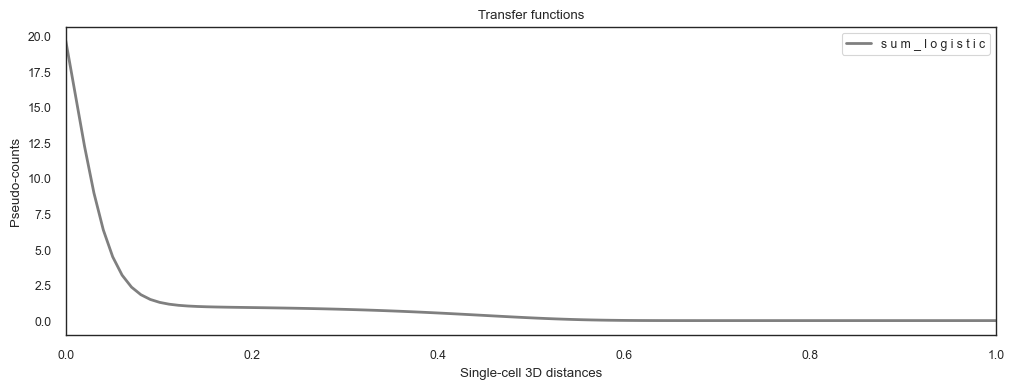

In [12]:
%run plot_pseudocount_func.py
kwargs_per_line = []

def sum_logistic(d, k, d0, nu, factor):
    res = np.zeros(d.shape)
    for i in range(len(k)):
        res += logistic(d, k=k[i], d0=d0[i], nu=nu[i]) * factor[i]
    return res


k2=[]; d02 = []; nu2 = []; factor2 = []
k=-50;  d0=0.01;  nu=1; factor = 30               #      →→ exp=-0.77 (expected it to be decent, based on logistic func graph)
k2.append(k); d02.append(d0); nu2.append(nu); factor2.append(factor)
k=-9.65154;  d0=1.64148;  nu=1e-05;  scaling=0.573489; factor = 1      # obj=0.02028542196 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)              →→ exp=-0.582
k2.append(k); d02.append(d0); nu2.append(nu); factor2.append(factor)
q=1; kwargs_per_line.append(dict(func=sum_logistic, func_kwargs=dict(k=k2, nu=nu2, d0=d02, factor=factor2), color='black', linestyle=None))


# k=-9.65154;  d0=1.64148;  nu=1e-05;  scaling=0.573489        # obj=0.02028542196 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)              →→ exp=-0.582

# k=-13.4861;  d0=1.2826;  nu=1e-05;  scaling=0.630876         # obj=0.04694099398 → rmse.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) ~~~   →→ exp=-0.594
plot_transfer_func_multiple(sc_dis, kwargs_per_line, figsize=(12, 4), dpi=None, linewidth=2, xmax=1)

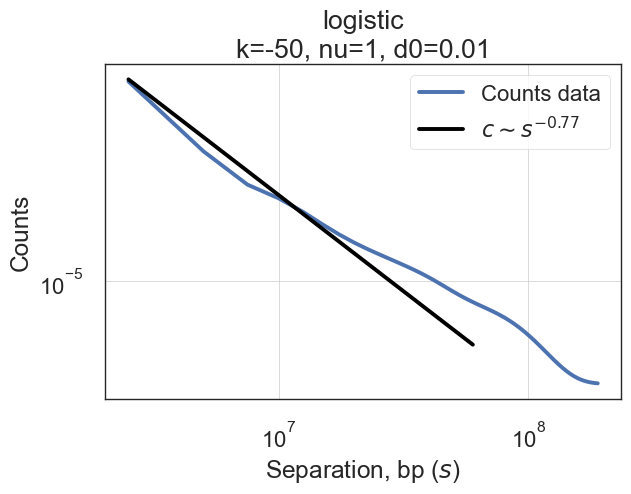

In [14]:
k=-50;  d0=0.01;  nu=1; factor = 30               #      →→ exp=-0.? ***
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, nu=nu, d0=d0))

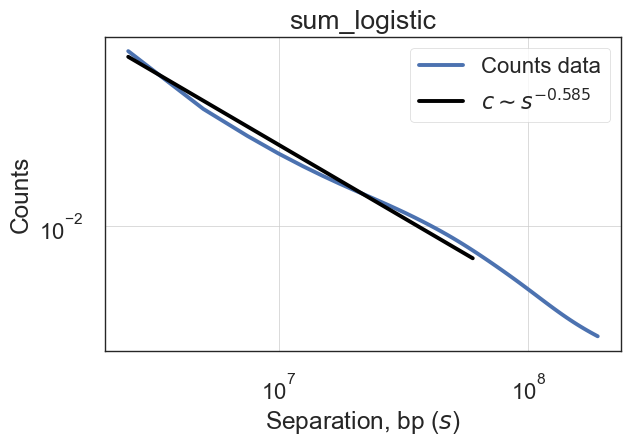

In [13]:
%run plot_pseudocount_func.py

_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=sum_logistic, transfer_func_kwargs=dict(k=k2, nu=nu2, d0=d02, factor=factor2))

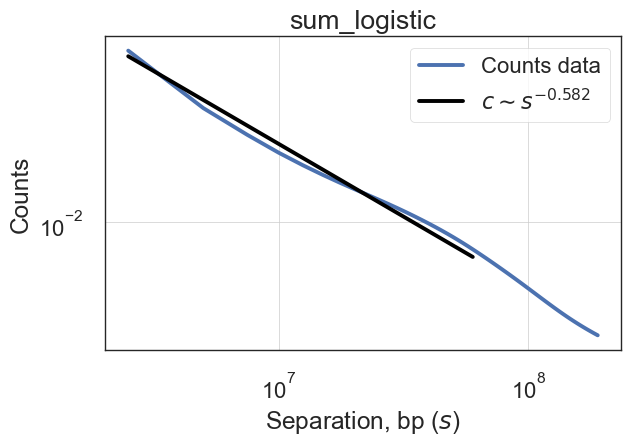

In [7]:
%run plot_pseudocount_func.py

# 6to1: exp=-0.582
# 10to1: exp=-0.583
# 30to1: exp=-0.585

_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=sum_logistic, transfer_func_kwargs=dict(k=k2, nu=nu2, d0=d02, factor=factor2))

#### Inflection point

In [ ]:
def get_y_at_inflection_point(v):
    return (v / (v + 1)) ** v

def get_x_from_y(y, x0, v, k):
    return x0 - np.log( (y**(-v) - 1)**(1/k) )

def y_when_x_is_x0(v, k=-1):
    return 2 ** (-1/v)

v = 0.01
y_at_inflection = get_y_at_inflection_point(v)
print(f"{y_at_inflection = :g}")
print(f"x_at_inflection = {get_x_from_y(y=y_at_inflection, x0=0, v=v, k=-1):g}")

print()
print(f"y_when_x_is_x0 = {y_when_x_is_x0(v=v):g}")

2**(-1/.2)

In [763]:
max_float64 = np.finfo(np.float64).max
print(f"Maximum value for np.float64: {max_float64}")

Maximum value for np.float64: 1.7976931348623157e+308


### Lower outliers

In [4]:
%run plot_pseudocount_func.py

k, d0 = [-30.394863085563795, 0.385748734297981]; nu = q = 1  # obj=0.055002832 ... rmse.weight-1, seed=0

##### Correlations

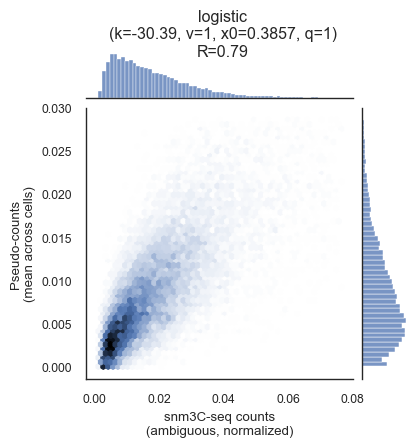

In [5]:
pearson_r, (_, matrix_df_ambig) = assess_pseudocounts(
    matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, nu=nu, d0=d0, q=q), plot=True)
matrix_df_ambig.drop('pc_med', axis=1, inplace=True)

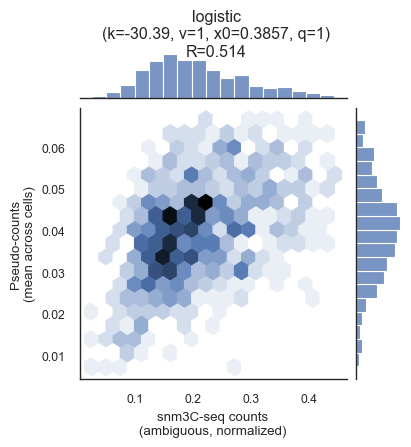

In [6]:
genomic_dis_min = genomic_dis_max = 1

pearson_r_s1, (_, matrix_df_ambig_s1) = assess_pseudocounts(
    matrix_df[(matrix_df.genomic_dis_ambig >= genomic_dis_min) & (matrix_df.genomic_dis_ambig <= genomic_dis_max)],
    sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, nu=nu, d0=d0, q=q), plot=True)
matrix_df_ambig_s1.drop('pc_med', axis=1, inplace=True)

#### Outlier locus pairs

##### Color locus pair by missingness

<Figure size 640x440 with 0 Axes>

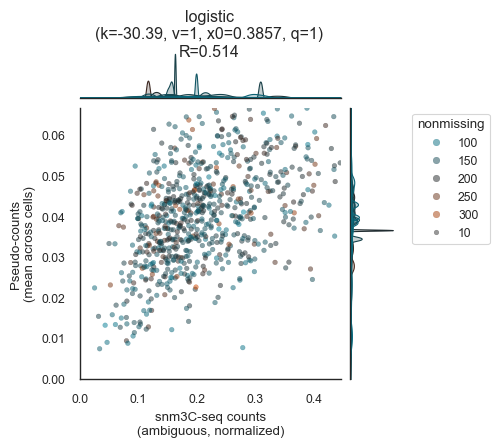

In [11]:
%run plot_pseudocount_func.py

plot_counts_corr(matrix_df_ambig_s1, pearson_r=pearson_r_s1, hue='nonmissing', alpha=0.5)

<Figure size 640x440 with 0 Axes>

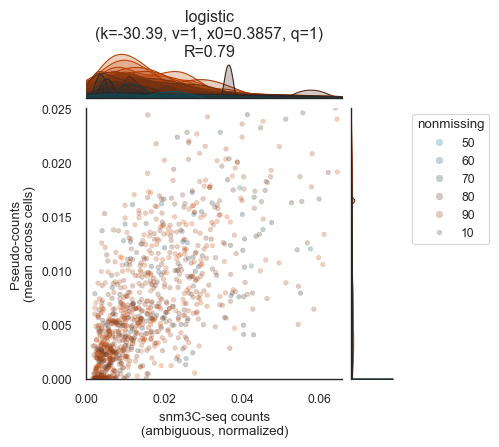

In [12]:
%run plot_pseudocount_func.py

# matrix_df_ambig['nonmissing_lt100'] = (matrix_df_ambig.nonmissing < 100).astype(int)
plot_counts_corr(matrix_df_ambig[matrix_df_ambig.nonmissing < 100], pearson_r=pearson_r, hue='nonmissing', alpha=0.25)

##### Assess matrix_df

In [19]:
print("============ AMBIGUATED ============")
print("\n====== For s=1:")
print(matrix_df_ambig_s1.nonmissing.describe().to_string(float_format=lambda x: f"{x:.4g}"))
# print('(nonmissing != 0).min() =', matrix_df_ambig_s1.loc[matrix_df_ambig_s1.nonmissing != 0, 'nonmissing'].min())
# display(matrix_df_ambig_s1[matrix_df_ambig_s1.nonmissing == matrix_df_ambig_s1.nonmissing.min()])


print("\n\n====== For all intra-chromosomal:")
print(matrix_df_ambig.nonmissing.describe().to_string(float_format=lambda x: f"{x:.4g}"))
# print('(nonmissing != 0).min() =', matrix_df_ambig.loc[matrix_df_ambig.nonmissing != 0, 'nonmissing'].min())
# display(matrix_df_ambig[matrix_df_ambig.nonmissing == matrix_df_ambig.nonmissing.min()].sort_values(
#     ['genomic_dis_ambig', 'i.idx_ambig', 'j.idx_ambig']))

============ AMBIGUATED ============

====== For s=1:
count     815
mean    165.2
std     43.35
min     67.25
25%     133.2
50%     161.2
75%     192.5
max       338


====== For all intra-chromosomal:
count   2.171e+04
mean        163.2
std         44.79
min            49
25%           131
50%         157.2
75%         189.2
max         423.8


In [33]:
# Is nonmissing associated with error (account for scaling)
scaling_factor = np.sum(matrix_df_ambig.pc_mean * matrix_df_ambig.snm3c) / np.sum(np.square(matrix_df_ambig.pc_mean))
matrix_df_ambig['err'] = (matrix_df_ambig.snm3c - matrix_df_ambig.pc_mean * scaling_factor).abs()

# matrix_df_ambig[["err", "nonmissing"]].corr(method='pearson').values[0, 1]  # not with pearson

cutoff = 0.01
print(matrix_df_ambig.nonmissing.quantile(cutoff))
print(matrix_df_ambig.loc[matrix_df_ambig.nonmissing <= matrix_df_ambig.nonmissing.quantile(cutoff), 'err'].pow(2).mean())
print(matrix_df_ambig.loc[matrix_df_ambig.nonmissing >= matrix_df_ambig.nonmissing.quantile(1 - cutoff), 'err'].pow(2).mean())

83.25
0.0013196505365893078
0.0004478479105114634


In [20]:
print("============ UNambig ============")
print("\n====== For s=1:")
print(matrix_df.loc[matrix_df.genomic_dis == 1, 'nonmissing'].describe().to_string(float_format=lambda x: f"{x:.4g}"))

print("\n\n====== For INTER-homolog:")
print(matrix_df.loc[matrix_df['mask.diffM'], 'nonmissing'].describe().to_string(float_format=lambda x: f"{x:.4g}"))

============ UNambig ============

====== For s=1:
count    1654
mean    215.2
std     62.25
min        83
25%       169
50%       211
75%     258.8
max       475


====== For INTER-homolog:
count   4.56e+04
mean       117.6
std        36.16
min           26
25%           91
50%          113
75%          139
max          366


#### Outlier loci

<Figure size 640x440 with 0 Axes>

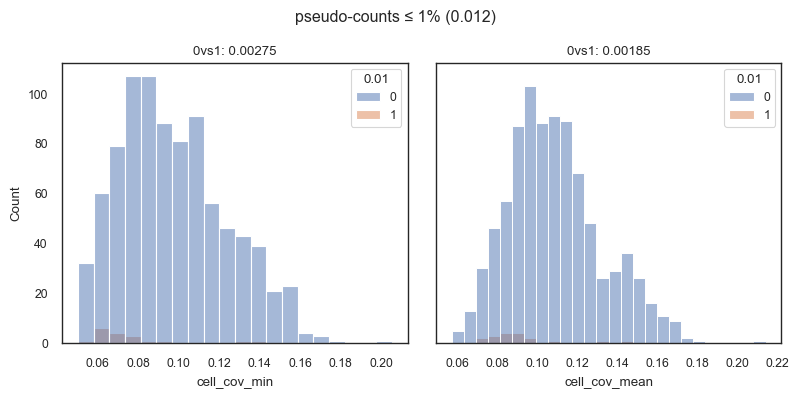

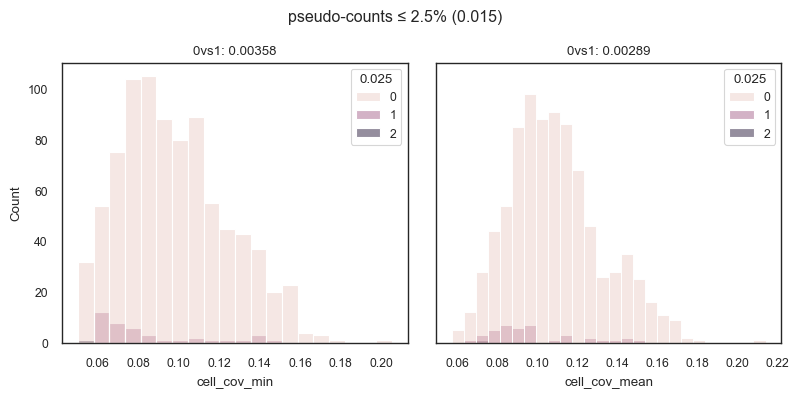

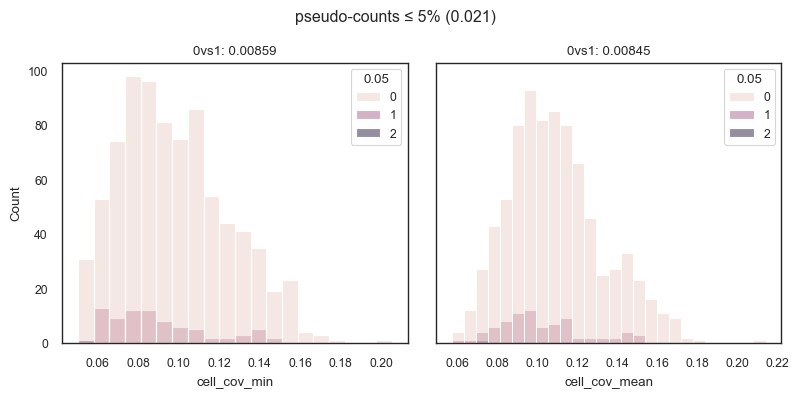

In [159]:
lengths_df_outliers = None

for perc_cutoff in [0.01, 0.025, 0.05]:
    outliers, lengths_df_outliers = assess_lower_outliers_loci(matrix_df_ambig_s1, lengths_df=lengths_df, perc_cutoff=perc_cutoff, lengths_df_outliers=lengths_df_outliers, verbose=False)

### With/without inter-hmlg data

#### Comparisons

In [732]:
result_idx = 0

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7951     current=0.7954     adding inter-hmlg ↑R by 0.03009%
med ... prev=0.6686     current=0.6665     adding inter-hmlg ↑R by -0.3209%


In [739]:
result_idx = 50

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7921     current=0.793     adding inter-hmlg ↑R by 0.1111%
med ... prev=0.8351     current=0.8321     adding inter-hmlg ↑R by -0.3673%


In [758]:
result_idx = results_df.loc[results_df.func == 'power'].index[0]

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7479     current=0.752     adding inter-hmlg ↑R by 0.5507%
med ... prev=0.7597     current=0.7625     adding inter-hmlg ↑R by 0.3647%


In [759]:
result_idx = results_df.loc[results_df.func == 'thresholded'].index[0]

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.739     current=0.7376     adding inter-hmlg ↑R by -0.1875%
med ... prev=nan      current=nan      adding inter-hmlg ↑R by nan%


#### Re-generate with inter-hmlg data

In [794]:
func = 'logistic'

filtered_for_func = results_df_intraM[(results_df_intraM.func == func)]
# display(filtered_for_func.loc[filtered_for_func.index.values[40:]])

# filtered_for_func.index.values[:40]

i = 40
# results_df_intraM.loc[i, 'func_kwargs']

In [789]:
# results_df_intraM = results_df.copy()

func = 'logistic'

filtered_for_func = results_df_intraM[(results_df_intraM.func == func)]
display(filtered_for_func)

for i in filtered_for_func.index.values[40:]:
    
    print(f'{i}')
    results.append(plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_intraM.loc[i].to_frame().T.reset_index(drop=True), plot=False)[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv(results_file, sep='\t', index=False)
    # display(results_df.head(1))

print('\nFINAL:')
display(results_df.head())

,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795123,0.668640
1,logistic,"k=-35, v=3, x0=0.4",0.795006,0.697630
2,logistic,"k=-45, v=4, x0=0.4",0.794885,0.711934
3,logistic,"k=-50, v=4, x0=0.4",0.794845,0.668559
4,logistic,"k=-40, v=3, x0=0.4",0.794814,0.639160
...,...,...,...,...
153,logistic,"k=-25, v=2, x0=1",0.730676,0.831061
155,logistic,"k=-2, v=1, x0=0",0.727009,0.755504
159,logistic,"k=-2.5, v=2, x0=0",0.698433,0.704401
160,logistic,"k=-15, v=1, x0=0",0.688459,0.580504


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39

FINAL:


,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795362,0.666494
1,logistic,"k=-35, v=3, x0=0.4",0.795301,0.695312
2,logistic,"k=-20, v=2, x0=0.4",0.795257,0.750934
3,logistic,"k=-45, v=4, x0=0.4",0.795207,0.709532
4,logistic,"k=-30, v=3, x0=0.4",0.795144,0.750747


### Threshold power func

In [539]:
# TODO Test this... with upper/lower cutoff, like for dist decay below !!!!

### Thresholded func

,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
THRESH: BEST,thresholded,cutoff=0.5,0.817584,NaN,NaN,NaN


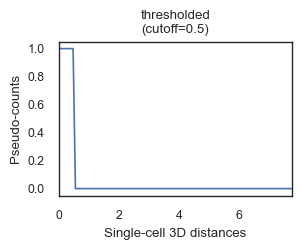

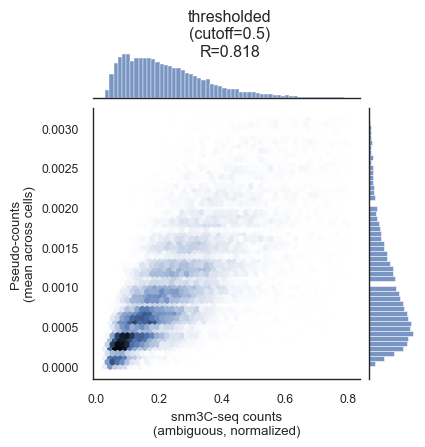

In [78]:
# results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.6), plot=False)[0])
# results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
# results_df.to_csv(results_file, sep='\t', index=False)

results_df_thr = results_df[results_df.func == 'thresholded'].reset_index(drop=True)
display(results_df_thr.head(1).rename({0: f"THRESH: BEST"}))
plot_best_transfer_func(results_df_thr, sc_dis=sc_dis)
_ = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_thr)

### Power func

,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
POWER: BEST,power,alpha=-1.3,0.845517,0.853837,NaN,NaN


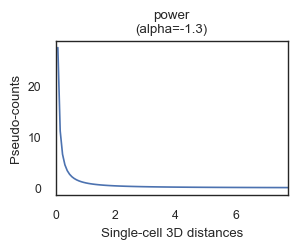

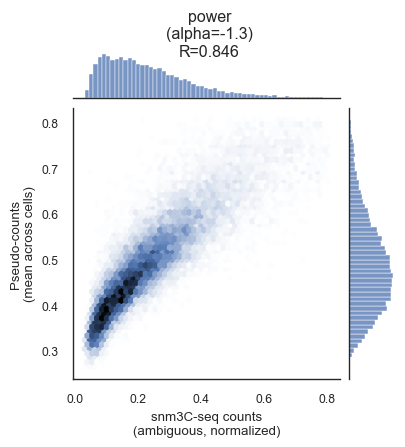

In [79]:
for alpha in []:
    results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=power, transfer_func_kwargs=dict(alpha=alpha), plot=False)[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv(results_file, sep='\t', index=False)

# results_df.loc[results_df.func_kwargs.str.contains('alpha'), 'func'] = 'power'

results_df_power = results_df[results_df.func == 'power'].reset_index(drop=True)
display(results_df_power.head(1).rename({0: f"POWER: BEST"}))
plot_best_transfer_func(results_df_power, sc_dis=sc_dis)
_ = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_power)

## Any sketchy cells?

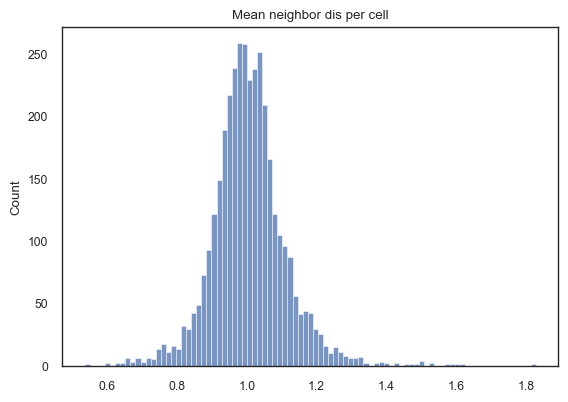

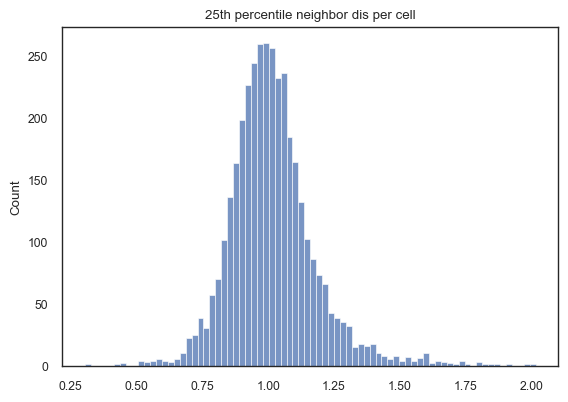

In [10]:
nghbr_dis = sc_dis.loc[matrix_df['mask.nghbr']]

nghbr_dis_per_mol = nghbr_dis.groupby([matrix_df['chrom'], matrix_df['i.hmlg']]).mean()
nghbr_dis_per_mol_agg = nghbr_dis_per_mol.values[nghbr_dis_per_mol.notnull().values]
# sns.histplot(nghbr_dis_per_mol_agg / np.median(nghbr_dis_per_mol_agg))
# plt.title('Mean neighbor dis per molecule')
# plt.show()

nghbr_dis_per_cell = nghbr_dis.mean()
nghbr_dis_per_cell_agg = nghbr_dis_per_cell.values[nghbr_dis_per_cell.notnull().values]
sns.histplot(nghbr_dis_per_cell_agg / np.median(nghbr_dis_per_cell_agg))
plt.title('Mean neighbor dis per cell')
plt.show()

nghbr_dis_per_mol_cellmin = nghbr_dis_per_mol.min()
nghbr_dis_per_mol_cellmin_agg = nghbr_dis_per_mol_cellmin.values[nghbr_dis_per_mol_cellmin.notnull().values]
# sns.histplot(nghbr_dis_per_mol_cellmin_agg / np.median(nghbr_dis_per_mol_cellmin_agg))
# plt.title('Mean neighbor dis per molecule: minimum per cell')
# plt.show()

nghbr_dis_per_cellmin = nghbr_dis.min()
nghbr_dis_per_cellmin_agg = nghbr_dis_per_cellmin.values[nghbr_dis_per_cellmin.notnull().values]
# sns.histplot(nghbr_dis_per_cellmin_agg)
# plt.title('Minimum neighbor dis per cell')
# plt.show()

q = 0.25
nghbr_dis_per_cellq = nghbr_dis.quantile(q)
nghbr_dis_per_cellq_agg = nghbr_dis_per_cellq.values[nghbr_dis_per_cellq.notnull().values]
sns.histplot(nghbr_dis_per_cellq_agg / np.median(nghbr_dis_per_cellq_agg)) 
plt.title(f'{q * 100:g}th percentile neighbor dis per cell')
plt.show()

# nghbr_dis_agg = nghbr_dis.values[nghbr_dis.notnull().values]
# sns.histplot(nghbr_dis)
# plt.show()

In [4]:
print('Neighbor dis: per cell')
print(pd.Series(nghbr_dis_per_cell_agg / np.median(nghbr_dis_per_cell_agg)).describe().to_string(float_format=lambda x: f"{x:.2g}"))

print('\nNeighbor dis: per molecule')
print(pd.Series(nghbr_dis_per_mol_agg / np.median(nghbr_dis_per_mol_agg)).describe().to_string(float_format=lambda x: f"{x:.2g}"))

print('\nMean neighbor dis per molecule: minimum per cell')
print(pd.Series(nghbr_dis_per_mol_cellmin_agg / np.median(nghbr_dis_per_mol_cellmin_agg)).describe().to_string(float_format=lambda x: f"{x:.2g}"))


print('\nNeighbor dis: min per cell')
print(pd.Series(nghbr_dis_per_cellmin / np.median(nghbr_dis_per_cellmin)).describe().to_string(float_format=lambda x: f"{x:.2g}"))

Neighbor dis: per cell
count   3.7e+03
mean          1
std        0.11
min        0.54
25%        0.95
50%           1
75%         1.1
max         1.8

Neighbor dis: per molecule
count   2.9e+04
mean          1
std        0.19
min        0.19
25%         0.9
50%           1
75%         1.1
max         3.8

Mean neighbor dis per molecule: minimum per cell
count   3.7e+03
mean          1
std        0.19
min        0.22
25%        0.89
50%           1
75%         1.1
max         2.1

Neighbor dis: min per cell
count   3.7e+03
mean        1.2
std        0.73
min        0.09
25%        0.67
50%           1
75%         1.5
max         6.3


In [9]:
1/.95

1.0526315789473684

In [131]:
count_nghbr_dis_per_mol = nghbr_dis.groupby([matrix_df['chrom'], matrix_df['i.hmlg']]).count()
count_nghbr_dis_per_mol_agg = count_nghbr_dis_per_mol.values[(count_nghbr_dis_per_mol != 0).values]
print(pd.Series(count_nghbr_dis_per_mol_agg).describe())

count_nghbr_dis_per_cell = nghbr_dis.count()
print(count_nghbr_dis_per_cell.describe())

Series([], dtype: float64)

## Quick distance decay assessment

scaling=2.29393


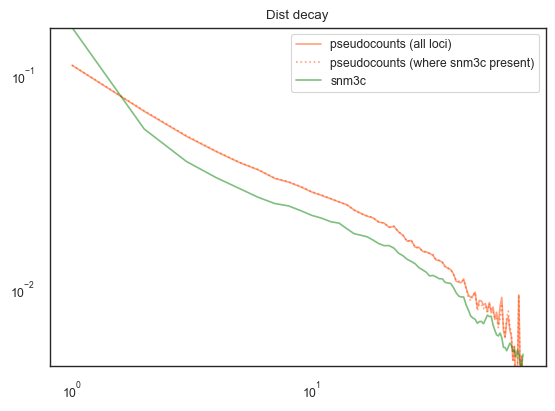

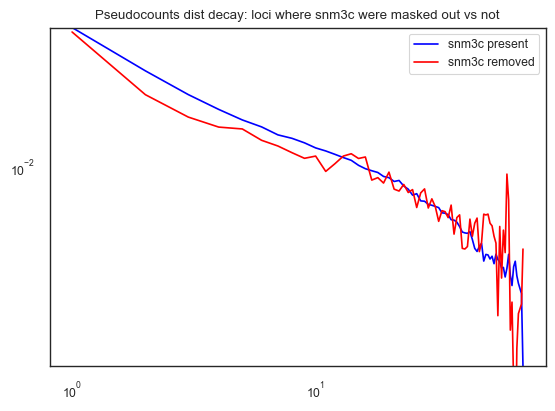

In [53]:
# =============== GOOD DIST DECAY (re Q, IMPUTED + norm)
# q=1
# k=-50;  d0=0.01;  nu=1               #      →→ exp=-0.77 (expected it to be decent, based on logistic func graph)


# =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED)
# q=1
# k=-5.63538;  d0=2.45539;  nu=1.51704e-05;  scaling=0.460945  # obj=-0.8249887143 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
k=-9.65135;  d0=2.35724;  nu=1e-8;  scaling=0.573493         # obj=0.0202854218 → rmse.nu1e-8_buffer1e-4, seed=1  (PGTOL)
# k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)


# # =============== INFERRED WITH Q+norm (IMPUTED + NORMALIZED, 500kb !!!)
# q=1
# # # k=-11.6521;  d0=0.437924;  nu=1;  scaling=0.0524599          # obj=-0.8763556252 → pearson.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0  (FACTR)
# k=-4.81891;  d0=2.35205;  nu=0.0001;  scaling=0.069748       # obj=-0.8767473452 → pearson.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=1  (FACTR)
# # k=-15.4894;  d0=0.427465;  nu=1;  scaling=0.0596799          # obj=0.001799740524 → rmse.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0  (PGTOL)
# # k=-6.58329;  d0=1.83956;  nu=0.0001;  scaling=0.0740174      # obj=0.001796031432 → rmse.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0  (FACTR)

# _, (_, matrix_df_ambig) = assess_pseudocounts(
#     matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, nu=nu, d0=d0, q=q), plot=False, remove_null_snm3c=False)

pseudocounts = matrix_df_ambig.loc[matrix_df_ambig.snm3c.notnull(), 'pc_mean'].values
snm3c = matrix_df_ambig.loc[matrix_df_ambig.snm3c.notnull(), 'snm3c'].values
scaling = get_pseudocounts_scaling_factor(pseudocounts, snm3c=snm3c)._value
print(f"{scaling=:g}")

for desc, df in {'all loci': matrix_df_ambig, 'where snm3c present': matrix_df_ambig.loc[matrix_df_ambig.snm3c.notnull()]}.items():
    gb = df.groupby('genomic_dis_ambig')[['snm3c', 'pc_mean', 'pc_med']]
    gb_mean = gb.mean()
    gb_med = gb.median()
    gb_mean[['pc_mean', 'pc_med']] *= scaling
    gb_med[['pc_mean', 'pc_med']] *= scaling
    
    s_mean_vs_med = gb_mean.join(gb_med, lsuffix='.mean', rsuffix='.med')
    # plt.loglog(s_mean_vs_med.index.values, s_mean_vs_med['snm3c.med'].values, c='red', alpha=0.5, linestyle=':')
    plt.loglog(s_mean_vs_med.index.values, s_mean_vs_med['pc_mean.mean'].values, c='orangered', alpha=0.5, linestyle=None if desc == 'all loci' else ':', label=f'pseudocounts ({desc})')
    # plt.loglog(s_mean_vs_med.index.values, s_mean_vs_med['pc_mean.med'].values, c='red', alpha=0.5)
    # plt.loglog(s_mean_vs_med.index.values, s_mean_vs_med['pc_med.mean'].values, c='blue', alpha=0.5)
    # plt.loglog(s_mean_vs_med.index.values, s_mean_vs_med['pc_med.med'].values, c='red', alpha=0.5)
plt.loglog(s_mean_vs_med.index.values, s_mean_vs_med['snm3c.mean'].values, c='green', alpha=0.5, linestyle=None, label='snm3c')
plt.legend()
plt.ylim(s_mean_vs_med['snm3c.mean'].min(), s_mean_vs_med['snm3c.mean'].max())
plt.title('Dist decay')
plt.show()

tmp = matrix_df_ambig.groupby(['genomic_dis_ambig', matrix_df_ambig.snm3c.isnull()]).pc_mean.mean().unstack().rename({True: 'removed', False: 'present'}, axis=1)
mask = tmp.removed.notnull()
plt.loglog(tmp[mask].index, tmp.loc[mask, 'present'], c='blue', label='snm3c present')
plt.loglog(tmp[mask].index, tmp.loc[mask, 'removed'], c='red', label='snm3c removed')
plt.legend()
plt.ylim(tmp.loc[mask, 'present'].min(), tmp.loc[mask, 'present'].max())
plt.title('Pseudocounts dist decay: loci where snm3c were masked out vs not')
plt.show()

In [58]:
# rowsums = pd.Series(0, index=lengths_df.idx_genome.values)
# matrix_df_ambig.groupby('i.idx_ambig').pc_mean.sum()
# matrix_df_ambig.groupby('j.idx_ambig').pc_mean.sum()


rowsums = pd.concat([
    matrix_df_ambig.groupby('i.idx_ambig')[['snm3c', 'pc_mean']].sum(),
    matrix_df_ambig.groupby('j.idx_ambig')[['snm3c', 'pc_mean']].sum()]).groupby(level=0).sum()
rowsums['pc_mean'] *= scaling 
rowsums.loc[rowsums.snm3c == 0, 'snm3c'] = np.nan

display(rowsums.describe())

# Make their means equivalent to check whether the relative variance of pc_mean really is larger
print('\nWith means forced to be equivalent:')
rowsums2 = rowsums.copy()
rowsums2['pc_mean'] *= rowsums2['snm3c'].mean() / rowsums2['pc_mean'].mean()
display(rowsums2.describe())

,snm3c,pc_mean
count,881.000000,900.000000
mean,1.241150,1.404386
std,0.158822,0.271241
min,0.641088,0.535427
25%,1.153176,1.234266
50%,1.237487,1.416128
75%,1.329860,1.594233
max,1.764569,2.188484



With means forced to be equivalent:


,snm3c,pc_mean
count,881.000000,900.000000
mean,1.241150,1.241150
std,0.158822,0.239714
min,0.641088,0.473193
25%,1.153176,1.090803
50%,1.237487,1.251527
75%,1.329860,1.408931
max,1.764569,1.934110


## Looking at inter-hmlg data (intra-chrom only)

### Plot inter-hmlg data

INTER-HMLG DATA - SINGLE-CELL:

NaNs are 96.8% of the data

5,360,238 non-NaN values, summary:
mean     4.18
std      1.71
min      0.03
25%      2.94
50%      4.06
75%      5.29
max     13.14


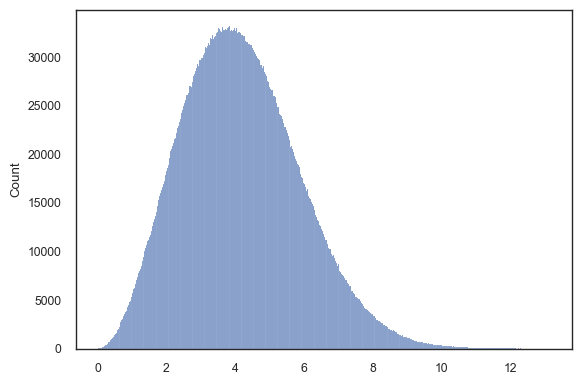



INTER-HMLG DATA - MEAN ACROSS CELLS:

NaNs are 0% of the data

45,598 non-NaN values, summary:
mean    4.17
std     0.36
min     2.61
25%     3.97
50%     4.21
75%     4.43
max     5.42


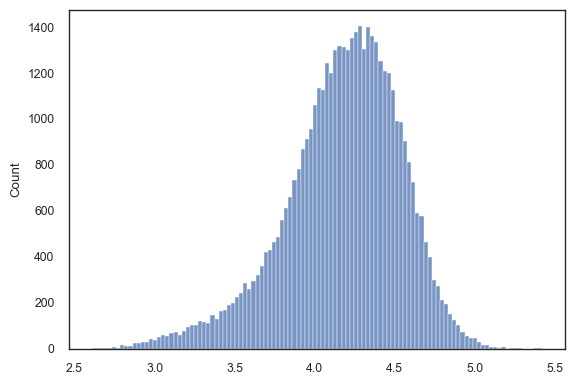

In [710]:
tmp = sc_dis.loc[matrix_df[matrix_df['mask.diffM']].index].values
print(f"INTER-HMLG DATA - SINGLE-CELL:\n\nNaNs are {np.isnan(tmp).sum() / tmp.size * 100:.3g}% of the data")
tmp = tmp[~np.isnan(tmp)]
print(f'\n{tmp.size:,} non-NaN values, summary:\n' + pd.Series(tmp).describe().round(2).drop('count').to_string())
sns.histplot(tmp)
plt.show()

tmp = sc_dis.loc[matrix_df[matrix_df['mask.diffM']].index].mean(axis=1).values
print(f"\n\nINTER-HMLG DATA - MEAN ACROSS CELLS:\n\nNaNs are {np.isnan(tmp).sum() / tmp.size * 100:.3g}% of the data")
tmp = tmp[~np.isnan(tmp)]
print(f'\n{tmp.size:,} non-NaN values, summary:\n' + pd.Series(tmp).describe().round(2).drop('count').to_string())
sns.histplot(tmp)
plt.show()

tmp = None

# Infer pseudocounts transfer func params

## Infer - qsub

### Submit

In [432]:
%%bash

# qlogin -l mfree=60G,cpuid_level=13

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/jupyter;
dir_matrix2d='/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d';
mcool_file='/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool';
# mcool_file='/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool';
resolution=2.5;
# resolution=0.5;
sge_outdir='nobackup/sge_out';
if [[ "$mcool_file" == *'Raw'* ]]; then
    sge_outdir="$sge_outdir/snm3c_raw-norm";
else
    sge_outdir="$sge_outdir/snm3c_q-norm";
fi
sge_outdir="$sge_outdir."$( bc <<< "scale=0; ($resolution * 1000)/1" )"kb";
mkdir -p "$sge_outdir";
echo "$sge_outdir";
dis_factor=1;

run_inference() {
    param_arg='';
    use_sge=$1; shift;
    seed=$1; shift;
    obj_type=$1; shift;
    weight=$1; shift;
    if [[ "$1" == 'false' ]]; then
        shift;
    else
        while [[ "$1" == "--"* ]]; do
            param_arg="$param_arg $1"; shift;
            param_arg="${param_arg/ /}";
        done
    fi
    factr=$1; shift;
    pgtol=$1; shift;
    maxls=$1; shift;
    max_iter=$1; shift;
    constraint=$1; shift;
    init=$1; shift;

    echo -e "====== seed=$seed, obj_type=$obj_type, weight=$weight, constraint=$constraint, params='$param_arg', factr=$factr, pgtol=$pgtol, maxls=$maxls, maxiter=$max_iter; init='$init'";

    args_str=$( echo "$param_arg" | sed -r 's/(^ *){0,1}--infer_(nu|q|a)( *$){0,1}/\2/g;s/q nu/nu q/;s/ /_/;s/^(.)/.infer_\1/' );
    jobname="FIT.$obj_type.weight$weight$args_str";
    if [[ "$constraint" != 0 ]]; then
        jobname="$jobname.constrain$constraint"
    fi
    jobname="$jobname.s$seed"
    jobname=$( echo "$jobname" | sed -r 's/\.weight0//;s/\.s[^0-9]+(\..+|$)/.init\1/i' );

    # note='kmax-4_buffer1e-5_d0min50p';
    # dis_factor=1e8; note="dfact$dis_factor"'_buffer1e-8';
    # note='buffer1e-4';
    # note='nu1e-8_buffer1e-4';
    # note='buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2';
    note='buffer8';
    # note='buffer10';
    jobname=$( echo "$jobname" | sed -r 's/(\.s[0-9]+|\.init)(\..+|$)/.'$note'\1\2/' );

    if [[ "$seed" =~ ^[0-9][0-9]*$ ]]; then
        seed_arg="--seed $seed";
    else
        seed_arg="--init '$init'";
    fi

    # echo "$jobname"
    if $use_sge; then
        qsub -P noblelab -cwd -V -l mfree=60G -o "$sge_outdir" -j "yes" -N "$jobname" -R y -b y \
        python fit_pseudocount_func.py "$dir_matrix2d" --mcool_file "$mcool_file" --resolution "$resolution" --normalize \
        --outdir 'nobackup' --factr $factr --pgtol $pgtol --maxls $maxls --obj_type $obj_type --weights_exponent $weight \
        --max_iter $max_iter --constraint_penalty $constraint $param_arg $seed_arg --dis_factor $dis_factor 2>&1 | grep -v modified;
    else
        echo "$jobname";
        # python fit_pseudocount_func.py "$dir_matrix2d" --mcool_file "$mcool_file" --resolution "$resolution" --normalize \
        # --outdir 'nobackup' --factr $factr --pgtol $pgtol --maxls $maxls --obj_type $obj_type --weights_exponent $weight \
        # --max_iter $max_iter --constraint_penalty $constraint $param_arg $seed_arg --dis_factor $dis_factor; #--no-jit
    fi
}


# ====== OPTIONS
max_iter=1e20;

obj_type="mse"; # obj_type="rmse";
# obj_type="pearson";

weight=0; # weight='-1';
# weight='-1';
# weight='-2';

# constraint_penalty=0
constraint_penalty=1

# params=false; maxls=20; factr=10; pgtol=1e-10;
# params='--infer_nu'; maxls=40; factr=0.1; pgtol=1e-15 # maxls=20
# params='--infer_nu'; maxls=50; factr=1e-3; pgtol=1e-15;
# params='--infer_nu'; maxls=50; factr=1e-2; pgtol=1e-12;
# params=false; maxls=50; factr=1e-2; pgtol=1e-12;
# params='--infer_nu'; maxls=50; factr=1e-4; pgtol=1e-16;
params=false; maxls=50; factr=1e-4; pgtol=1e-16;

seeds=$(seq 0 3); init='';
# seeds='init-mse'; init='-9.11602,1.46818,0.0001'; # seeds='init-pearson'; init='-5.16105,2.21109,0.0001';
# seeds='init-test'; init='-3.194,1.81217,1e-08';
# seeds='init-test'; init='-1,0.5,1e-08';
# seeds='init-test'; init='-9.22412,0.78152,1e-08';

use_sge=true;
max_iter=0; use_sge=false;    seeds=0

for seed in $seeds; do
    run_inference $use_sge $seed $obj_type $weight $params $factr $pgtol $maxls $max_iter $constraint_penalty $init
done

nobackup/sge_out/snm3c_q-norm.2500kb
====== seed=0, obj_type=mse, weight=0, constraint=1, params='', factr=1e-4, pgtol=1e-16, maxls=50, maxiter=0; init=''
FIT.mse.constrain1.buffer10.s0


### Assess

In [3]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/jupyter/nobackup/sge_out/snm3c_q-norm.2500kb

gcq stat x | grep -v JUPYTER

prev_desc='';
# for each in $( find . -maxdepth 1 -type f | sort | grep 'd0min50p' ); do
for each in $( find . -maxdepth 1 -type f | sort ); do
    desc=$( echo $each | sed -r 's/.*FIT\.//;s/\.(s[0-9]+|init[^.]*)\.o[0-9]+$//' );
    seed=$( echo $each | sed -r 's/.+\.(s[0-9]+|init[^.]*)\.o[0-9]+$/\1/;s/^s//' );
    if [[ "$prev_desc" != "$desc" ]]; then
        echo -e "\n====== "$( echo "$desc" | sed 's/\./, /g' );
    fi
    final='...'; scaling_factor=''; conv='';
    if grep -q 'results   scaling_factor' "$each"; then
        final='✓✓✓';
        # scaling_factor=";  scaling="$( grep 'results   scaling_factor' "$each" | \
        #                                sed -r 's/^.+scaling_factor +\[{0,1}([0-9., ]+)\]{0,1}$/\1/' );
        conv=" ("$( grep "results             task" "$each" | \
                   sed -r 's/^.+task +([A-Z: <=*]+) {0,1}$/\1/;s/^.+<= //;s/: *//;s/\*EPSMCH//' )")";
    fi
    last_iter=$( grep 'd₀.*obj=' "$each" | tail -n 1 | sed -r $'s/ +\.\.\. /#/;s/   */;  /g;s/#/# /' );
    obj=$( echo "$last_iter" | sed -r 's/^.+# obj=//' );
    params=$( echo "$last_iter" | sed -r 's/# obj=.+$//;s/d₀/d0/;s/𝜈/nu/' )
    if ! grep -q ";  nu=" <( echo "$params" ); then
        params="$params;  nu=1"
    fi
    params=$( printf "%-60s" "$params$scaling_factor" )
    echo -e "$final\t$params # obj=$obj → $desc, seed=$seed $conv";

    prev_desc="$desc";
done

# # =============== INFERRED WITH Q-orig, 2500kb (IMPUTED + NOT normalized) - best results:
# k=-5.15964;  d0=2.68554;  nu=1.22861e-05;  scaling=5.36133   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) (no norm)
# k=-9.11523;  d0=1.72088;  nu=1e-05;  scaling=6.65738         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) (no norm)

# # =============== INFERRED WITH Q+norm, 2500kb (IMPUTED + NORMALIZED) - best results: *PRIOR TO FIXING NORM & RESCALING*
# k=-5.63538;  d0=2.45539;  nu=1.51704e-05;  scaling=0.460945  # obj=-0.8249887143 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# k=-9.65135;  d0=2.35724;  nu=1e-8;  scaling=0.573493         # obj=0.0202854218 → rmse.nu1e-8_buffer1e-4, seed=1  (PGTOL)
# k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)

# k=-5.63537;  d0=2.36219;  nu=2.56495e-05                     # obj=-0.8249887132 → pearson.infer_nu.buffer8, seed=2 (temp!)
# k=-9.65155;  d0=1.6259;  nu=1.16258e-05                      # obj=0.020285422 → rmse.infer_nu.buffer8, seed=2 (temp!)

# # =============== INFERRED WITH Q+norm, 2500kb (IMPUTED + NORMALIZED) - FIXED NORM: bin1 & rescaling (prior to rescaling snm3c so mean of s=1 is 1)
# iter1
# k=-3.63038     d₀=1.34612      𝜈=0.0819471   ... obj=0.01398689231 # rmse.infer_nu.buffer8, seed=0... vs obj=0.02235681615 prior to fixing norm & rescaling
# k=-4.88178     d₀=4.74242      𝜈=0.288319    ... obj=0.0238828463  # rmse.infer_nu.buffer8, seed=1 
# k=-7.38388     d₀=1.48935      𝜈=1.62845     ... obj=0.01971754195 # rmse.infer_nu.buffer8, seed=2 
# k=-9.14351     d₀=1.18159      𝜈=1.60255     ... obj=0.0178763372  # rmse.infer_nu.buffer8, seed=3 
# BEST
# k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=0  (FACTR)
# k=-19.2999;  d0=0.443964;  nu=1                              # obj=0.01246724052 → rmse.buffer10, seed=0  (PGTOL)
# k=-5.17941;  d0=2.70054;  nu=1.18687e-05                     # obj=-0.8710339124 → pearson.infer_nu.buffer10, seed=3  (FACTR)
# k=-8.57474;  d0=1.79574;  nu=1.08414e-05                     # obj=0.01244820574 → rmse.infer_nu.buffer8, seed=3  (FACTR)

# # =============== INFERRED WITH Q+norm, 2500kb (IMPUTED + NORMALIZED) - FIXED NORM: bin1 & rescaling (after rescaling snm3c so mean of s=1 is 1)



running: 1

====== pearson, buffer10
✓✓✓	k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=0  (FACTR)
✓✓✓	k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=1  (FACTR)
✓✓✓	k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=2  (FACTR)
✓✓✓	k=-12.0392;  d0=0.494796;  nu=1                              # obj=-0.8707179326 → pearson.buffer10, seed=3  (FACTR)

====== pearson, infer_nu, buffer10
✓✓✓	k=-3.6147;  d0=1.71735;  nu=1e-10                            # obj=nan → pearson.infer_nu.buffer10, seed=0  (ABNORMAL)
✓✓✓	k=-4.45301;  d0=5.64964;  nu=1e-10                           # obj=-0.8710005482 → pearson.infer_nu.buffer10, seed=1  (FACTR)
✓✓✓	k=-5.1845;  d0=1.71732;  nu=1e-10                            # obj=nan → pearson.infer_nu.buffer10, seed=2  (ABNORMAL)
✓✓✓	k=-5.17941;  d0=2.70054;  nu=1.18687e-05                     # 

#### idk

In [429]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/jupyter/nobackup/sge_out/snm3c_q-norm.2500kb

# ls FIT.*
# ls FIT.* | grep -v buffer | wc -l

for each in $( ls FIT.* ); do
    # echo "$each";
    new=$( echo "$each" | sed -r 's/(\.s[0-9]+\.|\.init[^.]*\.)/.PREsnm3C_s1_1\1/' );
    # echo "$new"
    mv "$each" "$new";
done

mkdir old
mv *PREsnm3C_s1_1* old

ls

old


In [ ]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/jupyter/nobackup/sge_out/snm3c_q-norm

# CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

# | grep -E 'obj=(-0|0.49781722)$';

for each in $( ls FIT.*.infer_nu.kmax*.s* ); do
    if tail -n 1 "$each" | grep -q '^results   scaling_factor'; then
        echo -e "\n======== $each ========"
        tail -n 45 "$each"  | grep -vE '(^  input|^a +)' | grep -vE 'results +.+[^]]$' | grep -E '^(k.+ \.\.\.|results +)';
        # mv "$each" old
    fi
done

# at_bounds=''
# for each in $( ls FIT.*.infer_nu.* old/FIT.*.infer_nu.* ); do
#     tmp=$( grep '  *𝜈=1e-0[5678]  *... obj=' "$each" | grep -v 'd₀=-' | sed -r 's/... obj=(nan|-0$|0.4978[0-9]*)/XX nan/;s/... obj=/✓ obj=/;s/([k𝜈]|d₀)=//g' | sed $'s/  */\t/g' );
#     at_bounds="$at_bounds:$tmp"
# done
# at_bounds=$( echo "$at_bounds" | sed 's/::*/:/g;s/:$//;s/^://' )
# echo "$at_bounds" | tr ':' '\n' | sort -k3,3 -k4,4 -k2,2n | grep $'\t1e-05\t'
# #| grep $'\t-'

# rm *kmax*

# tail FIT.*.infer_nu.kmax*
# tail -n 100 FIT.rmse.infer_nu.kmax-5.s0.o20515424

# ls FIT.*.infer_nu.kmax-4_buffer1e-5*
# cat FIT.*.infer_nu.kmax-4_buffer1e-5* | grep -E 'd₀=0.[^9]'

#### Results desc txt

In [ ]:
# IMPUTED, NORMALIZED, 500kb !!

# k=-11.6521;  d0=0.437924;  nu=1;  scaling=0.0524599          # obj=-0.8763556252 → pearson.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0  (FACTR)
# k=-4.81891;  d0=2.35205;  nu=0.0001;  scaling=0.069748       # obj=-0.8767473452 → pearson.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=1  (FACTR)
# k=-15.4894;  d0=0.427465;  nu=1;  scaling=0.0596799          # obj=0.001799740524 → rmse.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0  (PGTOL)
# k=-6.58329;  d0=1.83956;  nu=0.0001;  scaling=0.0740174      # obj=0.001796031432 → rmse.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0  (FACTR)

In [ ]:
# IMPUTED, NORMALIZED, 2500kb
# /net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/jupyter/nobackup/sge_out/snm3c_q-norm.2500kb/

# ====== pearson, infer_nu, kmax-4_buffer1e-5_d0min50p
# ✓✓✓	k=-5.63538;  d0=2.45539;  nu=1.51704e-05;  scaling=0.460945  # obj=-0.8249887143 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# ✓✓✓	k=-5.63538;  d0=2.41163;  nu=1.94131e-05;  scaling=0.460945  # obj=-0.8249887139 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)

# ====== pearson, weight-1, infer_nu, kmax-4_buffer1e-5_d0min50p
# ✓✓✓	k=-5.75977;  d0=0.982889;  nu=0.0726394;  scaling=0.365714   # obj=-0.8376003456 → pearson.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# ✓✓✓	k=-5.3679;  d0=1.58719;  nu=0.0034379;  scaling=0.373551     # obj=-0.8375998509 → pearson.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)

# ====== pearson, weight-2, infer_nu, buffer1e-4
# ✓✓✓	k=-3.28051;  d0=0.0803431;  nu=1;  scaling=0.423193          # obj=-0.7655715825 → pearson.weight-2.infer_nu.buffer1e-4, seed=0  (PGTOL)
# ✓✓✓	k=-1;  d0=0.0803431;  nu=0.234613;  scaling=4.29548          # obj=-0.7653116592 → pearson.weight-2.infer_nu.buffer1e-4, seed=1  (PGTOL)

# ====== pearson, weight-2, infer_nu, kmax-4_buffer1e-5_d0min50p
# ✓✓✓	k=-4;  d0=0.924222;  nu=0.240699;  scaling=0.254873          # obj=-0.7633982813 → pearson.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# ✓✓✓	k=-6.78401;  d0=2.9059;  nu=1e-05;  scaling=0.0533459        # obj=-0.7359213872 → pearson.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)

# ====== rmse, infer_nu, dfact1e4_buffer1e-4
# ...	k=nan;  d0=nan;  nu=nan                                      # obj=nan → rmse.infer_nu.dfact1e4_buffer1e-4, seed=init 

# ====== rmse, infer_nu, dfact1e8_buffer1e-8
# ...	k=nan;  d0=nan;  nu=nan                                      # obj=nan → rmse.infer_nu.dfact1e8_buffer1e-8, seed=init 

# ====== rmse, infer_nu, kmax-4_buffer1e-5_d0min50p
# ...	k=nan;  d0=nan;  nu=nan                                      # obj=nan → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=init 
# ✓✓✓	k=-9.65144;  d0=1.6415;  nu=1e-05;  scaling=0.573492         # obj=0.02028542196 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (PGTOL)
# ✓✓✓	k=-9.65154;  d0=1.64148;  nu=1e-05;  scaling=0.573489        # obj=0.02028542196 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)

# ====== rmse, nu1e-8_buffer1e-4
# ...	k=nan;  d0=nan;  nu=1                                        # obj=nan → rmse.nu1e-8_buffer1e-4, seed=0 
# ✓✓✓	k=-9.65135;  d0=2.35724;  nu=1;  scaling=0.573493            # obj=0.0202854218 → rmse.nu1e-8_buffer1e-4, seed=1  (PGTOL)

# ====== rmse, weight-1, infer_nu, kmax-4_buffer1e-5_d0min50p
# ✓✓✓	k=-13.4861;  d0=1.2826;  nu=1e-05;  scaling=0.630876         # obj=0.04694099398 → rmse.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# ✓✓✓	k=-6.59108;  d0=2.1071;  nu=1e-05;  scaling=0.950385         # obj=0.04702889397 → rmse.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)

# ====== rmse, weight-2, infer_nu, kmax-4_buffer1e-5_d0min50p
# ✓✓✓	k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# ✓✓✓	k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (ABNORMAL)

# # =============== INFERRED WITH Q+norm, 2500kb (IMPUTED + NORMALIZED) - best results:
# k=-5.63538;  d0=2.45539;  nu=1.51704e-05;  scaling=0.460945  # obj=-0.8249887143 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# k=-9.65135;  d0=2.35724;  nu=1e-8;  scaling=0.573493         # obj=0.0202854218 → rmse.nu1e-8_buffer1e-4, seed=1  (PGTOL)
# k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)

In [ ]:
# IMPUTED, NOT NORMALIZED
# ~/noble_lab/repos/Chromatin_Analysis_MOp/jupyter/nobackup/sge_out/snm3c_q-orig


# ====== pearson, infer_nu, counts0bug
# ✓✓✓	k=-5.15962;  d0=2.63539;  nu=1.5915e-05;  scaling=5.36136    # obj=-0.88644655 → pearson.infer_nu.counts0bug, seed=init-mse  (ABNORMAL)
# ✓✓✓	k=-5.16105;  d0=2.21109;  nu=0.00014176;  scaling=5.36057    # obj=-0.88644653 → pearson.infer_nu.counts0bug, seed=init-pearson  (FACTR)

# ====== pearson, infer_nu, kmax-4_buffer1e-5
# ...	k=-5.16203;  d0=2.1624;  nu=0.000181942                      # obj=-0.88644653 → pearson.infer_nu.kmax-4_buffer1e-5, seed=0 
# ...	k=-5.16211;  d0=1.99592;  nu=0.000429448                     # obj=-0.88644649 → pearson.infer_nu.kmax-4_buffer1e-5, seed=1 
# ✓✓✓	k=-8.43049;  d0=1.04389;  nu=0.78541;  scaling=0.834393      # obj=-0.84134941 → pearson.infer_nu.kmax-4_buffer1e-5, seed=2  (FACTR)
# ...	k=-5.16106;  d0=2.12161;  nu=0.000224727                     # obj=-0.88644651 → pearson.infer_nu.kmax-4_buffer1e-5, seed=3 

# ====== pearson, infer_nu, kmax-4_buffer1e-5_d0min50p
# ✓✓✓	k=-5.15964;  d0=2.68554;  nu=1.22861e-05;  scaling=5.36133   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# ✓✓✓	k=-5.1595;  d0=2.66882;  nu=1.33968e-05;  scaling=5.36144    # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)
# ✓✓✓	k=-5.16028;  d0=2.62828;  nu=1.64887e-05;  scaling=5.36087   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=2  (FACTR)
# ✓✓✓	k=-5.15997;  d0=2.61626;  nu=1.75541e-05;  scaling=5.3611    # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=3  (FACTR)

# ====== pearson, infer_nu
# ✓✓✓	k=-5.15955;  d0=3.13395;  nu=1.21538e-06;  scaling=5.36137   # obj=-0.88644655 → pearson.infer_nu, seed=1  (FACTR)

# ====== pearson
# ✓✓✓	k=-12.1386;  d0=0.480525;  nu=1;  scaling=4.2463             # obj=-0.88616295 → pearson, seed=0  (FACTR)
# ✓✓✓	k=-12.1386;  d0=0.480525;  nu=1;  scaling=4.2463             # obj=-0.88616295 → pearson, seed=1  (FACTR)

# ====== rmse, infer_nu, counts0bug
# ✓✓✓	k=-9.13086;  d0=1.61319;  nu=2.62415e-05;  scaling=6.65188   # obj=0.18979348 → rmse.infer_nu.counts0bug, seed=init-mse  (FACTR)

# ====== rmse, infer_nu, kmax-4_buffer1e-5
# ✓✓✓	k=-6.17823;  d0=1.06393;  nu=0.0409831;  scaling=4.20494     # obj=0.19588316 → rmse.infer_nu.kmax-4_buffer1e-5, seed=0  (FACTR)
# ✓✓✓	k=-9.11525;  d0=1.72087;  nu=1e-05;  scaling=6.65737         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5, seed=1  (FACTR)
# ...	k=-9.11587;  d0=1.5875;  nu=3.37006e-05                      # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5, seed=2 
# ...	k=-9.09172;  d0=1.49193;  nu=8.24116e-05                     # obj=0.1897935 → rmse.infer_nu.kmax-4_buffer1e-5, seed=3 

# ====== rmse, infer_nu, kmax-4_buffer1e-5_d0min50p
# ✓✓✓	k=-9.11523;  d0=1.72088;  nu=1e-05;  scaling=6.65738         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# ✓✓✓	k=-9.11497;  d0=1.72091;  nu=1e-05;  scaling=6.65747         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)
# ✓✓✓	k=-9.1149;  d0=1.71286;  nu=1.07626e-05;  scaling=6.6575     # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=2  (FACTR)
# ✓✓✓	k=-9.11611;  d0=1.70149;  nu=1.19207e-05;  scaling=6.65707   # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=3  (FACTR)

# ====== rmse, infer_nu
# ...	k=-9.11548;  d0=1.63811;  nu=2.12547e-05                     # obj=0.18979348 → rmse.infer_nu, seed=3 

# ====== rmse
# ✓✓✓	k=-20.0702;  d0=0.437226;  nu=1;  scaling=5.78779            # obj=0.190089 → rmse, seed=0  (PGTOL)
# ✓✓✓	k=-20.0702;  d0=0.437226;  nu=1;  scaling=5.78779            # obj=0.190089 → rmse, seed=1  (PGTOL)


#  0%       0.0166                  100%       6.73
#  0.01%    0.0352                  99.99%        5
#  0.1%     0.0804                  99.9%      3.73
#  1%         0.18                  99%        2.44
#  10%       0.423                  90%        1.48
#  25%       0.633                  75%        1.24
#  50%       0.925

# q,no-norm: best pearson obj=-0.88644655
# q,no-norm: best RMSE obj=0.18979348


# === USED FOR PASTIS INFERNCE:
# IMPUTED, NOT NORMALIZED
# k=-5.15964;  d0=2.68554;  nu=1.22861e-05;  scaling=5.36133   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)
# k=-9.11523;  d0=1.72088;  nu=1e-05;  scaling=6.65738         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)

# IMPUTED, NOT NORMALIZED
# counts_args="--k -5.16 --d0 2.69 --nu 1.23e-05"  # obj=-0.88644655 → PEARSON.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) - IMPUTED, NOT normalized
# counts_args="--k -9.12 --d0 1.72 --nu 1e-05"  #obj=0.18979348 → RMSE.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) - IMPUTED, NOT normalized

In [ ]:
# 1e-05
# -8.47734	0.08037	1e-05	XX	nan
# -9.64752	0.72689	1e-05	XX	nan
# -8.524	0.78377	1e-05	XX	nan
# -6.1741	0.99204	1e-05	XX	nan

# -8.55398	0.90286	1e-05	✓	obj=0.49777517
# -8.60912	0.99605	1e-05	✓	obj=0.4972828
# -8.61644	1.01086	1e-05	✓	obj=0.49702295
# -9.47509	1.01565	1e-05	✓	obj=0.49214039
# -8.62089	1.02077	1e-05	✓	obj=0.49679339

# -6.17725	1.04913	1e-05	✓	obj=-0.00094960137
# -8.6702	1.12615	1e-05	✓	obj=0.48807288


# 1e-6
# -7.40808	0   	1e-06	XX	nan
# -7.4385	0   	1e-06	XX	nan
# -9.18605	0   	1e-06	XX	nan
# -8.73717	0.08037	1e-06	XX	nan
# -6.81083	0.97863	1e-06	XX	nan
# -6.81341	1.03281	1e-06	XX	nan
# -3.62105	1.27625	1e-06	XX	nan
# -3.62695	1.32193	1e-06	XX	nan

# -8.52745	1.15425	1e-06	✓	obj=0.49778829
# -3.78853	2.84483	1e-06	✓	obj=0.49254493

# -5.55628	2.89031	1e-06	✓	obj=-0.88347589


# 1e-8
# -9.22412	0.78152	1e-08	XX	nan
# -7.42882	0.86759	1e-08	XX	nan
# -2.264	1.27755	1e-08	XX	nan
# -2.08567	1.4239	1e-08	XX	nan
# -2.34707	1.457	1e-08	XX	nan
# -9.11602	1.46818	1e-08	XX	nan
# -1.17388	1.53168	1e-08	XX	nan
# -3.61199	1.71497	1e-08	XX	nan
# -3.61155	1.71989	1e-08	XX	nan
# -3.194	1.81217	1e-08	XX	nan
# -0.981173	1.81912	1e-08	XX	nan
# -3.95034	1.90382	1e-08	XX	nan
# -2.91466	1.94336	1e-08	XX	nan
# -3.17086	2.47466	1e-08	XX	nan
# -3.58642	2.53246	1e-08	XX	nan
# -3.61313	2.62683	1e-08	XX	nan
# -1.19582	3.15871	1e-08	XX	nan
# -2.53129	3.39348	1e-08	XX	nan
# -2.70005	3.66662	1e-08	XX	nan

# -4.29113	5.58239	1e-08	✓	obj=0.27652531

In [ ]:
# Q (IMPUTED)

# ====== rmse, infer_nu, buffer1e-4
# ✓✓✓	k=-9.11602;  d0=1.46818;  nu=0.0001;  scaling=6.65724        # obj=0.18979349 → rmse.infer_nu.buffer1e-4, seed=0 (FACTR)
# ✓✓✓	k=-9.11602;  d0=1.46818;  nu=0.0001;  scaling=6.65724        # obj=0.18979349 → rmse.infer_nu.buffer1e-4, seed=1 (FACTR)
# ✓✓✓	k=-9.11602;  d0=1.46818;  nu=0.0001;  scaling=6.65724        # obj=0.18979349 → rmse.infer_nu.buffer1e-4, seed=2 (PGTOL)
# ✓✓✓	k=-35.4757;  d0=0.226226;  nu=5.21983;  scaling=7.46225      # obj=0.19555367 → rmse.infer_nu.buffer1e-4, seed=3 (FACTR)

# # ====== pearson, infer_nu, buffer1e-2,maxls??
# ✓✓✓	k=-5.22293;  d0=1.37576;  nu=0.01;  scaling=5.33653          # obj=-0.88644506 → pearson.infer_nu.maxls20, seed=0 (ABNORMAL)
# ✓✓✓	k=-5.22293;  d0=1.37576;  nu=0.01;  scaling=5.33653          # obj=-0.88644506 → pearson.infer_nu.maxls20, seed=1 (ABNORMAL)

# # ====== pearson, infer_nu (factr=10, pgtol=1e-10, d0_max=1)
# k=-5.56885;  d0=1;  nu=0.0599026;  scaling=5.20534           # obj=-0.88643683 → pearson.infer_nu.s0, seed=0 (ABNORMAL)
# k=-49.7837;  d0=0.354481;  nu=8.53451;  scaling=3.43573      # obj=-0.88377917 → pearson.infer_nu.s1, seed=1 (FACTR)

In [ ]:
# RAW

# k=-12.04, nu=1, d0=0.4764, q=1

# ====== pearson, weight-2, infer_nu, bound5
# ✓✓✓	k=-18.0954;	d₀=0.285502;	𝜈=5;	# obj=-0.75236783  pearson.weight-2.infer_nu-max5, seed=0
# ✓✓✓	k=-18.0954;	d₀=0.285502;	𝜈=5;	# obj=-0.75236783  pearson.weight-2.infer_nu-max5, seed=1

# ====== pearson, weight-2, infer_nu, bound50
# ✓✓✓	k=-50;	d₀=0.283085;	𝜈=14.4238;	# obj=-0.75257686  pearson.weight-2.infer_nu, seed=0
# ✓✓✓	k=-50;	d₀=0.283085;	𝜈=14.4238;	# obj=-0.75257686  pearson.weight-2.infer_nu, seed=1

# RMSE, WEIGHT = 1/s
# [-30.394863085563795, 0.385748734297981]  # obj=0.055002832, seed=0, pgtol=1e-10

# RMSE, WITHOUT WEIGHTS
# k, d0
# [-25.52136772017525, 0.39707902525364497]  # obj=0.023229902, seed=0, pgtol=1e-10
# [-24.414438595193076, 0.39433848292756574] # obj=0.023230165, seed=1, pgtol=1e-5
# k, d0, nu
# [-11.78939201507849,  0.8051549003099034,  0.01]              # obj=0.023211055, seed=0, pgtol=1e-10
# [-24.413958929184393, 0.425210222962091, 0.6826513696104046]  # obj=0.023226203, seed=1, pgtol=1e-5

#### Trying to find lower bound on nu

In [1016]:
import jax.numpy as jnp

jnp = np

max_float64 = jnp.finfo(jnp.float64).max
eps_float64 = jnp.finfo(jnp.float64).eps
# jnp.nextafter(jnp.float64(np.inf), jnp.float64(0)) == max_float64 # True
min_positive_normal_float64 = jnp.finfo(jnp.float64).tiny
min_positive_float64 = jnp.nextafter(jnp.float64(0), jnp.float64(1))
print(f"Maximum value for jnp.float64: {max_float64}")
print(f"Minimum positive value for jnp.float64: {min_positive_float64}")
print(f"{eps_float64=}")

# nbins=21855, data.dis.shape=(87420, 3702), dis_sc_intra_locusmin.shape=(21855,)
# dis_sc_intra_locusmin = jnp.nanmin(data.dis[:nbins * 2].reshape(-1, nbins), axis=0)
# counts = jnp.where(
#         mask_bulk > 0, counts_sc.sum(axis=1) / mask_bulk,
#         jnp.zeros(counts_sc.shape[0])).reshape(-1, nbins).sum(axis=0)


# 0.5^(1/v)
# min_positive_float64 ** 1e-5

np.emath.logn(10, 10**3) # log base 10 of 10^3 = 3

min_v_maybe = np.emath.logn(min_positive_float64, 0.5)
print(f"{min_v_maybe=:g}")
# min_v_maybe = np.emath.logn(min_positive_float64, 1)
# print(f"{min_v_maybe=:g}")

# min_v_maybe = np.emath.logn(max_float64, 2)  # 1/min_positive_float64 = max_float64
# print(f"{min_v_maybe=:g}")

print(0.5**(1/(min_v_maybe)))
print(0.5**(1/(min_v_maybe*0.9999)))
print(0.5**(1/(min_v_maybe*0.999)))
# print(jnp.power(0.5, 1/(min_positive_float64)))

print()
# print(min_positive_float64 * 2)
# np.emath.logn(1, min_positive_float64)
toosmall_v_maybe = jnp.nextafter(jnp.float64(min_v_maybe), jnp.float64(0)) - eps_float64*3.8e9
print(f"{toosmall_v_maybe=:g}")  # smaller than min_v_maybe
# toosmall_v_maybe = min_v_maybe - eps_float64
print(0.5**(1/(toosmall_v_maybe)))
print(min_v_maybe - toosmall_v_maybe)

print()
min_v_ln = np.log(0.5) / np.log(min_positive_float64)
print(min_v_ln == min_v_maybe)


print(min_v_maybe == -np.log(2) / np.log(min_positive_float64))


print(np.log(2) / max_float64)
# print(-np.log(2) / min_positive_float64)  = -inf

Maximum value for jnp.float64: 1.7976931348623157e+308
Minimum positive value for jnp.float64: 5e-324
eps_float64=np.float64(2.220446049250313e-16)
min_v_maybe=0.000931099
5e-324
5e-324
0.0

toosmall_v_maybe=0.000930255
5e-324
8.437694987152274e-07

True
True
3.855759178904764e-309
0.0009765625


/tmp/20243129.1.noble-long.q/ipykernel_3401413/234253827.py:60: RuntimeWarning: overflow encountered in scalar divide
  max_float64 / np.log(2)


np.float64(inf)

## Infer - local

### Load

In [5]:
%run fit_pseudocount_func.py load

import pandas as pd
import glob
import os
import ast
import numpy as np
import re

# from fit_pseudocount_func import prep_data_for_inference
# from fit_pseudocount_func import load, prep_data_for_inference, ambiguate_matrix_df_for_inference, InferArgs, _setup_jax

dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
resolution = 2.5 # 2.5 Mb (2.5e6 bp)
# resolution = 0.5 # 500 kb (5e5 bp)
normalize = True

data_outdir="nobackup"
name = re.sub(r'(^|.*/)cluster(?:\.LINK){0,1}/([^/]+)(/.*|$)', r'\2', os.path.dirname(dir_matrix2d))
# snm3c_type = f"{'raw' if '.raw.' in mcool_file.lower() else 'q'}_snm3c"
# name = f"{name}.{snm3c_type}"

In [6]:
_setup_jax(traceback=False, debug_nan_inf=True)

data = prep_data_for_inference(dir_matrix2d, mcool_file=mcool_file, resolution=resolution, normalize_snm3c=normalize, data_outdir=data_outdir, name=name, verbose=True)
assert isinstance(data.snm3c, np.ndarray) and data.snm3c.size
assert isinstance(data.dis, np.ndarray) and data.dis.size

Loading: nobackup/pseudocounts_infer_logistic.data.astro.q_snm3c_norm.2500kb.npz
3D distance between neighboring loci, quantiles:
	     0  0.0166
	0.0001 0.03505
	 0.001 0.08034
	  0.01  0.1798
	   0.1  0.4233
	  0.25  0.6328
	   0.5  0.9242
	  0.75   1.242
	   0.9   1.482
	  0.99   2.434
	 0.999   3.714
	0.9999   4.977
	     1   6.731
{0.0: 0.016604842754276, 0.0001: 0.03505212388750381, 0.001: 0.08034306264499769, 0.01: 0.17975819278347513, 0.1: 0.4233360113197906, 0.25: 0.6327749624139327, 0.5: 0.9242217073151316, 0.75: 1.2423183779883797, 0.9: 1.481969374296993, 0.99: 2.4336431429920133, 0.999: 3.7140279593301107, 0.9999: 4.977181402101639, 1.0: 6.730857130491583}


### Debugging NaNs in optimization

In [29]:
%run fit_pseudocount_func.py load
_setup_jax(traceback=False, debug_nan_inf=True)


# X = [-3.194, 1.81217, 1e-08]
X = [-1e-08, 1e-08, 1e-08]

dis_sc = data.dis
infer_nu = True
mask_sc = dis_sc > 0

# print(grad(f)(0.))

# def f_logistic_jax(X, dis, infer_nu):
#     return logistic_jax(dis_sc[mask_sc], X, infer_nu=infer_nu).sum()

# test_obj = logistic_jax(dis_sc[mask_sc], X=X, infer_nu=infer_nu)
# print(test_obj.sum())
# print(grad(f_logistic_jax)(X, dis=dis_sc[mask_sc], infer_nu=infer_nu))


# get_pseudocounts_scaling_factor(pseudocounts=np.zeros(3), snm3c=np.zeros(3))
# grad(get_pseudocounts_scaling_factor)(np.zeros(3), snm3c=np.zeros(3))


# weighted_pearsons_corr(np.zeros(3), y=np.zeros(3), weights=1)
# grad(weighted_pearsons_corr)(np.zeros(3), y=np.zeros(3))

# get_bulk_pseudocounts(X, data=data, infer_nu=True)

Jax: Debugging NaN & Inf
[Array(-0., dtype=float64, weak_type=True), Array(-0., dtype=float64, weak_type=True), Array(-0., dtype=float64, weak_type=True)]


### Infer with 'Pearson'

In [15]:
_setup_jax(traceback=False, debug_nan_inf=False)


# init = None; seed = 0; intramol_only = False; infer_nu=True; infer_q=True
# # k=-17.91  d₀=0.4822  𝜈=0.5953  q=0.8201  ... R=0.79947835 ** using k = alpha * nu !!
# init = np.array([-17.91001729, 0.48224009, 0.59530008, 0.82009542])  # R=0.799478346764533

# init = None; seed = 1; intramol_only = False; infer_nu=True; infer_q=True
# # k=-24.83  d₀=0.002421  𝜈=4.582   q=47.43   ... R=0.79241673 ** using k = alpha !!

# init = None; seed = 1; intramol_only = True; infer_nu=True; infer_q=True
# # k=-24.41  d₀=0.9505  𝜈=7.208   q=47.43   ... R=0.72496335
# # k=-24.51  d₀=0       𝜈=6.818   q=47.43   ... R=0.77727566
# # k=-24.74  d₀=0       𝜈=6.024   q=47.43   ... R=0.7826702

# init = None; seed = 1; intramol_only = True; infer_nu=True; infer_q=False
# # k=-24.41  d₀=0.9505  𝜈=7.208   q=1       ... R=0.70416431
# # k=-24.96  d₀=0.03108  𝜈=4.424   q=1       ... R=0.78849082
# # k=-25.32  d₀=1       𝜈=2.22e-14  q=1       ... R=-1  
# init = None; seed = 1; intramol_only = False; infer_nu=True; infer_q=False
# # # k=-24.41  d₀=0.9505  𝜈=7.208   q=1       ... R=0.0.71330448


# init = None; seed = 1; intramol_only = False; infer_nu=False; infer_q=False
# # k=-24.41  d₀=0.9505  𝜈=1       q=1       ... R=0.75246586
# # k=-14.71  d₀=0.4515  𝜈=1       q=1       ... R=0.79936276
# # init = array([-14.71402465,   0.45154928])

# init = None; seed = 0; intramol_only = False; infer_nu=False; infer_q=False
# # k=-18.15  d₀=0.2698  𝜈=1       q=1       ... R=0.77376346
# # k=-14.71  d₀=0.4515  𝜈=1       q=1       ... R=0.79936276
# # array([-14.71465111,   0.4515491 ])} # **** using this

# init = None; seed = 0; intramol_only = False; infer_nu=False; infer_q=False
# # k=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
# # k=-18.17  d₀=0.4805  𝜈=0.9109  q=1       ... R=0.79918057
# # array([-18.16812632,   0.48048507,   0.91086788])


d = estimate_logistic_param(
    data=data, intramol_only=intramol_only, infer_nu=infer_nu, infer_q=infer_q, init=init, bounds=None, seed=seed,
    max_iter=1e20, jitted=True, verbose=2)
d

α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... INIT
OPTIMIZING:
α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
α=-18.21  d₀=0.9301  𝜈=0.6513  q=1       ... R=0.76010447
α=-18.21  d₀=0.8153  𝜈=0.636   q=1       ... R=0.7756828
α=-18.21  d₀=0       𝜈=0.5     q=1       ... R=0.3813647
α=-18.21  d₀=0.724   𝜈=0.6208  q=1       ... R=0.78637919
α=-18.21  d₀=0.2851  𝜈=0.5404  q=1       ... R=0.74699552
α=-18.21  d₀=0.5595  𝜈=0.5907  q=1       ... R=0.79842481
α=-18.21  d₀=0.4972  𝜈=0.5804  q=1       ... R=0.79855253
α=-18.21  d₀=0.5283  𝜈=0.5855  q=1       ... R=0.79893607
α=-18.21  d₀=0.5246  𝜈=0.586   q=1       ... R=0.79894165
α=-18.21  d₀=0.5245  𝜈=0.5871  q=1       ... R=0.79894262
α=-18.21  d₀=0.5242  𝜈=0.5913  q=1       ... R=0.79894644
α=-18.21  d₀=0.5229  𝜈=0.6083  q=1       ... R=0.79896072
α=-18.18  d₀=0.4891  𝜈=0.8986  q=1       ... R=0.79915958
α=-18.11  d₀=0.418   𝜈=1       q=1       ... R=0.79793948
α=-18.17  d₀=0

{'grad': array([-8.27157880e-05, -1.02252571e-03, -6.48439494e-04]),
 'task': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
 'funcalls': 20,
 'nit': 11,
 'warnflag': 0,
 'converged': True,
 'obj': -0.7991805723661407,
 'params': array([-18.16812632,   0.48048507,   0.91086788])}

### Infer with 'MSE'

In [38]:
print(data.dis[data.dis != 0].min(), data.dis.max())

0.0084146057964652 13.143100730482354


In [46]:
%run fit_pseudocount_func.py load

In [ ]:
_setup_jax(traceback=False, debug_nan_inf=True); jitted=False
# _setup_jax(traceback=False, debug_nan_inf=False); jitted=True
factr=1e7; maxls=20; pgtol=1e-05

# # ======== MSE, not RMSE:
# init=None; seed=0; intramol_only=False; infer_nu=False; infer_q=False  # MSE, not RMSE
# # k=-18.22  d₀=0.2698 ... obj=0.000612209
# # k=-18.22  d₀=0.3035 ... obj=0.00054776111
# init=None; seed=1; intramol_only=False; infer_nu=False; infer_q=False  # MSE, not RMSE
# # k=-24.46  d₀=0.9505 ... INIT
# # k=-24.46  d₀=0.314  ... obj=0.00055311297

# # ======== RMSE:
# init=[-24.45975412, 0.3140087]; seed=1; intramol_only=False; infer_nu=False; infer_q=False  # init with output from MSE obj
# # k=-24.46  d₀=0.314  ... obj=0.023518354 (init, using output from MSE obj)
# # k=-13.91  d₀=0.2868 ... obj=0.023356375   # [-13.905648785022729, 0.286776609420514]

init=None; seed=0; intramol_only=False; infer_nu=False; infer_q=False; factr=10
# k=-18.2156  d₀=0.269787 ... obj=0.024742857
# k=-18.2155  d₀=0.303537 ... obj=0.023404297
# k=-13.9113  d₀=0.28681  ... obj=0.023356375  # [-13.91129744824116, 0.28680981498939734]

init=None; seed=0; intramol_only=False; infer_nu=True; infer_q=False; factr=10
# k=-18.2156  d₀=0.269787  𝜈=0.136876 ... obj=0.037839115
# k=-7.08268  d₀=0.654883  𝜈=0.1      ... obj=0.023251348  # [-7.082680296295722, 0.6548826280917298, 0.1] # scaling_factor=0.998

init=[-7.082680296295722, 0.6548826280917298, 0.1]; seed=0; intramol_only=False; infer_nu=True; infer_q=False; factr=10  # updated buffer (for nu bounds): 0.1 → 0.01
# k=-18.2156  d₀=0.269787  𝜈=0.136876 ... obj=0.037839115
# k=-7.08268  d₀=0.654883  𝜈=0.1      ... obj=0.023251348  # from when nu>=0.1
# k=-7.08407  d₀=0.807475  𝜈=0.0358141 ... obj=0.023246979  # agh not done yet, interruped


d = estimate_logistic_param(
    data=data, intramol_only=intramol_only, infer_nu=infer_nu, infer_q=infer_q, obj_type='rmse', init=init, bounds=None, seed=seed,
    max_iter=1e20, jitted=jitted, verbose=2, factr=factr, maxls=maxls, pgtol=pgtol)
print(d['params'].tolist())

In [ ]:
bar = 6.918e+101
nu = 0.136876

np.power(bar, 1 / nu), np.exp(-np.log(bar) / nu)

# Normalization

## Save normalized snm3c for chr1

In [21]:
%run fit_pseudocount_func.py load

import pandas as pd
import numpy as np
import os
import glob, ast, re

from iced.io import write_counts, write_lengths

dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
mcool_file_q = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file_raw = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
# mcool_file = mcool_file_raw
mcool_file = mcool_file_q
resolution = 2.5 # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)
# lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'
normalize = True

matrix_df, sc_dis, lengths_df = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, normalize_snm3c=normalize, resolution=resolution, verbose=True)

In [23]:
def save_snm3c_matrix(lengths_df, matrix_df, nreads, chrom=None, outdir_counts=None, verbose=True):
    if outdir_counts is not None:
        if verbose:
            print(f"Saving snm3C to: {outdir_counts}", flush=True)
        os.makedirs(outdir_counts, exist_ok=True)

    # Lengths & chromosome names
    if chrom is not None:
        assert (lengths_df.chrom == chrom).any()
        lengths_df = lengths_df[lengths_df.chrom == chrom].copy()
    else:
        lengths_df = lengths_df.copy()
    lengths_s = lengths_df.groupby('chrom').size().sort_values(ascending=False)
    lengths = lengths_s.values
    if outdir_counts is not None:
        np.savetxt(os.path.join(outdir_counts, "chromosomes.txt"), lengths_s.index.values, fmt="%s")
        lengths_df.columns = [f"#{c}" for c in lengths_df.columns]
        lengths_df.to_csv(os.path.join(outdir_counts, "counts.bed"), index=False, header=True, sep="\t")
    n = lengths.sum()

    # Counts
    mask = (matrix_df['i.hmlg'] == 1) & (matrix_df['j.hmlg'] == 1) & matrix_df.snm3c.notnull()
    if chrom is not None:
        mask = mask & (matrix_df.chrom == chrom)
    snm3c = matrix_df.loc[mask, 'snm3c'].values
    snm3c_int = np.round(snm3c * nreads / snm3c.sum()).astype(int)
    counts = np.zeros((n, n), dtype=int)
    counts[matrix_df.loc[mask, 'i.idx_ambig'],
           matrix_df.loc[mask, 'j.idx_ambig']] = snm3c_int
    if outdir_counts is not None:
        write_counts(os.path.join(outdir_counts, f"ambig_counts.matrix"), counts)


chrom = 'chr1'
outdir_snm3c = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/snm3c/'

desc = f"snm3c_{'raw' if '.raw.' in mcool_file.lower() else 'q'}"
desc = f"{desc}." + ('norm' if normalize else 'orig')
outdir_counts = os.path.join(outdir_snm3c, desc)
if chrom is None:
    outdir_counts = os.path.join(outdir_counts, "genome")
else:
    outdir_counts = os.path.join(outdir_counts, chrom)
save_snm3c_matrix(
    lengths_df, matrix_df=matrix_df, nreads=1e9, chrom=chrom, outdir_counts=outdir_counts)

Saving snm3C to /net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/snm3c/snm3c_q.norm/chr1


## Check ignore_diags arg

In [121]:
import cooler
import pd

mcool_file_q = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file_raw = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
# mcool_file = mcool_file_raw
mcool_file = mcool_file_q
resolution = 2.5 # 2.5 Mb (2.5e6 bp)


resolution_bp = int(resolution * 1e6)
uri = f'{mcool_file}::/resolutions/{resolution_bp:d}'
clr = cooler.Cooler(uri)

bias_v0, stats = cooler.balance_cooler(clr, cis_only=True, ignore_diags=2, mad_max=5, min_nnz=10)
bias_v1, stats = cooler.balance_cooler(clr, cis_only=True, ignore_diags=1, mad_max=5, min_nnz=10)

pd.Series(bias_v0 / bias_v1).describe()

count    983.000000
mean       1.140477
std        0.091064
min        0.877790
25%        1.079412
50%        1.131096
75%        1.184969
max        1.551941
dtype: float64

## Attempt pseudocounts norm

In [12]:
%run plot_pseudocount_func.py
%run fit_pseudocount_func.py load
%run fit_dist_decay.py

import pandas as pd
import numpy as np
import os
import glob, ast, re
from iced.normalization import ICE_normalization

dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
mcool_file_q = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file_raw = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
# mcool_file = mcool_file_raw
mcool_file = mcool_file_q
resolution = 2.5 # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)
# lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'
normalize = True

matrix_df, sc_dis, lengths_df = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, normalize_snm3c=normalize, resolution=resolution, verbose=True)

Loading and normalizing snm3c-seq data...
0 genomic loci are present in MERFISH but not snm3c
36 genomic loci are masked out from snm3c


In [13]:
sc_dis_agg = sc_dis.mean(axis=1).to_frame().rename({0: f'sc_mean'}, axis=1)

# min_n = None; sigma_log10 = 0.1
# matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis_agg, transfer_func=power, transfer_func_kwargs=dict(alpha=-4.95), seed=0)

_, (_, matrix_df_ambig) = assess_pseudocounts(
    matrix_df, sc_dis=sc_dis, transfer_func=power, transfer_func_kwargs=dict(alpha=-4.43),
    plot=False, remove_null_snm3c=False)

In [14]:
matrix_df_ambig['dummy'] = 1
rowsums_s = pd.concat([
    matrix_df_ambig.groupby(['chrom', 'i.idx_ambig', 'i.idx_chrom'])[['snm3c', 'pc_mean', 'dummy']].sum(),
    matrix_df_ambig.groupby(['chrom', 'j.idx_ambig', 'j.idx_chrom'])[['snm3c', 'pc_mean', 'dummy']].sum()]).groupby(
    level=[0, 1, 2]).sum()
rowsums_s.index.names = ['chrom', 'idx_ambig', 'idx_chrom']
rowsums_s.loc[rowsums_s.snm3c == 0, 'snm3c'] = np.nan
rowsums_s /= rowsums_s.dummy.values.reshape(-1, 1)

display((rowsums_s / rowsums_s.mean()).describe())

,snm3c,pc_mean,dummy
count,872.000000,900.000000,900.0
mean,1.000000,1.000000,1.0
std,0.280588,4.938591,0.0
min,0.536042,0.017978,1.0
25%,0.813681,0.085222,1.0
50%,1.001747,0.171969,1.0
75%,1.104480,0.424541,1.0
max,2.221618,71.552965,1.0


In [15]:
# n = len(lengths_df)
# pseudocounts = np.full((n, n), np.nan)
# pseudocounts[matrix_df_ambig['i.idx_ambig'].values, matrix_df_ambig['j.idx_ambig'].values] = matrix_df_ambig.pc_mean.values
# bias = ICE_normalization(pseudocounts, max_iter=300, output_bias=True)[1].ravel()  # FIXME should be per chrom!!!!
# matrix_df_ambig['bias'] = bias[matrix_df_ambig['i.idx_ambig'].values] * bias[matrix_df_ambig['j.idx_ambig'].values]

matrix_df_ambig['bias'] = np.nan
for chrom in lengths_df.chrom.drop_duplicates():
    n = (lengths_df.chrom == chrom).sum()
    pseudocounts = np.full((n, n), np.nan)
    row = matrix_df_ambig.loc[matrix_df_ambig.chrom == chrom, 'i.idx_chrom'].values
    col = matrix_df_ambig.loc[matrix_df_ambig.chrom == chrom, 'j.idx_chrom'].values
    pseudocounts[row, col] = matrix_df_ambig.loc[matrix_df_ambig.chrom == chrom, 'pc_mean']
    bias = ICE_normalization(pseudocounts, max_iter=300, output_bias=True)[1].ravel()
    matrix_df_ambig.loc[matrix_df_ambig.chrom == chrom, 'bias'] = bias[row] * bias[col]
    pc_norm = pseudocounts / bias.reshape(-1, 1) / bias.reshape(1, -1)
    rowsums_norm = np.nansum(pc_norm, axis=0) + np.nansum(pc_norm, axis=1)
    # print(chrom, np.nanmean(rowsums_norm))
matrix_df_ambig['pc_mean_norm'] = matrix_df_ambig['pc_mean'] / matrix_df_ambig['bias']


matrix_df_ambig['dummy'] = 1
rowsums_s = pd.concat([
    matrix_df_ambig.groupby(['chrom', 'i.idx_ambig', 'i.idx_chrom'])[['snm3c', 'pc_mean', 'pc_mean_norm', 'dummy']].sum(),
    matrix_df_ambig.groupby(['chrom', 'j.idx_ambig', 'j.idx_chrom'])[['snm3c', 'pc_mean', 'pc_mean_norm', 'dummy']].sum()]).groupby(
    level=[0, 1, 2]).sum()
rowsums_s.index.names = ['chrom', 'idx_ambig', 'idx_chrom']
rowsums_s.loc[rowsums_s.snm3c == 0, 'snm3c'] = np.nan
rowsums_s /= rowsums_s.dummy.values.reshape(-1, 1)

display((rowsums_s / rowsums_s.mean()).describe())

,snm3c,pc_mean,pc_mean_norm,dummy
count,872.000000,900.000000,900.000000,900.0
mean,1.000000,1.000000,1.000000,1.0
std,0.280588,4.938591,0.993957,0.0
min,0.536042,0.017978,0.267900,1.0
25%,0.813681,0.085222,0.338345,1.0
50%,1.001747,0.171969,0.574757,1.0
75%,1.104480,0.424541,1.394771,1.0
max,2.221618,71.552965,4.919932,1.0


In [20]:
matrix_df_ambig.groupby('chrom')[['snm3c', 'pc_mean', 'pc_mean_norm']].mean()

,snm3c,pc_mean,pc_mean_norm
chrom,,,
chr1,0.013158,544.374980,544.374980
chr10,0.020408,201.003282,201.003282
chr11,0.022222,112.359887,112.359887
chr12,0.022776,594.086074,594.086074
chr13,0.021749,104.560879,104.560879
chr14,0.023230,263.210632,263.210632
chr15,0.026306,259.462814,259.462814
chr16,0.027778,150.268029,150.268029
chr17,0.032410,237.489011,237.489011


In [16]:
(rowsums_s / rowsums_s.mean()).groupby(level=0)[['snm3c', 'pc_mean_norm']].describe()

snm3c                                                              \
      count      mean       std       min       25%       50%       75%   
chrom                                                                     
chr1   76.0  0.652943  0.012286  0.562305  0.653644  0.655944  0.656890   
chr10  49.0  0.992058  0.027036  0.838552  0.994892  0.998523  1.002504   
chr11  45.0  1.054800  0.022936  0.946808  1.054585  1.062027  1.065991   
chr12  42.0  1.103331  0.051907  0.825800  1.097206  1.112094  1.130899   
chr13  45.0  1.079257  0.035874  0.969144  1.068504  1.084409  1.104850   
chr14  41.0  1.124638  0.063297  0.879016  1.109421  1.146010  1.167796   
chr15  37.0  1.236717  0.068916  0.946478  1.243609  1.260326  1.265598   
chr16  37.0  1.341182  0.000109  1.341011  1.341082  1.341211  1.341264   
chr17  22.0  1.407286  0.206666  1.012319  1.243639  1.413527  1.593695   
chr18  34.0  1.459521  0.000074  1.459421  1.459483  1.459494  1.459512   
chr19  20.0  2.142836  0.088604  1.897137  2.135902  2.168604  2.190182   
chr2   60.0  0.704134  0.044740  0.536042  0.695621  0.718636  0.736473   
chr3   59.0  0.799690  0.020051  0.733156  0.797475  0.806268  0.811336   
chr4   57.0  0.826084  0.014883  0.771617  0.821366  0.829436  0.836690   
chr5   56.0  0.839881  0.027580  0.723132  0.836008  0.843850  0.858377   
chr6   50.0  0.847405  0.043471  0.724012  0.822691  0.861054  0.882802   
chr7   48.0  0.947094  0.106960  0.584714  0.929983  0.997286  1.011332   
chr8   48.0  1.012729  0.000105  1.012519  1.012625  1.012767  1.012826   
chr9   46.0  1.010180  0.033974  0.869092  1.007747  1.019075  1.028004   

                pc_mean_norm                                              \
            max        count      mean           std       min       25%   
chrom                                                                      
chr1   0.659001         76.0  1.394772  2.254334e-06  1.394771  1.394771   
chr10  1.006245         50.0  0.515001  1.598010e-06  0.515000  0.515001   
chr11  1.070411         47.0  0.287883  5.685402e-07  0.287883  0.287883   
chr12  1.145189         43.0  1.522139  3.322910e-06  1.522138  1.522138   
chr13  1.112603         45.0  0.267901  2.937021e-07  0.267900  0.267901   
chr14  1.177095         42.0  0.674386  1.249448e-06  0.674384  0.674385   
chr15  1.281368         39.0  0.664783  2.199474e-06  0.664774  0.664784   
chr16  1.341358         38.0  0.385010  7.951967e-07  0.385009  0.385009   
chr17  1.747831         25.0  0.608483  1.942840e-06  0.608482  0.608482   
chr18  1.459694         35.0  4.918015  4.771743e-04  4.917886  4.917895   
chr19  2.221618         23.0  0.313676  1.229783e-06  0.313675  0.313675   
chr2   0.751145         63.0  0.338344  5.690807e-07  0.338341  0.338344   
chr3   0.820060         60.0  2.515328  3.369950e-06  2.515309  2.515328   
chr4   0.845367         59.0  0.574758  8.685723e-07  0.574757  0.574757   
chr5   0.864086         58.0  1.418877  3.046017e-06  1.418876  1.418877   
chr6   0.895131         52.0  0.315608  3.935680e-07  0.315607  0.315608   
chr7   1.033524         48.0  0.574449  8.043023e-07  0.574448  0.574449   
chr8   1.012865         50.0  1.116307  2.214985e-06  1.116306  1.116306   
chr9   1.043386         47.0  0.543182  1.137485e-06  0.543182  0.543182   

                                     
            50%       75%       max  
chrom                                
chr1   1.394771  1.394771  1.394786  
chr10  0.515001  0.515001  0.515009  
chr11  0.287883  0.287883  0.287886  
chr12  1.522138  1.522138  1.522154  
chr13  0.267901  0.267901  0.267901  
chr14  0.674385  0.674386  0.674391  
chr15  0.664784  0.664784  0.664785  
chr16  0.385009  0.385010  0.385013  
chr17  0.608482  0.608483  0.608490  
chr18  4.917899  4.917904  4.919932  
chr19  0.313675  0.313676  0.313680  
chr2   0.338344  0.338344  0.338345  
chr3   2.515328  2.515328  2.515329  
chr4   0.574757  0.574758  0.574763  
chr5   1.418877  1.418877  1.418893 

In [ ]:
# n = len(lengths_df)
# pc_norm = np.full((n, n), np.nan)
# pc_norm[matrix_df_ambig['i.idx_ambig'].values, matrix_df_ambig['j.idx_ambig'].values] = matrix_df_ambig.pc_mean_norm.values

# rowsums_norm = np.nansum(pc_norm, axis=0) + np.nansum(pc_norm, axis=1)
# rowsums_norm

# pc_norm = pseudocounts / bias.reshape(-1, 1) / bias.reshape(1, -1)
# rowsums_norm = np.nansum(pc_norm, axis=0) + np.nansum(pc_norm, axis=1)
# rowsums_norm

# Distance decay: counts & pseudocounts

In [92]:
%run plot_pseudocount_func.py
%run fit_pseudocount_func.py load
%run fit_dist_decay.py

import pandas as pd
import numpy as np
import os
import glob, ast, re

dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
mcool_file_q = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file_raw = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
# mcool_file = mcool_file_raw
mcool_file = mcool_file_q
resolution = 2.5 # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)
# lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'
normalize = True

min_n = None; sigma_log10 = 0.1

<Figure size 640x440 with 0 Axes>

## Distance decay: *all* snm3c counts
(not filtered for loci present in MERFISH)
- Use this for comparison with cooltools notebook
- Use this for comparison with filtered snm3c data below, to see the impact of filtering

In [47]:
# resolution_bp = int(resolution * 1e6)

# # display(clr_matrix_df[clr_matrix_df.chrom == 'chr3'])
# # clr_bins.groupby('chrom', observed=True).apply(lambda x: x.tail(1), include_groups=False).end / resolution_bp

# small_bins_check = (clr_bins.groupby('chrom', observed=True).apply(
#     lambda x: x.tail(1), include_groups=False)[['end']] % resolution_bp / resolution_bp).reset_index(
#     level=1).rename({'level_1': 'idx', 'end': 'ratio'}, axis=1)
# # small_bins_check.idx.values
# display(small_bins_check)
# # small_bins_check[small_bins_check.ratio <= .99]

In [21]:
%run fit_pseudocount_func.py load

snm3c, clr_bins, lengths_clr = load_snm3c(mcool_file, resolution=2.5, normalize=False, verbose=True)

clr_chrominfo = clr_bins.groupby('chrom', observed=True).count().drop(
    ['end', 'mid'], axis=1).rename({'start': 'n_total', 'weight': 'n_valid'}, axis=1)
assert (lengths_clr == clr_chrominfo.n_total).all()

clr_bins_df = clr_bins.copy()
clr_bins_df['chrom'] = clr_bins_df.chrom.astype(str)
clr_bins_df['idx_chrom'] = (clr_bins_df.start / int(resolution * 1e6)).round().astype(int)
assert len(clr_bins_df) == (clr_bins_df.groupby('chrom', observed=True).idx_chrom.max() + 1).sum()
clr_bins_df['idx'] = clr_bins_df.index.values

clr_matrix_df = make_matrix_df(clr_bins_df, ploidy=1)
clr_matrix_df = clr_matrix_df[clr_matrix_df['mask.sameM']].drop(['mask.sameM', 'j.chrom'], axis=1).rename(
    {'i.chrom': 'chrom'}, axis=1)
clr_matrix_df['snm3c_orig'] = snm3c[clr_matrix_df['i.idx'], clr_matrix_df['j.idx']]

clr_matrix_df['weights'] = clr_bins_df.loc[clr_matrix_df['i.idx'], 'weight'].values * clr_bins_df.loc[clr_matrix_df['j.idx'], 'weight'].values
clr_matrix_df['snm3c_norm'] = clr_matrix_df['snm3c_orig'] * clr_matrix_df['weights']

Loading snm3c-seq data, skipping normalization...


In [30]:
clr_matrix_df

,i.idx,j.idx,i.idx_chrom,j.idx_chrom,chrom,mask.diffM,genomic_dis,mask.nghbr,snm3c_orig,weights,snm3c_norm
"(0, 1)",0,1,0,1,chr1,False,1,True,NaN,NaN,NaN
"(0, 2)",0,2,0,2,chr1,False,2,False,NaN,NaN,NaN
"(0, 3)",0,3,0,3,chr1,False,3,False,NaN,NaN,NaN
"(0, 4)",0,4,0,4,chr1,False,4,False,NaN,NaN,NaN
"(0, 5)",0,5,0,5,chr1,False,5,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
"(990, 992)",990,992,21,23,chr19,False,2,False,0.873926,0.085433,0.074662
"(990, 993)",990,993,21,24,chr19,False,3,False,NaN,NaN,NaN
"(991, 992)",991,992,22,23,chr19,False,1,True,1.859709,0.106398,0.197869
"(991, 993)",991,993,22,24,chr19,False,2,False,NaN,NaN,NaN


In [58]:
# min_chromsize = clr_matrix_df.groupby('chrom').genomic_dis.max().min()

# tmp = clr_matrix_df.copy()
# # tmp = clr_matrix_df[clr_matrix_df.genomic_dis <= min_chromsize].copy()

# tmp['dummy'] = 1
# rowsums_s = pd.concat([
#      tmp.groupby(['chrom', 'i.idx', 'i.idx_chrom'])[['snm3c_orig', 'snm3c_norm', 'dummy']].sum(),
#      tmp.groupby(['chrom', 'j.idx', 'j.idx_chrom'])[['snm3c_orig', 'snm3c_norm', 'dummy']].sum()]).groupby(
#     level=[0, 1, 2]).sum()
# rowsums_s.index.names = ['chrom', 'idx_ambig', 'idx_chrom']
# rowsums_s.loc[rowsums_s.snm3c_orig == 0, 'snm3c_orig'] = np.nan
# rowsums_s.loc[rowsums_s.snm3c_norm == 0, 'snm3c_norm'] = np.nan
# # rowsums_s /= rowsums_s.dummy.values.reshape(-1, 1)

# rowsums_s

In [46]:
max_genomic_dis = clr_matrix_df.groupby('chrom').genomic_dis.max().min() / 3
test_chrom_means = clr_matrix_df[clr_matrix_df.genomic_dis <= max_genomic_dis].groupby(['chrom', 'genomic_dis'])[['snm3c_orig', 'snm3c_norm']].mean()
test_chrom_means /= test_chrom_means.groupby(level=1).mean()
display(test_chrom_means.groupby(level=1).describe().T)

genomic_dis               1          2          3          4          5  \
snm3c_orig count  19.000000  19.000000  19.000000  19.000000  19.000000   
           mean    1.000000   1.000000   1.000000   1.000000   1.000000   
           std     0.092634   0.098504   0.094592   0.098212   0.117847   
           min     0.866778   0.863970   0.849800   0.841281   0.789471   
           25%     0.931090   0.924667   0.937091   0.922333   0.917747   
           50%     0.989657   0.989358   0.996311   0.997598   1.002295   
           75%     1.059156   1.037560   1.057448   1.071027   1.055458   
           max     1.177208   1.188265   1.186868   1.207419   1.229389   
snm3c_norm count  19.000000  19.000000  19.000000  19.000000  19.000000   
           mean    1.000000   1.000000   1.000000   1.000000   1.000000   
           std     0.142119   0.141812   0.141004   0.157771   0.180777   
           min     0.787994   0.776665   0.761015   0.764454   0.770925   
           25%     0.883986   0.912095   0.911889   0.893717   0.902670   
           50%     0.983994   0.983240   0.970642   0.997647   0.935250   
           75%     1.078526   1.053867   1.085787   1.082099   1.065218   
           max     1.322777   1.357478   1.372614   1.456202   1.482728   

genomic_dis               6          7          8  
snm3c_orig count  19.000000  19.000000  19.000000  
           mean    1.000000   1.000000   1.000000  
           std     0.131924   0.184355   0.218011  
           min     0.754099   0.723100   0.742890  
           25%     0.920839   0.898511   0.883171  
           50%     1.003970   0.952813   0.946083  
           75%     1.043781   1.063791   1.063045  
           max     1.250769   1.423877   1.651338  
snm3c_norm count  19.000000  19.000000  19.000000  
           mean    1.000000   1.000000   1.000000  
           std     0.201894   0.248205   0.274900  
           min     0.721935   0.702897   0.716079  
           25%     0.884268   0.855753   0.843904  
           50%     0.927315   0.899126   0.882280  
           75%     1.064088   1.087452   1.051006  
           max     1.505639   1.707225   1.751365

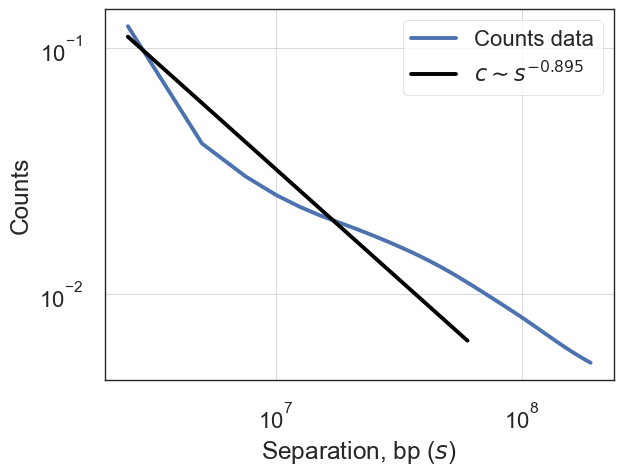

In [22]:
# # ====== Run this cell for comparison with 'contacts_vs_distances.ipynb'
# display(clr_matrix_df.groupby(['chrom', 'genomic_dis'])[['i.idx', 'snm3c_orig', 'snm3c_norm']].count())

# counts_by_s_chrom = get_counts_by_genomic_dist_perchrom(clr_matrix_df[clr_matrix_df.weights.notnull()], min_n=min_n, counts_col='snm3c_norm')
# display(counts_by_s_chrom['snm3c_norm'].unstack().groupby(level=1).sum())
# display(counts_by_s_chrom['snm3c_norm'].unstack())

# # Normalized snm3c
counts_by_s = get_counts_by_genomic_dist(clr_matrix_df, min_n=min_n, counts_col='snm3c_norm')
counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), _ = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=1, verbose=False, as_counts=True)

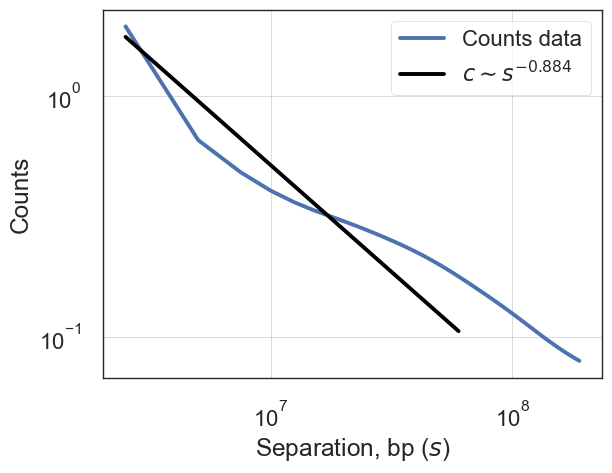

In [23]:
%run fit_dist_decay.py

counts_by_s = get_counts_by_genomic_dist(clr_matrix_df, min_n=min_n, counts_col='snm3c_orig')
counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), _ = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=1, verbose=False, as_counts=True)

## Distance decay: PSEUDOCOUNTS

In [2]:
%run fit_pseudocount_func.py load

matrix_df, sc_dis, lengths_df = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, normalize_snm3c=normalize, resolution=resolution, verbose=True)

Loading and normalizing snm3c-seq data...
0 genomic loci are present in MERFISH but not snm3c
17 genomic loci are masked out from snm3c


In [105]:
%run plot_pseudocount_func.py
%run fit_dist_decay.py
# plt.style.use('seaborn-v0_8-poster')

def get_pseudocounts_dist_decay(matrix_df, sc_dis, transfer_func, transfer_func_kwargs, seed=0, verbose=False):
    if transfer_func.__name__ == 'sum_logistic':
        title = transfer_func.__name__ 
    else:
        title = transfer_func.__name__ + '\n' + ', '.join([f"{k}={v:.4g}" for k, v in transfer_func_kwargs.items()])

    matrix_df_ambig, _ = get_pseudocounts(
        matrix_df, sc_dis=sc_dis, transfer_func=transfer_func, transfer_func_kwargs=transfer_func_kwargs,
        snm3c_are_normalized=normalize, remove_null_snm3c=False, verbose=verbose)
    # pearson_r, (_, matrix_df_ambig) = assess_pseudocounts(
    #     matrix_df, sc_dis=sc_dis, transfer_func=transfer_func, transfer_func_kwargs=transfer_func_kwargs,
    #     plot=False, remove_null_snm3c=False)

    counts_by_s = get_counts_by_genomic_dist(matrix_df_ambig, min_n=min_n)
    counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
    d, (x, y), _ = estimate_exponent_manual(
        counts_by_s_smooth, seed=seed, dis_exp=1, verbose=verbose, as_counts=True, title=title, bounds=(-1, 0))

    counts_by_s = get_counts_by_genomic_dist(matrix_df_ambig, min_n=min_n, counts_col='snm3c')
    counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
    d, (x, y), _ = estimate_exponent_manual(
        counts_by_s_smooth, seed=seed, dis_exp=1, verbose=verbose, as_counts=True,
        title=f"snm3C, rescaled via:\n{title}", bounds=(-1, 0))

    return matrix_df_ambig


get_pseudocounts_dist_decay_logistic = partial(get_pseudocounts_dist_decay, matrix_df=matrix_df, sc_dis=sc_dis, transfer_func=logistic)

In [ ]:
%run plot_pseudocount_func.py  # Imputed + norm, 2500kb - - NORM BIN1/RESCALING FIXED
%run fit_dist_decay.py # →→ exp=-0. (snm3c = -0.)

# k=-12.0392;  d0=0.494796;  nu=1             # obj=-0.8707179326 → pearson.buffer10, seed=0  (FACTR)             # →→ exp=-0.537 (snm3c = -0.886)
# _ = get_pseudocounts_dist_decay_logistic(transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-19.2999;  d0=0.443964;  nu=1             # obj=0.01246724052 → rmse.buffer10, seed=0  (PGTOL)                # →→ exp=-0.574 (snm3c = -0.886)
# _ = get_pseudocounts_dist_decay_logistic(transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-5.17941;  d0=2.70054;  nu=1.18687e-05    # obj=-0.8710339124 → pearson.infer_nu.buffer10, seed=3  (FACTR)    # →→ exp=-0.538 (snm3c = -0.886)
# _ = get_pseudocounts_dist_decay_logistic(transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-8.57474;  d0=1.79574;  nu=1.08414e-05    # obj=0.01244820574 → rmse.infer_nu.buffer8, seed=3  (FACTR)        # →→ exp=-0.575 (snm3c = -0.886)
# _ = get_pseudocounts_dist_decay_logistic(transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))


In [48]:
# %run plot_pseudocount_func.py  # Imputed + norm, 2500kb
# %run fit_dist_decay.py

# for agg in ('mean', 'median'):
#     if agg.lower() == 'mean':
#         sc_dis_agg = sc_dis.mean(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
#     else:
#         sc_dis_agg = sc_dis.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
#     print(f"\n====== {agg.upper()} ======")
#     _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis_agg, transfer_func=power, transfer_func_kwargs=dict(alpha=-4.54), seed=0)  # →→ exp=-1 (both)
#     _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis_agg, transfer_func=power, transfer_func_kwargs=dict(alpha=-4.95), seed=0)  # →→ exp=-1 (both)

In [7]:
# %run plot_pseudocount_func.py  # Imputed + norm, 2500kb
# %run fit_dist_decay.py
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=power, transfer_func_kwargs=dict(alpha=-1.3), seed=0)  # →→ exp=-0.229
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=power, transfer_func_kwargs=dict(alpha=-4.54), seed=0)  # →→ exp=-0.536 (wavy)

In [159]:
# %run plot_pseudocount_func.py  # Imputed + norm, 2500kb
# %run fit_dist_decay.py
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.6), seed=0)  # →→ exp=-0.556
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.4), seed=0)  # →→ exp=-0.615
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.3), seed=0)  # →→ exp=-0.645
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.2), seed=0)  # →→ exp=-0.668
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.1), seed=1)  # →→ exp=-0.687

In [261]:
%run plot_pseudocount_func.py  # Imputed + norm, 2500kb
%run fit_dist_decay.py

# k=-8.9299;  d0=2.50286;  nu=1e-8                                # obj=0.02028603138 → rmse.nu1e-8_buffer1e-4, seed=1   # →→ exp=-0.582
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-20;  d0=1;  nu=1e-05;  scaling=0.63811         #      →→ exp=-0.599
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-25;  d0=0.75;  nu=1e-05;  scaling=0.63811         #      →→ exp=-0.634
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-25;  d0=0.5;  nu=1e-05;  scaling=0.63811         #      →→ exp=-0.686
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-30;  d0=0.5;  nu=1e-05;  scaling=0.63811         #      →→ exp=-0.669
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-30;  d0=0.75;  nu=1e-08;  scaling=0.63811         #      →→ exp=-0.666
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-30;  d0=1;  nu=1e-08;  scaling=0.63811         #      →→ exp=-0.611
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-35;  d0=0.75;  nu=1e-08;  scaling=0.63811         #      →→ exp=-0.649
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-25;  d0=0.5;  nu=1e-04;  scaling=0.63811         #      →→ exp=-0.666
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-25;  d0=0.4;  nu=1e-04;  scaling=0.63811         #      →→ exp=-0.775 ****
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-25;  d0=0.4;  nu=1e-03;  scaling=0.63811         #      →→ exp=-0.667
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-25;  d0=0.3;  nu=1e-04;  scaling=0.63811         #      →→ exp=-X
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-25;  d0=0.3;  nu=1e-03;  scaling=0.63811         #      →→ exp=-0.774 ***
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-35;  d0=0.3;  nu=1e-04;  scaling=0.63811         #      →→ exp=-0.771 ***
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-35;  d0=0.3;  nu=1e-03;  scaling=0.63811         #      →→ exp=-0.671
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-25;  d0=0;  nu=1;  scaling=0.63811         #      →→ exp=-0.66
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-20;  d0=0;  nu=1;  scaling=0.63811         #      →→ exp=-0.651
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-30;  d0=0;  nu=1;  scaling=0.63811         #      →→ exp=-0.674
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-40;  d0=0;  nu=1;  scaling=0.63811         #      →→ exp=-0.766 **
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-40;  d0=0.1;  nu=1;  scaling=0.63811         #      →→ exp=-0.665
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-40;  d0=0;  nu=0.9;  scaling=0.63811         #      →→ exp=-0.768 **
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-50;  d0=0;  nu=1;  scaling=0.63811         #      →→ exp=-0.738
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu), seed=2)
# k=-40;  d0=-0.1;  nu=1;  scaling=0.63811         #      →→ exp=-0.738
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu), seed=2)
# k=-45;  d0=0;  nu=1;  scaling=0.63811         #      →→ exp=-0.769 ***
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-35;  d0=0;  nu=1;  scaling=0.63811         #      →→ exp=-0.687
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

<Figure size 1280x880 with 0 Axes>

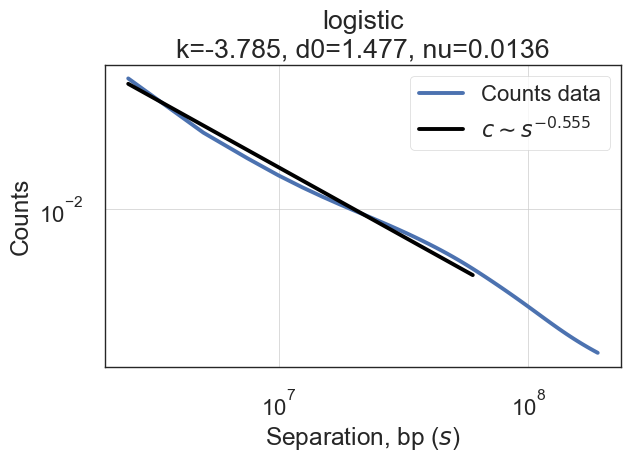

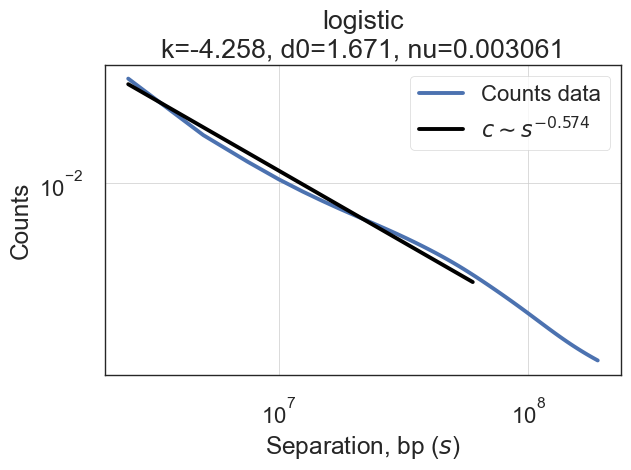

In [51]:
%run plot_pseudocount_func.py  # Imputed + norm, 500kb !!
%run fit_dist_decay.py


k=-3.78506;  d0=1.47742;  nu=0.0136047                       # obj=-0.8765355635 → pearson.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0     →→ exp=-0.555
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

k=-4.25834;  d0=1.67136;  nu=0.00306059                      # obj=0.001800289408 → rmse.infer_nu.buffer4_k-lt0_d0-gte0-lte9999p_nu-lte2, seed=0       →→ exp=-0.574
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))


In [263]:
%run plot_pseudocount_func.py  # Imputed + norm, 2500kb
%run fit_dist_decay.py

# k=-5.63538;  d0=2.45539;  nu=1.51704e-05;  scaling=0.460945  # obj=-0.8249887143 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)     →→ exp=-0.55
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-3.28051;  d0=0.0803431;  nu=1;  scaling=0.423193          # obj=-0.7655715825 → pearson.weight-2.infer_nu.buffer1e-4, seed=0  (PGTOL)          →→ exp=-0.406
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-4;  d0=0.924222;  nu=0.240699;  scaling=0.254873          # obj=-0.7633982813 → pearson.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR)     →→ exp=-0.48
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# k=-14.7916;  d0=1.20409;  nu=1e-05;  scaling=0.63811         # obj=0.06883501762 → rmse.weight-2.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (ABNORMAL)     →→ exp=-0.596
# _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

<Figure size 1280x880 with 0 Axes>

<Figure size 1280x880 with 0 Axes>

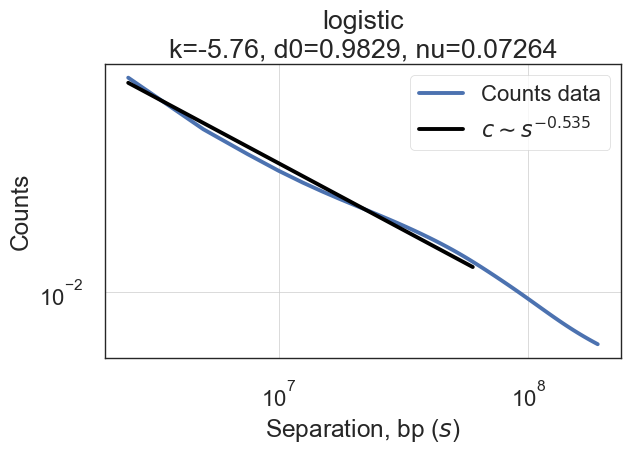

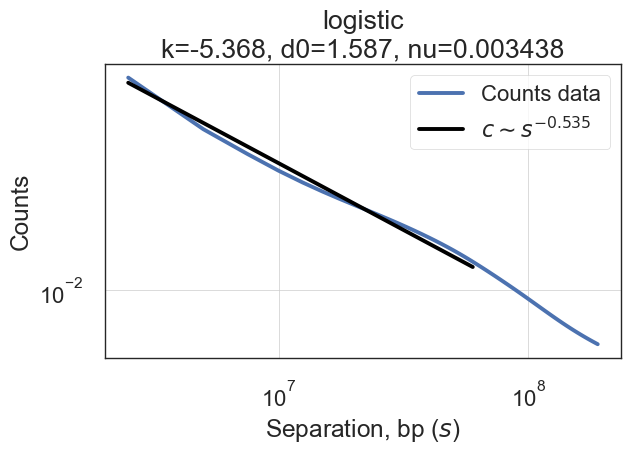

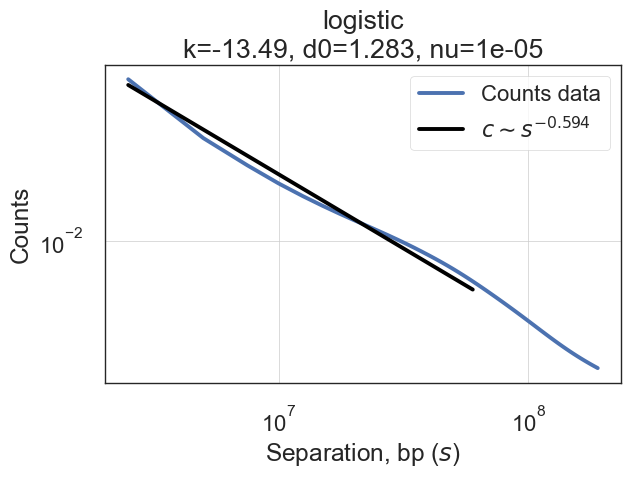

In [129]:
%run plot_pseudocount_func.py  # Imputed + norm, 2500kb
%run fit_dist_decay.py

# ====== pearson, weight-1, infer_nu, kmax-4_buffer1e-5_d0min50p
k=-5.75977;  d0=0.982889;  nu=0.0726394;  scaling=0.365714   # obj=-0.8376003456 → pearson.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) ~~~ →→ exp=-0.535
matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
k=-5.3679;  d0=1.58719;  nu=0.0034379;  scaling=0.373551     # obj=-0.8375998509 → pearson.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)     →→ exp=-0.535
matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# ====== rmse, infer_nu, kmax-4_buffer1e-5_d0min50p
# k=-9.65154;  d0=1.64148;  nu=1e-05;  scaling=0.573489        # obj=0.02028542196 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)              →→ exp=-0.582
# matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

# ====== rmse, weight-1, infer_nu, kmax-4_buffer1e-5_d0min50p
k=-13.4861;  d0=1.2826;  nu=1e-05;  scaling=0.630876         # obj=0.04694099398 → rmse.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) ~~~   →→ exp=-0.594
matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))
# k=-6.59108;  d0=2.1071;  nu=1e-05;  scaling=0.950385         # obj=0.04702889397 → rmse.weight-1.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=1  (FACTR)     →→ exp=-0.592
# matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

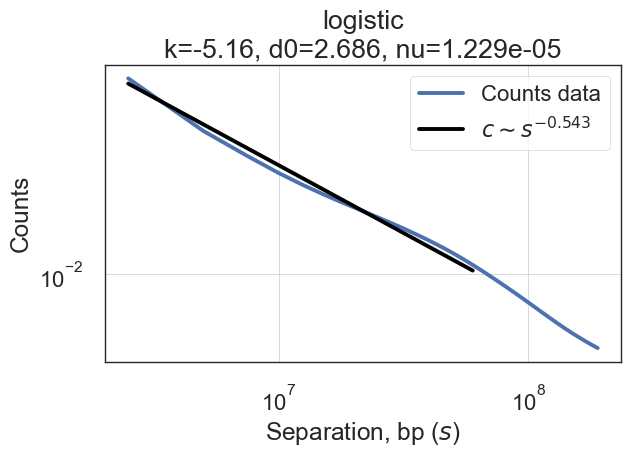

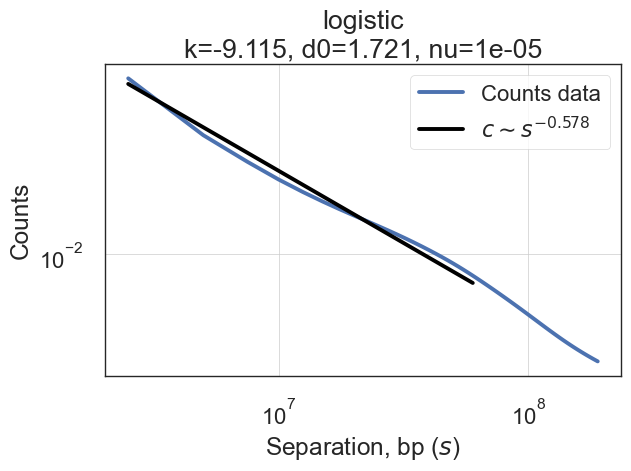

In [278]:
%run plot_pseudocount_func.py  # Imputed, NO norm
%run fit_dist_decay.py

k=-5.15964;  d0=2.68554;  nu=1.22861e-05;  scaling=5.36133   # obj=-0.88644655 → pearson.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) (imputed, NO norm)
matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

k=-9.11523;  d0=1.72088;  nu=1e-05;  scaling=6.65738         # obj=0.18979348 → rmse.infer_nu.kmax-4_buffer1e-5_d0min50p, seed=0  (FACTR) (imputed, NO norm)
matrix_df_ambig, _ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

INFO:2025-07-31 12:08:19,042:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


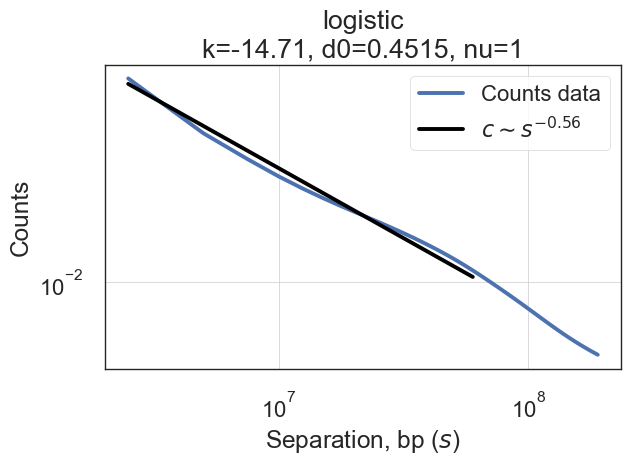

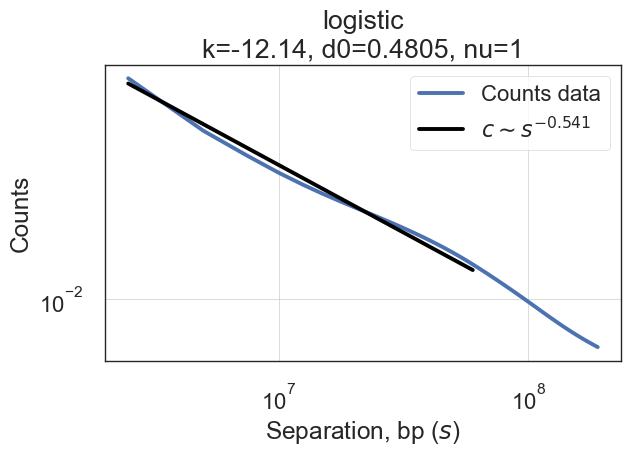

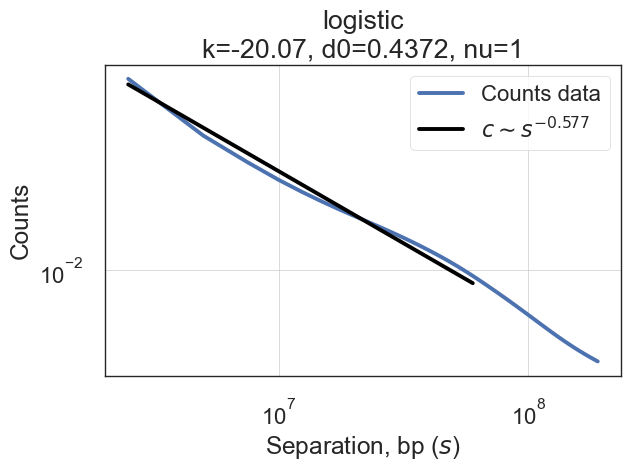

In [6]:
k, d0 = np.array([-14.71402465, 0.45154928]); nu = 1         # best from INITIAL inference: pearson.weight0, seed=0 - NON-IMPUTED DATA (with norm)
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

k=-12.1386;  d0=0.480525;  nu=1;  scaling=4.2463             # obj=-0.88616295 → pearson, seed=0 (FACTR) - imputed data (NO norm)
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

k=-20.0702;  d0=0.437226;  nu=1;  scaling=5.78779            # obj=0.190089 → rmse, seed=0 (PGTOL) - imputed data (NO norm)
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

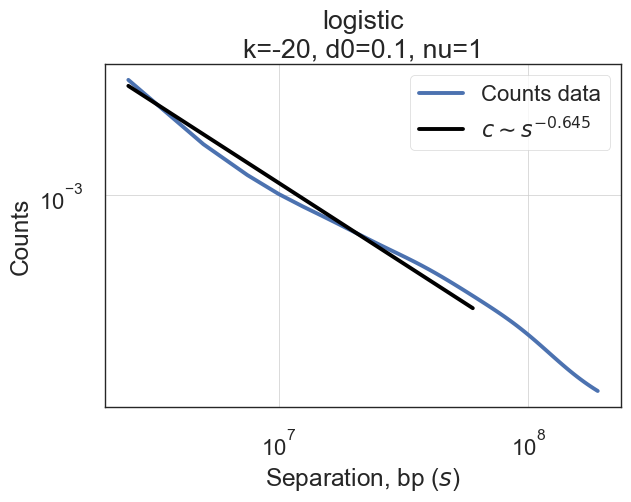

In [162]:
k=-20;  d0=0.1;  nu=1
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

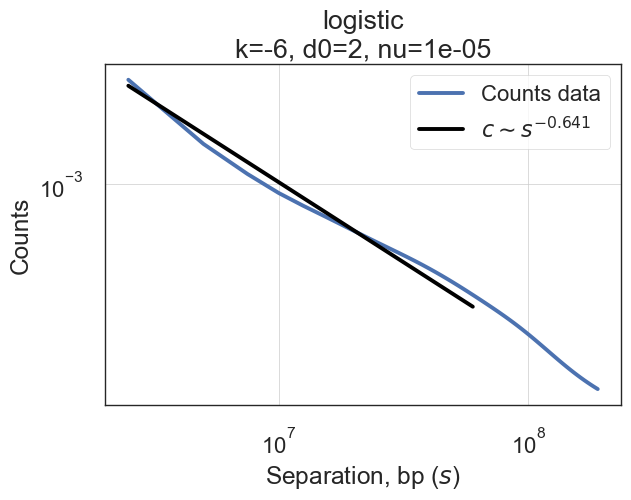

In [115]:
k=-6;  d0=2;  nu=1e-05
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

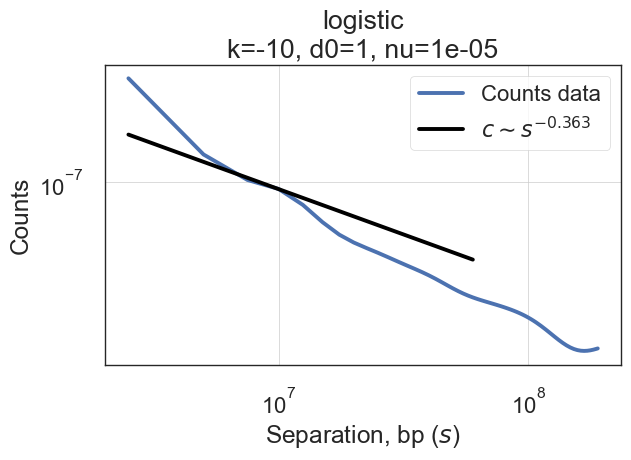

In [164]:
k=-10;  d0=1;  nu=1e-05
_ = get_pseudocounts_dist_decay(matrix_df, sc_dis=sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, d0=d0, nu=nu))

### Distance decay: *filtered* snm3c counts (only loci present in MERFISH data)

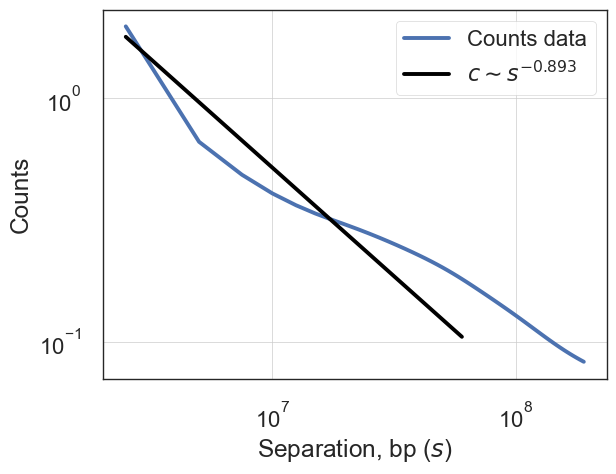

In [261]:
%run fit_dist_decay.py

counts_by_s = get_counts_by_genomic_dist(matrix_df_ambig, min_n=min_n, counts_col='snm3c')
counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), _ = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=1, verbose=False, as_counts=True)

# Distance decay - 3D distances

## Load

In [16]:
%run fit_dist_decay.py

In [11]:
%run fit_dist_decay.py

import pandas as pd
import glob
import os
import ast
import numpy as np
from cooltools.sandbox.expected_smoothing import log_smooth

import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import seaborn as sns


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'


sc_dis_intramol_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.intramol.tsv.gz'))
if len(sc_dis_intramol_file) != 1:
    raise ValueError("Couldn't find unique file for intra-mol single cell distances")
sc_dis_intramol_file = sc_dis_intramol_file[0]

sc_dis_intramol = pd.read_csv(
    sc_dis_intramol_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})

## Pseudo-counts

### Hist

In [44]:
tmp = sc_dis_intramol.values.ravel()
tmp = tmp[~np.isnan(tmp)]
print((pd.Series(tmp.round().astype(int)).value_counts() / tmp.size * 100).to_string(float_format=lambda x: f"{x:.2g}%"))

1        42%
2        36%
3        13%
0       3.8%
4       3.6%
5      0.92%
6      0.24%
7     0.056%
8     0.013%
9    0.0029%
10   0.0013%
11   0.0005%


In [77]:
print(pd.Series(tmp[tmp < np.quantile(tmp, 1)]).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\n" + pd.Series(tmp[tmp >= 0.01]).describe().to_string(float_format=lambda x: f"{x:.2g}"))

count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

count   9.4e+06
mean        1.8
std        0.93
min        0.01
25%         1.1
50%         1.6
75%         2.2
max          11


In [ ]:
tmp[tmp < np.quantile(tmp, 0.0001)]

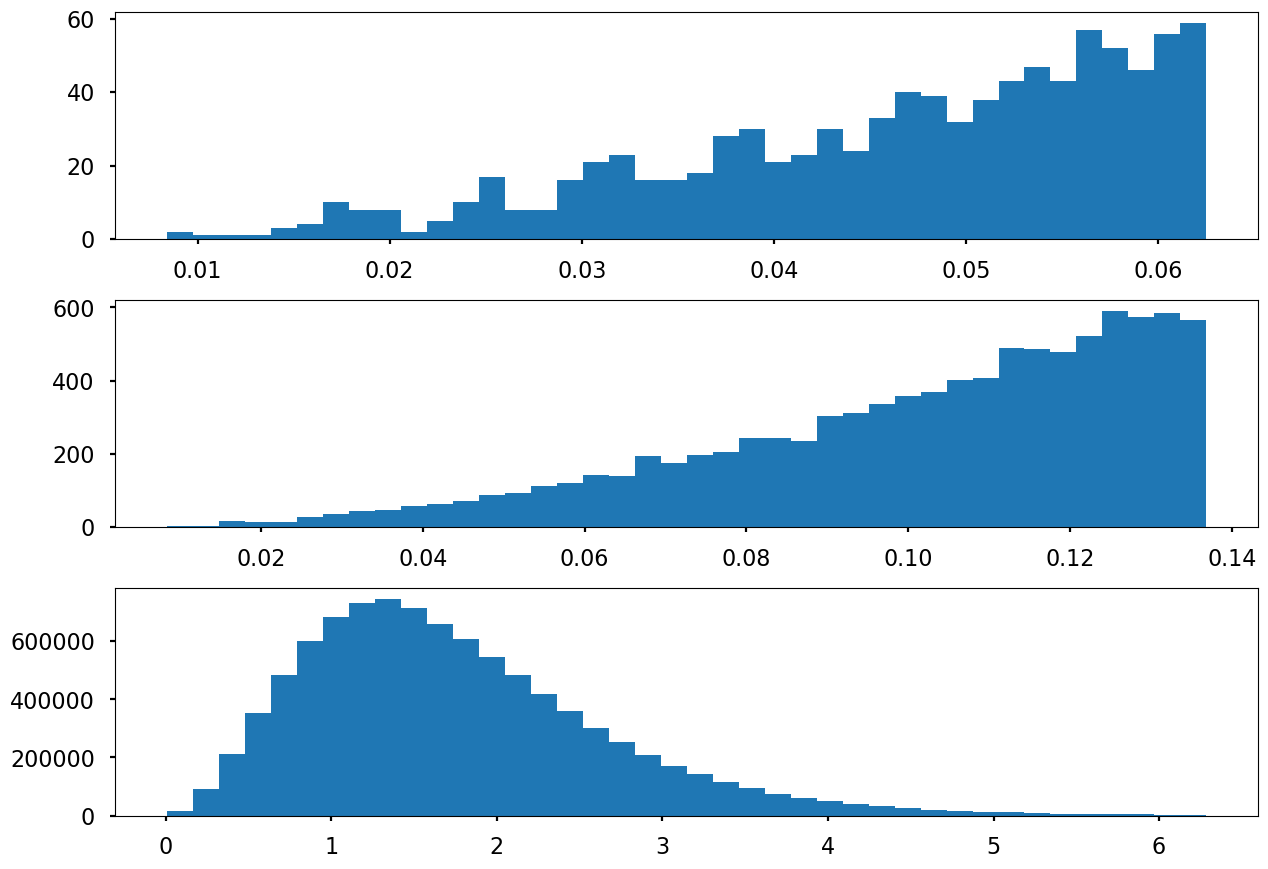

In [73]:
fig, ax = plt.subplots(3, 1, sharey=False, tight_layout=True)

ax[0].hist(tmp[tmp < np.quantile(tmp, 0.0001)], bins=40)
ax[1].hist(tmp[tmp < np.quantile(tmp, 0.001)], bins=40)
ax[2].hist(tmp[tmp < np.quantile(tmp, 0.999)], bins=40)

plt.show()

In [11]:
# PASTIS transfer function ONLY

alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell distances:\n" + pd.Series(sc_dis_intramol.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nSingle-cell counts:\n" + sc_counts_series.describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

Single-cell distances:
count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min       6e-05
25%       0.039
50%        0.16
75%        0.72
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min       0.058
25%         1.7
50%         4.3
75%          13
max       7e+05


In [ ]:
# sns.histplot(data=pd.Series(counts.values.ravel()).to_frame(), x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
# sns.histplot(data=counts, x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
sns.histplot(data=counts.values)
plt.x_axis(r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
plt.show()

In [9]:
# PASTIS transfer function + 0.75um cutoff
alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol > 0.75)] = 0
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min           0
25%           0
50%           0
75%           0
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min           0
25%         1.4
50%           4
75%          13
max       7e+05


In [12]:
# 0.75um cutoff only

sc_counts = pd.DataFrame(0, index=sc_dis_intramol.index, columns=sc_dis_intramol.columns)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol <= 0.75)] = 1
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   1.7e+08
mean     0.0061
std       0.078
min           0
25%           0
50%           0
75%           0
max           1

Consensus counts:
count   4.5e+04
mean     0.0061
std       0.005
min           0
25%      0.0027
50%      0.0049
75%      0.0078
max       0.052


(np.int64(0), np.int64(103))

### Dist decay - pseudo-counts

In [ ]:
# XXX shouldn't the distance decay be for ambiguated counts? not that it'll make a huge difference...

#### c ~ d^alpha

v = 0.785
1/v = 1.27
est alpha = B/v = -1.02


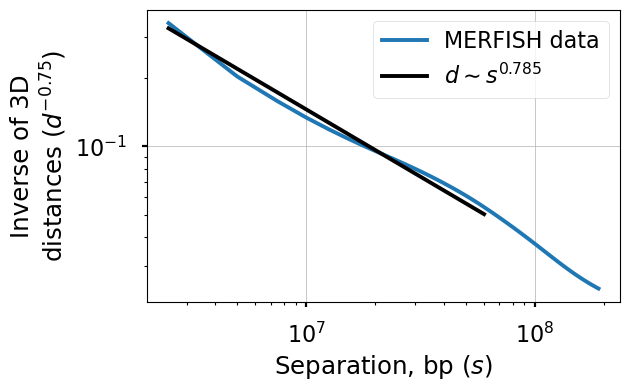

In [151]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = 0.1; max_distance = 0.75 # 0.162
# dis_exp = -4; min_distance = 0.1; max_distance = 1 # 0.161
# dis_exp = -4; min_distance = 0.1; max_distance = 0.5 # 0.164
# dis_exp = -4; min_distance = 0.01; max_distance = 0.5 # 0.151, noisy
# dis_exp = -4; min_distance = 0.05; max_distance = 0.5 # 0.167
# dis_exp = -4; min_distance = 0.025; max_distance = 0.5 # 0.177
# dis_exp = -3; min_distance = 0.025; max_distance = 0.5 # 0.223
# dis_exp = -3; min_distance = 0.025; max_distance = 0.2 # 0.231
# dis_exp = -2; min_distance = 0.025; max_distance = 0.5 # 0.312
# dis_exp = -2; min_distance = 0.025; max_distance = 0.2 # 0.339 ++
# dis_exp = -2; min_distance = 0.025; max_distance = 0.1 # 0.346, noisier than max_dist=0.2
# dis_exp = -2; min_distance = 0.015; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.05; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.02; max_distance = 0.2 # 0.337

# dis_exp = -1; min_distance = 0.025; max_distance = 0.5 # 0.593
# dis_exp = -1; min_distance = 0.025; max_distance = 0.2 # 0.666 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = None # 0.201 ++
dis_exp = -0.75; min_distance = None; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = None; max_distance = 0.5 # 0.785 ++
# dis_exp = -0.5; min_distance = 0.025; max_distance = 0.5 # 1.17
# dis_exp = -0.2; min_distance = 0.025; max_distance = 0.5 # 2.89
# dis_exp = -1; min_distance = None; max_distance = None  # 0.204 ++
# dis_exp = -0.2; min_distance = None; max_distance = None  # 0.196 ++
# dis_exp = -0.75; min_distance = None; max_distance = None  # 0.201 ++
# dis_exp = -1.5; min_distance = None; max_distance = None  # 0.209 ++
# dis_exp = -2; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -2.5; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -3; min_distance = None; max_distance = None  # 0.201 ++


counts_sc = sc_dis_intramol.pow(dis_exp)
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_dist3d_by_genomic_dist(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = std logistic of x=-ln(d)

v = 0.661
1/v = 1.51
est alpha = B/v = -1.21


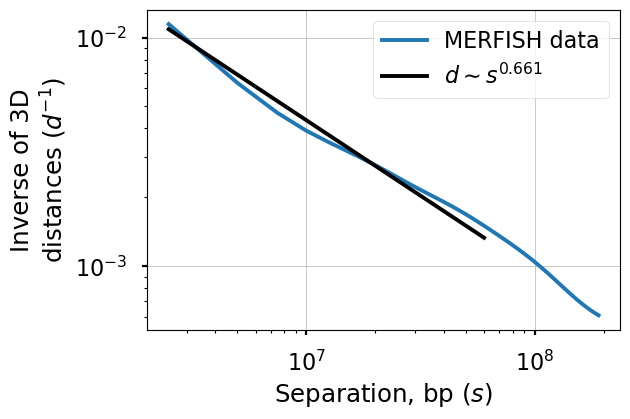

In [65]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = None; max_distance = None # 0.0853
# dis_exp = -4; min_distance = 0.01; max_distance = 0.75 # noise
# dis_exp = -3; min_distance = None; max_distance = None # 0.0913
# dis_exp = -2; min_distance = None; max_distance = None # 0.0974
# dis_exp = -1; min_distance = None; max_distance = None # 0.103
# dis_exp = -0.5; min_distance = None; max_distance = None # 0.106
# dis_exp = -0.25; min_distance = None; max_distance = None # 0.107

# dis_exp = -4; min_distance = None; max_distance = 0.75 # 0.131
# dis_exp = -4; min_distance = None; max_distance = 0.5 # 0.148
# dis_exp = -4; min_distance = None; max_distance = 0.2 # 0.166
# dis_exp = -3; min_distance = None; max_distance = 0.2 # 0.221
# dis_exp = -1; min_distance = None; max_distance = 0.75 # 0.494
# dis_exp = -1; min_distance = None; max_distance = 0.5 # 0.579
dis_exp = -1; min_distance = None; max_distance = 0.2 # 0.661

counts_sc = (1 + sc_dis_intramol).pow(dis_exp)  # power law where x=d+1 OR logistic fxn of x where x = -ln(d)
# alternative (1 + e^(10*(d-0.5)))^-1) = based on logistic fxn of x where x = -d (equiv to "1 - [logistic fxn of d]")
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_dist3d_by_genomic_dist(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = logistic of x=

v = 0.681
1/v = 1.47
est alpha = B/v = -1.18


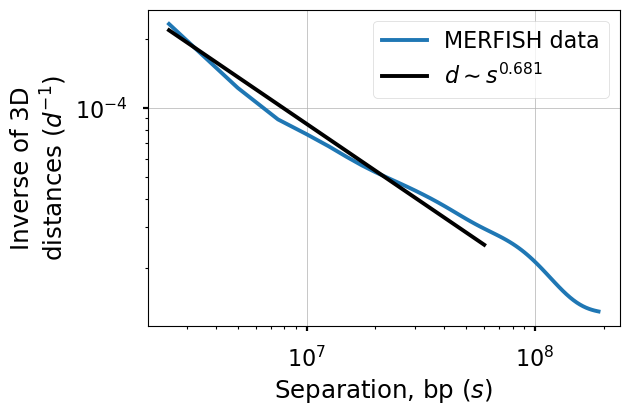

In [140]:
sigma_log10 = 0.1; min_n = None
L = 1
# k = -3;   d0=-0.5  # 0.412
# k = -10;   d0=-0.2  # 0.61
# k = -10;   d0=-0.1  # 0.608
# k = -15;   d0=-0.1  # 0.643
# k = -15;   d0=0     # 0.641
# k = -20;   d0=0     # 0.659
# k = -30;   d0=0     # 0.659
# k = -35;   d0=0     # 0.68
# k = -37;   d0=0     # 0.69
# k = -38;   d0=0     # 0.683
k = -39;   d0=+0.01     # 0.681
# k = -10;   d0=-0.5  # ??



def logistic(x, d0, k, L=1, nu=1):
    # d0 <= 0 and k<0
    tmp = -k * (x - d0)
    # try1 = L / np.power(1 + np.exp(-k * (x - d0)), 1 / nu)
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp))) / nu
    return try2



counts_sc = logistic(sc_dis_intramol, d0=d0, k=k, L=L)
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_dist3d_by_genomic_dist(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

In [10]:
def logistic_fun(x, d0, k, L=1):
    # d0 <= 0 and k<0
    tmp = -k * (x - d0)
    # try1 = L / (1 + np.exp(-k * (x - d0)))
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp)))
    return try2

counts_sc = logistic_fun(sc_dis_intramol, d0=0, k=-10, L=1)

counts_sc.index = [j - i for i, j in counts_sc.index]

counts_sc = None

In [ ]:
counts_sc.groupby(level=0).var().mean(axis=1)

In [135]:
x = 10

correct = L / (1 + np.exp(x))
testing = np.exp(np.log(L) - np.log1p(np.exp(x)))
print(f"{correct=:.10}\n{testing=:.10g}")


# correct = 1 + np.exp(x)
# testing = np.exp(np.log1p(np.exp(x)))
# print(f"{correct=:.10}\n{testing=:.10g}")

correct=4.53978687e-05
testing=4.53978687e-05


## Analyze

In [35]:
%run fit_dist_decay.py

min_n = None
# dis_exp = -1; sigma_log10 = 0.01  # 1/exp = 4.9;   1/exp * dis_exp = 4.9;
# dis_exp = -3; sigma_log10 = 0.2   # 1/exp = ~2;    1/exp * dis_exp = 6;
# dis_exp = -0.5; sigma_log10 = 0.1   # 1/exp = 10;  1/exp * dis_exp = 5;
# dis_exp = -5; sigma_log10 = 0.1   # 1/exp =  2;    1/exp * dis_exp =  10;
# dis_exp = 1; sigma_log10 = 0.1  # 1/exp = 5.38;                        
# dis_exp = -1; sigma_log10 = 0.1  # 1/exp = 4.9;   1/exp * dis_exp = 4.9
# dis_exp = -1; sigma_log10 = 0.1; min_n = 5; # similar to without min_n

# dis_exp = 1; sigma_log10 = 0.1
dis_exp = -1; sigma_log10 = 0.1

s_by_cell = get_dist3d_by_genomic_dist(sc_dis_intramol, dis_exp=dis_exp, min_n=min_n)
s_by_cell_smooth = s_smooth = smooth_frequency(s_by_cell, sigma_log10=sigma_log10)
display(s_by_cell_smooth.head(3))
display(s_by_cell_smooth.tail(3))
# s_by_cell_smooth.n[s_by_cell_smooth.n != 0].describe()

,data,n,smoothed_data,smoothed_n,smoothed_freq,cell_num
genomic_dis,,,,,,
1,50.129543,23,49.869668,23.010678,2.167240,1
2,25.753989,24,28.076187,24.154141,1.162376,1
3,37.610282,25,34.745875,24.239789,1.433423,1


,data,n,smoothed_data,smoothed_n,smoothed_freq,cell_num
genomic_dis,,,,,,
74,0.0,0,NaN,NaN,NaN,3702
75,0.0,0,NaN,NaN,NaN,3702
76,0.0,0,NaN,NaN,NaN,3702




======= MEAN =======

v = 0.245
est alpha = B/v = -3.76 (assuming counts exponent = -0.921)


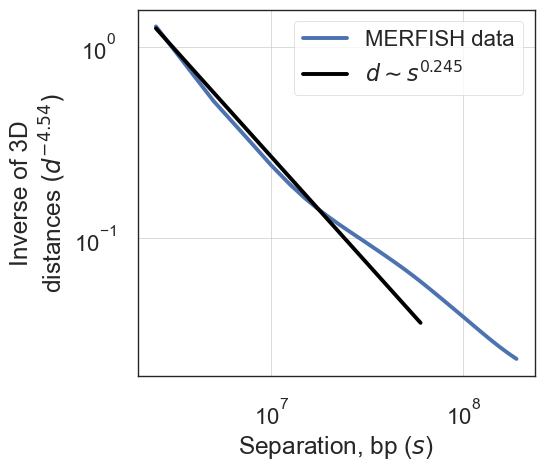



======= MEDIAN =======

v = 0.229
est alpha = B/v = -4.02 (assuming counts exponent = -0.921)


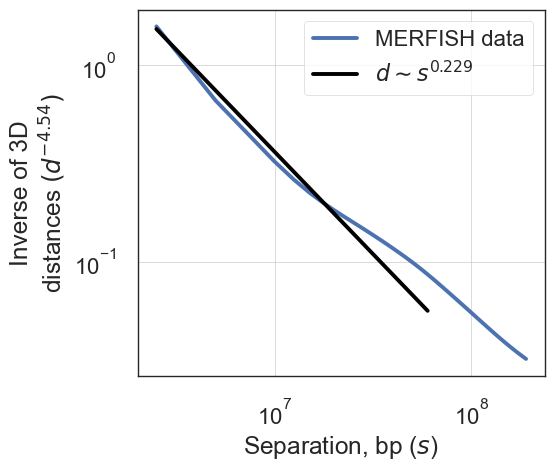

In [50]:
%run fit_dist_decay.py

# min_n = None
# dis_exp = -1; sigma_log10 = 0.1; alpha = 1
# dis_exp = 1; sigma_log10 = 0.1; alpha = 1


dis_exp = -1; sigma_log10 = 0.1; alpha = -4.54
dis_exp = 1; sigma_log10 = 0.1; alpha = -4.95

# dis_exp = 1; sigma_log10 = 0.1; alpha = -4.54
# dis_exp = -1; sigma_log10 = 0.1; alpha = -4.95


dis_exp = -4.54; sigma_log10 = 0.1; alpha = 1


for agg in ('mean', 'median'):
    print(f"\n\n======= {agg.upper()} =======\n")
    if agg.lower() == 'mean':
        sc_dis_intramol_agg = sc_dis_intramol.mean(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
    else:
        sc_dis_intramol_agg = sc_dis_intramol.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
    s_agg = get_dist3d_by_genomic_dist(sc_dis_intramol_agg, dis_exp=dis_exp, min_n=min_n) #** (alpha * (dis_exp / np.abs(dis_exp)))
    s_agg_smooth = smooth_frequency(s_agg, sigma_log10=sigma_log10)
    d, (x, y), est_alpha = estimate_exponent_manual(s_agg_smooth, seed=0, dis_exp=dis_exp, verbose=True)

### Get exponent per cell

In [336]:
def get_exponent_per_cell(df, dis_exp):
    genomic_dis = df.index.values
    freq_smooth = df.smoothed_freq.values.ravel()
    
    d = estimate_exponent(genomic_dis, freq_smooth=freq_smooth, verbose=False)
    # d = estimate_exponent(
    #     genomic_dis, freq_smooth=freq_smooth, d0=d0, bounds=bounds, seed=seed,
    #     max_iter=max_iter, verbose=False)

    v = d['exponent'] / dis_exp
    detected_genomic_dis = s = df[df.n > 0].index.values
    res = {
        'v': v, 'n_sum': df.n.sum(), 'detected_sum': df.n.notnull().sum(),
        's_size': int(s.size), 's_mean': s.mean(), 's_median': np.median(s),
        's_range': int(s.max() - s.min() + 1)}
    return pd.Series(res)


min_genomic_dis = None; max_genomic_dis = 'default'

if min_genomic_dis is None:
    min_genomic_dis = s_by_cell_smooth.index.min()
if max_genomic_dis is None:
    max_genomic_dis = s_by_cell_smooth.index.max()
elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
    max_genomic_dis = 6e7
mask = (s_by_cell_smooth.index <= max_genomic_dis) & (s_by_cell_smooth.index >= min_genomic_dis)

# tmp = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
# n_sum = s_by_cell_smooth[mask].groupby('cell_num').n.sum().to_frame().rename({'n': 'n_sum'}, axis=1)
# per_cell = pd.concat([n_sum, tmp.to_frame().rename({0: 'v'}, axis=1)], axis=1)

per_cell = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
for col in [col in per_cell.columns if col != 'v']:  #['n_sum', 's_size', 's_mean', 's_median', 's_range']:
    per_cell[col] = per_cell[col].astype(int)

In [372]:
min_nsum = int(round(per_cell.n_sum.quantile(0.5)))

display(per_cell.describe().round(2))
print('\ns < -0.25')
display(per_cell[per_cell.v < -0.25].describe().round(2))
print(f'\nn_sum > {min_nsum}')
display(per_cell[per_cell.n_sum >= min_nsum].describe().round(2))

pairs_per_cell = s_by_cell_smooth[mask].groupby('cell_num').n.sum()
cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
num_pairs_orig = sc_dis_intramol.notnull().values.sum()
num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs")

,v,n_sum,s_size,s_mean,s_median,s_range
count,3702.00,3702.00,3702.00,3702.00,3702.00,3702.00
mean,0.15,2536.00,59.65,30.07,30.07,60.44
std,0.34,2584.42,12.52,6.25,6.25,12.44
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,0.15,630.00,50.00,25.00,25.00,50.00
50%,0.19,1550.00,60.00,30.00,30.00,61.00
75%,0.23,3629.00,71.00,36.00,36.00,71.00
max,0.66,14663.00,76.00,38.00,38.00,76.00



s < -0.25


,v,n_sum,s_size,s_mean,s_median,s_range
count,53.00,53.00,53.00,53.00,53.00,53.00
mean,-2.44,106.66,23.25,12.08,12.19,24.25
std,0.77,108.89,7.71,3.83,3.85,7.69
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,-2.74,55.00,20.00,10.00,10.00,21.00
50%,-2.74,78.00,21.00,11.00,11.00,22.00
75%,-2.74,105.00,23.00,12.00,12.00,23.00
max,-0.26,631.00,55.00,28.00,28.00,57.00



n_sum > 1550


,v,n_sum,s_size,s_mean,s_median,s_range
count,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00
mean,0.20,4375.34,67.95,34.22,34.22,68.58
std,0.05,2533.50,7.05,3.52,3.52,7.09
min,-0.08,1550.00,47.00,24.00,24.00,47.00
25%,0.17,2355.00,61.00,31.00,31.00,61.00
50%,0.20,3629.00,70.00,35.00,35.00,71.00
75%,0.23,5704.25,75.00,38.00,38.00,75.00
max,0.40,14663.00,76.00,38.00,38.00,76.00


Retaining 86% of pairs


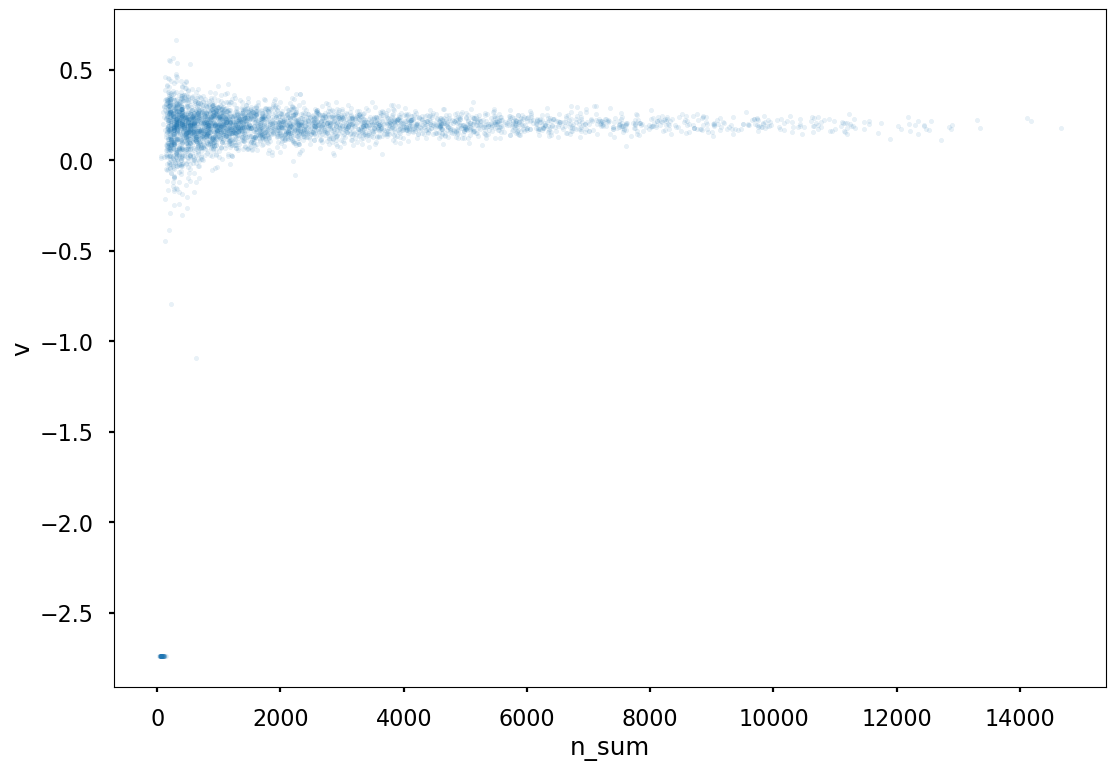

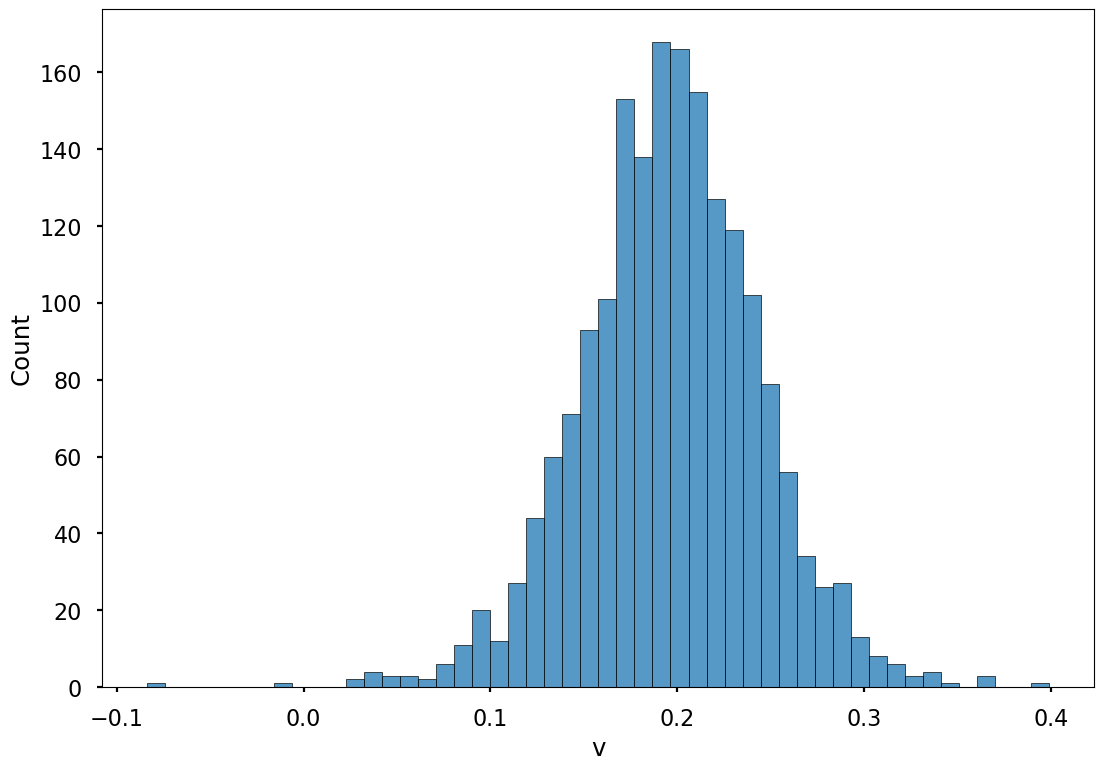

In [367]:
sns.scatterplot(data=per_cell, x="n_sum", y="v", s=10, alpha=0.1, edgecolors=None)  # 
plt.show()

sns.histplot(data=per_cell[per_cell.n_sum > per_cell.n_sum.quantile(0.5)], x="v")
plt.show()

## Plot

v = 0.203
est alpha = B/v = -4.54 (assuming counts exponent = -0.921)


<Figure size 1280x880 with 0 Axes>

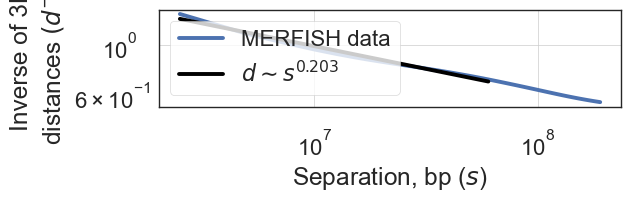

v = 0.203
est alpha = B/v = -4.54 (assuming counts exponent = -0.921)


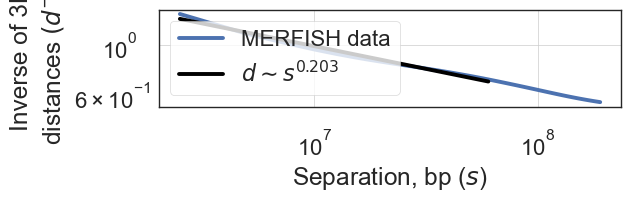

In [36]:
%run fit_dist_decay.py

min_nsum = 0


data_smooth = s_by_cell_smooth
data_orig = s_by_cell
if min_nsum > 1:
    pairs_per_cell = data_smooth[data_smooth.n >= min_nsum].groupby('cell_num').n.sum()
    cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
    num_pairs_orig = sc_dis_intramol.notnull().values.sum()
    num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
    print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs\n\n")
    data_smooth = data_smooth[data_smooth.cell_num.isin(cells_to_use)]
    data_orig = data_orig[cells_to_use]
# data_smooth = data_smooth.copy(); data_smooth[data_smooth.n < 40] = np.nan

# s_smooth_mean = data_smooth.groupby(level=0).mean().drop('cell_num', axis=1)
# # display(s_smooth_mean.head(2)); display(s_smooth_mean.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_mean, seed=0, dis_exp=dis_exp, verbose=True)

# s_smooth_med = data_smooth.groupby(level=0).median().drop('cell_num', axis=1)
# # display(s_smooth_med.head(2)); display(s_smooth_med.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_med, seed=0, dis_exp=dis_exp, verbose=True)

s_by_cell_mean = data_orig.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
s_mean_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_mean_smooth.head(2)); display(s_mean_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_mean_smooth, seed=0, dis_exp=dis_exp, verbose=True)


s_by_cell_med = data_orig.median(axis=1).to_frame().rename({0: 'sc_median'}, axis=1)
s_med_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_med_smooth.head(2)); display(s_med_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_med_smooth, seed=0, dis_exp=dis_exp, verbose=True)

## Fxn

In [2]:
n = 11
x_true = np.triu(np.ones((n, n)), 1).sum()
x = (n ** 2 - n) / 2
n_result = int((1 + np.sqrt(1 + 8 * x)) / 2)
print(x_true, x)
print(n, n_result)

55.0 55.0
11 11
